# Lección 11.3 · Expresión diferencial y FDR

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-11-rnaseq/11.3_expresion_diferencial_fdr.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 11 — Transcriptómica (RNA-seq)** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Intermedio–avanzado | Lecciones 11.1 (cuantificación) y 11.2 (normalización y binomial negativa); valores $p$ y regresión |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Formular** la pregunta «¿cambia la expresión de este gen?» como una hipótesis sobre un coeficiente del modelo lineal
   generalizado (GLM) binomial negativo, y **contrastarla** con la prueba de Wald y con la de razón de verosimilitudes (LRT).
2. **Explicar** por qué el *log fold change* (LFC) de máxima verosimilitud es engañoso en genes con pocas lecturas y
   **calcular** su versión contraída con una previa normal; **reconocer** cuándo conviene una previa de colas pesadas.
3. **Distinguir** la tasa de error por familia (FWER, Bonferroni) de la tasa de falsos descubrimientos (FDR) y
   **aplicar** a mano y en código el procedimiento de Benjamini-Hochberg.
4. **Diagnosticar** un análisis con el histograma de valores $p$, **estimar** $\pi_0$ y los $q$-valores de Storey, y
   **justificar** el filtrado independiente por media.
5. **Construir** e **interpretar** gráficos MA y *volcano*, estáticos e interactivos.
6. **Ejecutar** de principio a fin, desde cero y con `pydeseq2`, un análisis real: células de músculo liso de la vía
   aérea humana tratadas con dexametasona (experimento *airway*, Himes *et al.*, 2014), con un diseño pareado
   `~ cell + dex`, y **validarlo** con dianas conocidas de los glucocorticoides.

## 🗺️ Mapa de la clase

1. Diez mil detectores de metales: la intuición de la FDR
2. El experimento simulado del libro y el GLM binomial negativo
3. Contrastes sobre el modelo: Wald y razón de verosimilitudes
4. Tamaños de efecto: la contracción del LFC (ejemplo «Un gen ruidoso», 🎬 animación)
5. Gráficos MA y *volcano*
6. Diez mil pruebas a la vez: FWER, FDR y Benjamini-Hochberg (ejemplo «Tres criterios sobre el mismo experimento»)
7. El histograma de valores $p$ y los $q$-valores
8. Filtrado independiente (🎬 animación)
9. 🧪 Caso real: la dexametasona en el músculo liso de la vía aérea (🔍 MA y *volcano* interactivos, `pydeseq2`)
10. Tres errores clásicos, demostrados con los datos reales
11. Ejercicios, resumen y lecturas

> 📖 **Compañero del libro.** Esta lección acompaña la sección «Expresión diferencial y FDR» del capítulo 11 del libro
> *Bioinformática Práctica*. Usamos sus símbolos ($K_{ij}$, $\mu_{ij}$, $s_j$, $\alpha_i$, $\beta_{i,\mathrm{cond}}$,
> $\widehat{\mathrm{SE}}$, $\sigma_p$, $p_{(i)}$, $k^\ast$, $\pi_0$, $\lambda$), su función `bh` y reproducimos, cifra por
> cifra y con la misma semilla, su experimento simulado (9 992 genes, 3 frente a 3 réplicas) con los ejemplos «Un gen
> ruidoso» y «Tres criterios sobre el mismo experimento». El notebook se puede seguir sin el libro.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, gzip, json, math, time, warnings
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats, special, optimize

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_file(name):
    """Ruta de un archivo del curso: 1) copia local en ../data; 2) descarga desde el repositorio de GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(os.path.basename(name)):
        urllib.request.urlretrieve(f"{RAW}/data/{name}", os.path.basename(name))
    return os.path.basename(name)

# ---- Recuadro «benjamini_hochberg.py» del libro, sin cambios ----
def bh(p):
    """Valores p ajustados de Benjamini-Hochberg."""
    p = np.asarray(p, float); m = len(p)
    orden = np.argsort(p)
    ajust = p[orden] * m / np.arange(1, m + 1)
    ajust = np.minimum.accumulate(ajust[::-1])[::-1]  # monotonía
    salida = np.empty(m); salida[orden] = np.minimum(ajust, 1)
    return salida

def nb_ll(y, m, a):
    """Log-verosimilitud binomial negativa con media m y dispersión a (Var = m + a m²)."""
    r = 1.0 / a
    return (special.gammaln(y + r) - special.gammaln(r) - special.gammaln(y + 1)
            + r * np.log(r / (r + m)) + y * np.log(m / (r + m)))

def fmt(x, d=2):
    """Número con coma decimal, como en el libro."""
    return f"{x:.{d}f}".replace(".", ",")

T0 = time.time()
print("Listo para la Lección 11.3 · numpy", np.__version__)

Entorno listo ✔  |  Colab: False


Listo para la Lección 11.3 · numpy 2.5.3


## 1. Diez mil detectores de metales

Imagine una playa dividida en **10 000 cuadrículas**. En cada una se pasa un detector de metales que, cuando **no** hay
nada enterrado, pita por error **una vez de cada veinte** (una tasa de falsas alarmas del 5 %). Bajo la arena hay
**500 monedas**, y el detector es bueno: pita sobre 9 de cada 10 de ellas.

¿Qué pasa si excavamos todas las cuadrículas que pitaron? Hagamos la cuenta a mano:

| | Cuadrículas | Pitan | No pitan |
|---|---:|---:|---:|
| Vacías | $10\,000-500=9\,500$ | $9\,500\times\frac{1}{20}=475$ | $9\,025$ |
| Con moneda | $500$ | $500\times0{,}9=450$ | $50$ |
| **Total** | $10\,000$ | $\mathbf{925}$ | $9\,075$ |

De 925 excavaciones, **475 (el 51 %) son en balde**, aunque cada detector, visto por separado, «sólo» se equivoca el
5 % de las veces. Tenemos tres maneras de decidir dónde excavar:

* **Excavar todo lo que pita** ($p<0{,}05$ en cada gen): encontramos muchas monedas, pero la mitad del trabajo es inútil.
* **Exigir un pitido tan fuerte que ninguna cuadrícula vacía lo produzca** (Bonferroni): casi no excavamos en vano, pero
  dejamos enterradas la mayoría de las monedas.
* **Aceptar que una fracción pequeña y conocida de las excavaciones, digamos el 10 %, sea en balde**. Esa fracción es la
  **tasa de falsos descubrimientos** (FDR, *false discovery rate*), y el procedimiento de Benjamini-Hochberg sabe
  conseguirla.

En RNA-seq cada cuadrícula es un **gen**, el pitido es un **valor $p$ pequeño** y las monedas son los genes que de verdad
cambian de expresión con el tratamiento. Antes de contar pitidos, sin embargo, hay que construir el detector: el modelo
binomial negativo de la Lección 11.2 y las pruebas que se hacen sobre él.

> 🤔 **Antes de ejecutar, prediga.** Si la playa tuviera **sólo 50** monedas (y el mismo detector), ¿la fracción de
> excavaciones inútiles subiría o bajaría? ¿Cuánto, aproximadamente?

500 monedas → pitan  908 (esperado 925); en balde 457 = 50% (esperado 51%)
 50 monedas → pitan  602 (esperado 542); en balde 552 = 92% (esperado 92%)


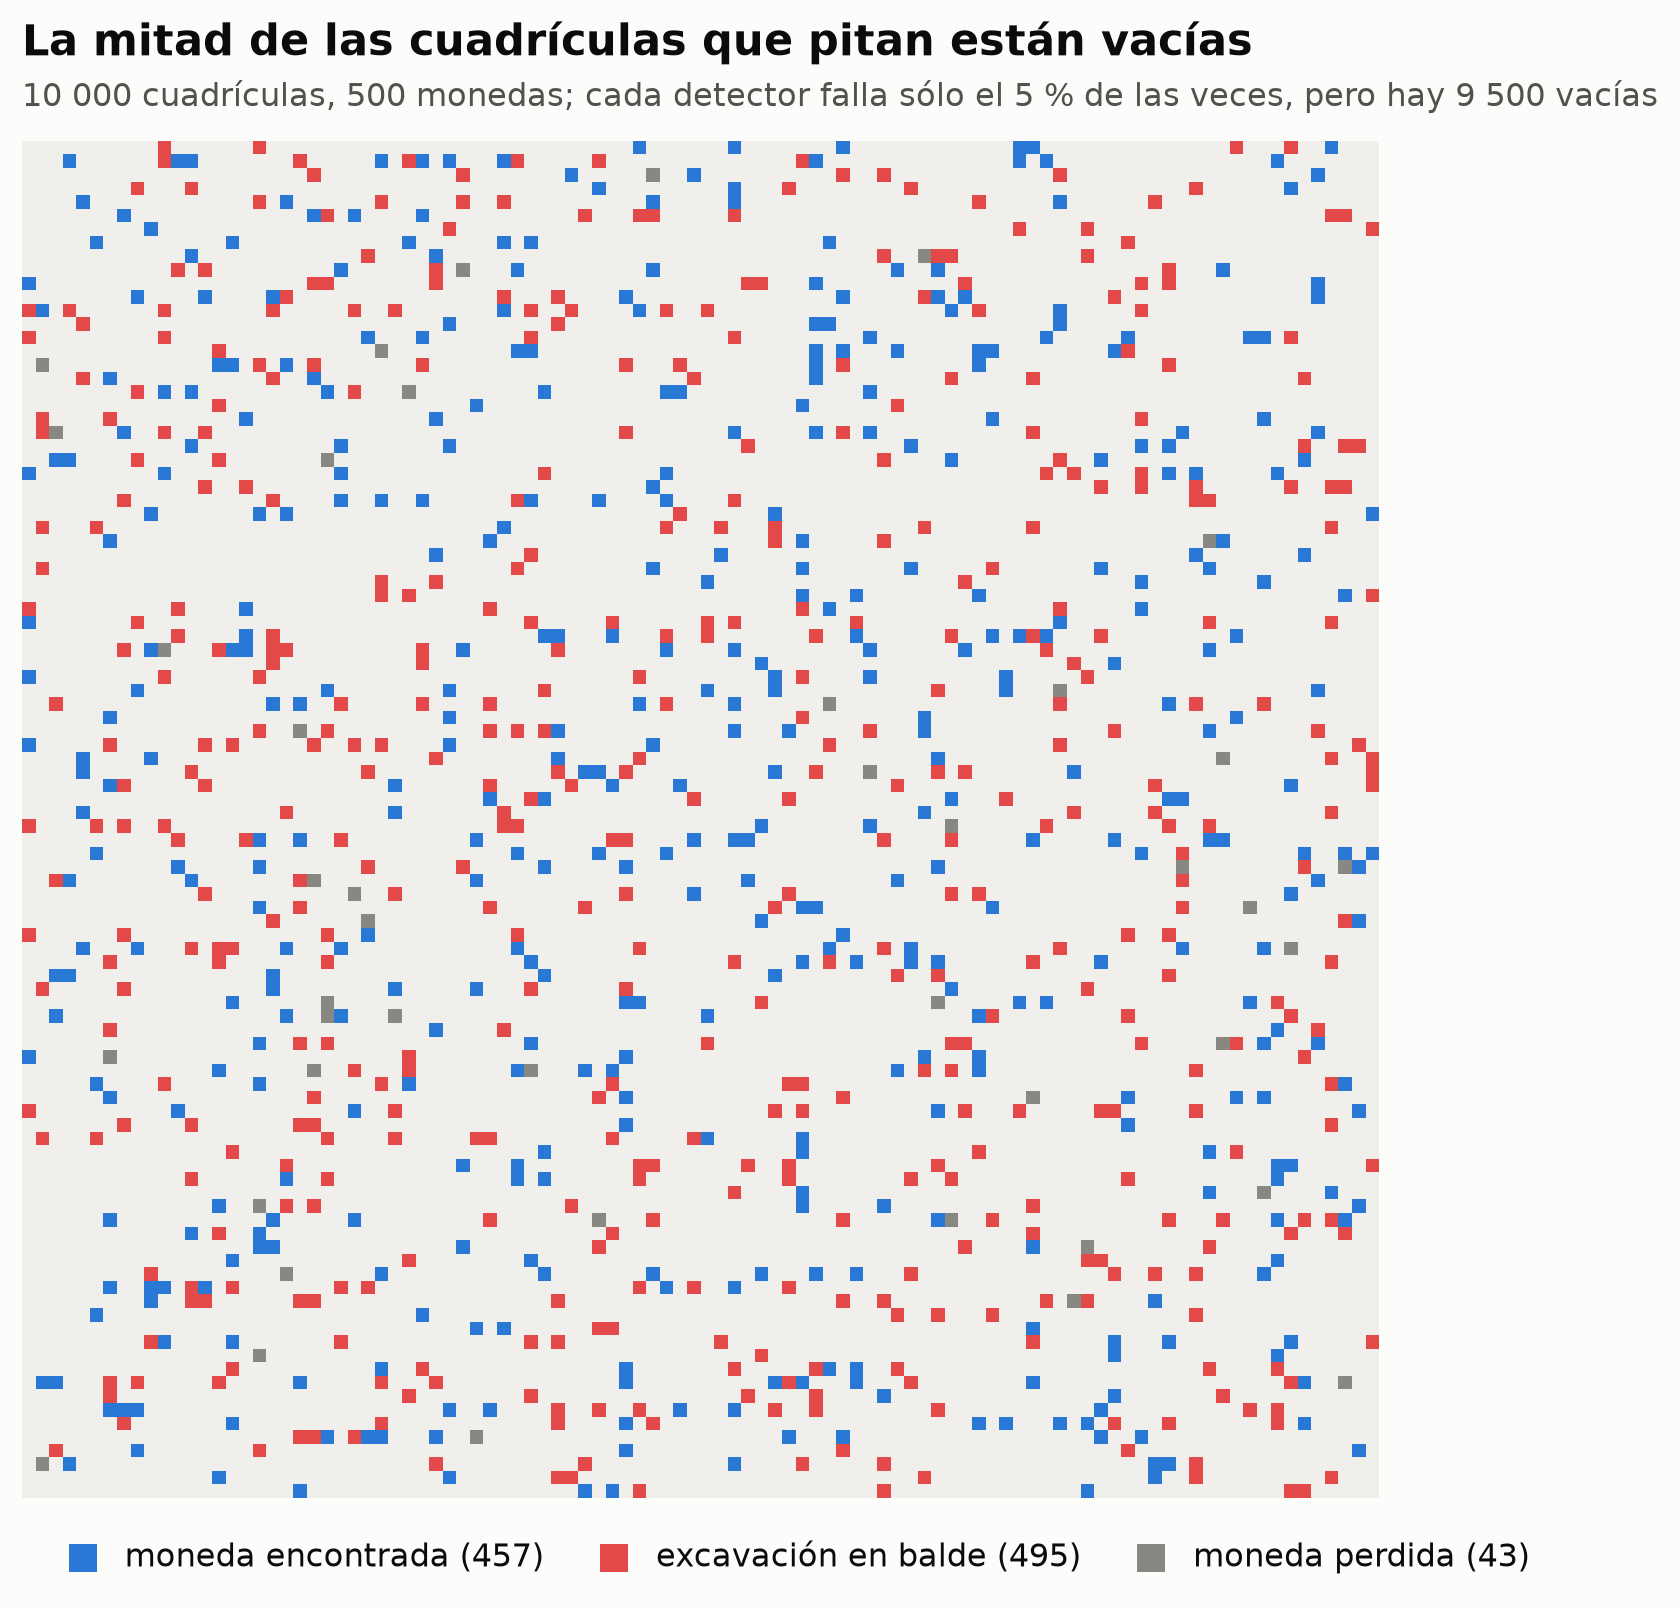

In [2]:
# La playa simulada: 10 000 cuadrículas, 500 monedas, detector con 5 % de falsas alarmas y 90 % de acierto
rng_beach = np.random.default_rng(2014)
def beach(n_coins, n=10_000, fa=0.05, power=0.90, rng=rng_beach):
    coin = np.zeros(n, bool); coin[:n_coins] = True
    beep = np.where(coin, rng.random(n) < power, rng.random(n) < fa)
    return coin, beep

for n_coins in (500, 50):
    coin, beep = beach(n_coins)
    exp_false = (10_000 - n_coins) * 0.05; exp_true = n_coins * 0.9
    print(f"{n_coins:3d} monedas → pitan {beep.sum():4d} (esperado {exp_true + exp_false:.0f}); "
          f"en balde {np.sum(beep & ~coin):3d} = {np.mean(~coin[beep]):.0%} "
          f"(esperado {exp_false / (exp_false + exp_true):.0%})")

# Figura: la misma playa como mapa de 100 x 100 cuadrículas
coin, beep = beach(500)
perm = rng_beach.permutation(10_000)
state = np.select([beep & coin, beep & ~coin, ~beep & coin], [3, 2, 1], 0)[perm].reshape(100, 100)
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#f0efec", ec.MUTED, ec.RED, ec.BLUE])
fig, ax = plt.subplots(figsize=(8.6, 7.2))
ax.imshow(state, cmap=cmap, vmin=0, vmax=3, interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
for s in ax.spines.values(): s.set_visible(False)
labels = [(3, ec.BLUE, f"moneda encontrada ({np.sum(beep & coin)})"),
          (2, ec.RED, f"excavación en balde ({np.sum(beep & ~coin)})"),
          (1, ec.MUTED, f"moneda perdida ({np.sum(~beep & coin)})")]
for k, (v, c, t) in enumerate(labels):
    ax.scatter([], [], s=80, marker="s", color=c, label=t)
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.01), ncol=3, frameon=False, fontsize=10.5,
          handletextpad=0.3, columnspacing=1.2)
ec.title(ax, "La mitad de las cuadrículas que pitan están vacías",
         "10 000 cuadrículas, 500 monedas; cada detector falla sólo el 5 % de las veces, pero hay 9 500 vacías")
plt.show()

> 🔎 **Qué observamos.** Los puntos rojos (excavaciones en balde) son tan abundantes como los azules (monedas
> encontradas), aunque cada detector sea individualmente bueno. El problema no es el detector sino **la cantidad de
> cuadrículas vacías**: 9 500 oportunidades de equivocarse. Con sólo 50 monedas, la proporción de excavaciones inútiles
> sube a más del 90 %: cuanto más rara es la señal, más engañosa es una lista hecha con un umbral fijo.

> ✅ **Compruebe su comprensión.** En un experimento con 20 000 genes en el que el tratamiento **no hace nada**,
> ¿cuántos genes esperaría con $p<0{,}05$? ¿Y con $p<0{,}001$?

## 2. El experimento simulado del libro y el GLM binomial negativo

### 2.1 Por qué empezar con una simulación

En un experimento real **nunca sabemos** qué genes cambian de verdad, así que no podemos contar falsos positivos. En una
simulación sí: fabricamos los datos con reglas conocidas y luego comprobamos si los métodos recuperan la verdad. El
libro usa un experimento simulado de **3 controles frente a 3 tratados**, con 10 000 genes de los que un 10 % cambia de
verdad; tras quitar los genes sin ninguna lectura quedan **9 992 genes y 946 cambios reales**. Lo reproducimos con la
**misma semilla**. El script del libro (`generar.py`) usa un único generador de números aleatorios para todo el
capítulo; guardamos en `data/113_rng_libro.json` su **estado** justo antes de esta simulación, de modo que obtenemos
exactamente los mismos conteos sin repetir las simulaciones de las secciones anteriores.

### 2.2 El modelo, en una frase y en una ecuación

Para cada gen $i$ y muestra $j$, el conteo $K_{ij}$ se modela como una binomial negativa cuya media es la expresión
normalizada del gen multiplicada por el factor de tamaño de la muestra (subsección «El modelo lineal generalizado» del libro):

$$
K_{ij}\sim\mathrm{NB}\!\left(\mu_{ij},\,\alpha_i\right),\qquad
\mu_{ij}=s_j\,q_{ij},\qquad
\log_2 q_{ij}=\sum_{r}x_{jr}\,\beta_{ir},
\qquad \operatorname{Var}(K_{ij})=\mu_{ij}+\alpha_i\,\mu_{ij}^2 .
$$

| Símbolo | Significado |
|---|---|
| $K_{ij}$ | Conteo de lecturas del gen $i$ en la muestra $j$ |
| $s_j$ | Factor de tamaño de la muestra (mediana de razones); desplazamiento fijo, no se estima gen a gen |
| $q_{ij}$ | Expresión normalizada esperada del gen $i$ en la muestra $j$ |
| $x_{jr}$ | Matriz de diseño $X$: condición, lote, línea celular… de la muestra $j$ |
| $\beta_{ir}$ | Coeficientes del gen $i$; con el diseño «$\sim$ condición», $\beta_{i,\mathrm{cond}}$ es el LFC ($\log_2$ del cambio) |
| $\alpha_i$ | Dispersión propia del gen $i$ (variabilidad biológica por encima de la de Poisson) |

Los coeficientes se estiman por **mínimos cuadrados iterativamente reponderados** (IRLS). En cada iteración se resuelve
una regresión ponderada cuyos pesos son la información de Fisher de cada observación; al converger, esa misma matriz da
los errores estándar:

$$
W_{jj}=\frac{\mu_{ij}}{1+\alpha_i\mu_{ij}},\qquad
\widehat{\mathrm{Cov}}(\hat\beta_i)=\left(X^{\top}WX\right)^{-1}.
$$

| Símbolo | Significado |
|---|---|
| $W$ | Matriz diagonal de pesos: la información que aporta cada muestra |
| $X$ | Matriz de diseño (muestras $\times$ coeficientes) |

Una lectura cotidiana del peso: una muestra con muchos conteos informa más que una con pocos, **pero no sin límite**.
Cuando $\mu\to\infty$, $W_{jj}\to 1/\alpha_i$: por mucho que secuenciemos, la variación biológica entre réplicas pone un
techo a lo que una sola muestra puede decirnos. El IRLS trabaja en logaritmo natural; para pasar a $\log_2$ se divide
$\hat\beta$ y $\widehat{\mathrm{SE}}$ por $\ln 2$.

La celda siguiente es el código del libro, sin cambios de fondo: simula los conteos, estima los factores de tamaño y las
dispersiones (gen a gen, tendencia y contracción, como en la Lección 11.2) y ajusta el GLM por IRLS.

> 🤔 **Antes de ejecutar, prediga.** El experimento tiene 946 genes con cambio real. Con sólo tres réplicas por grupo,
> ¿qué fracción cree que llegaremos a detectar con una FDR del 10 %: casi todos, la mitad, menos de la mitad?

In [3]:
# ---- Estado del generador del libro justo antes de la simulación ----
state = json.load(open(course_file("113_rng_libro.json")))["sim_11_3"]
rng = np.random.default_rng(); rng.bit_generator.state = state

def nb_rvs(mu, a, size=None):
    """NB con media mu y dispersión a (Var = mu + a mu^2), como mezcla gamma-Poisson."""
    r = 1.0 / a
    lam = rng.gamma(r, mu / r, size=size)
    return rng.poisson(lam)

# ---- Simulación (generar.py del libro) ----
G = 10000
glen_g = np.exp(rng.normal(np.log(2000), 0.8, G))        # longitud (pb)
rate = np.exp(rng.normal(-4.2, 1.2, G))                  # expresión por pb
q0 = rate * glen_g                                      # media base (control)
a_tr = lambda m: 0.05 + 1.0 / m                          # tendencia verdadera de la dispersión
disp = a_tr(q0) * np.exp(rng.normal(0, 0.3, G))
de = rng.random(G) < 0.10                                # ¿cambio real?
lfc = np.zeros(G)
lfc[de] = (0.5 + rng.exponential(0.8, de.sum())) * rng.choice([-1, 1], de.sum())
s_true = np.array([0.8, 1.2, 1.0, 0.9, 1.3, 1.1])
cond = np.array([0, 0, 0, 1, 1, 1])
mu = q0[:, None] * 2 ** (lfc[:, None] * cond[None, :]) * s_true[None, :]
Y = nb_rvs(mu, disp[:, None])
keepg = Y.sum(1) > 0
Y, de, lfc, glen_g, disp = Y[keepg], de[keepg], lfc[keepg], glen_g[keepg], disp[keepg]
G = Y.shape[0]
print(f"genes con alguna lectura = {G}; cambios reales = {de.sum()}; lecturas por muestra = {Y.sum(0)}")

# ---- Factores de tamaño (mediana de razones) ----
okg = (Y > 0).all(1)
lgy = np.log(Y[okg])
sf = np.exp(np.median(lgy - lgy.mean(1)[:, None], axis=0))
Yn = Y / sf[None, :]
base = Yn.mean(1)                                       # media normalizada («baseMean»)
X = np.column_stack([np.ones(6), cond])
print("factores de tamaño s_j =", np.round(sf, 3))

# ---- Dispersiones: gen a gen (perfil con ajuste de Cox-Reid), tendencia, previa y MAP ----
qg = np.stack([Yn[:, cond == c].mean(1) for c in (0, 1)], 1)
mu_hat = np.maximum(qg[:, cond] * sf[None, :], 1e-8)
grid = np.exp(np.linspace(np.log(1e-4), np.log(20), 300))
LLg = np.stack([nb_ll(Y, mu_hat, a).sum(1) for a in grid], 1)
def cr_adj(a):
    Wm = mu_hat / (1 + a * mu_hat)
    s00 = Wm.sum(1); s01 = (Wm * cond).sum(1)
    return -0.5 * np.log(s00 * s01 - s01 ** 2)
LLg += np.stack([cr_adj(a) for a in grid], 1)
a_gw = grid[LLg.argmax(1)]
fitm = (base > 1) & (a_gw > 1e-3) & (a_gw < grid[-1])
def gdev(p):
    f = np.abs(p[0]) + np.abs(p[1]) / base[fitm]
    r = a_gw[fitm] / f
    return 2 * np.sum(r - np.log(r) - 1)
pt = optimize.minimize(gdev, [0.1, 1.0], method="Nelder-Mead").x
a0h, a1h = abs(pt[0]), abs(pt[1])
a_fit = a0h + a1h / base
res = np.log(a_gw[fitm]) - np.log(a_fit[fitm])
s2p = max(stats.median_abs_deviation(res, scale="normal") ** 2 - special.polygamma(1, (6 - 2) / 2), 0.25)
logprior = -0.5 * (np.log(grid)[None, :] - np.log(a_fit)[:, None]) ** 2 / s2p
a_map = grid[(LLg + logprior).argmax(1)]
outl = np.log(a_gw) > np.log(a_fit) + 2 * np.sqrt(s2p)
a_final = np.where(outl, a_gw, a_map)
print(f"tendencia de la dispersión: α(μ) = {a0h:.4f} + {a1h:.3f}/μ   (verdad: 0,05 + 1/μ)")

# ---- GLM NB por IRLS (dos coeficientes, desplazamiento log s_j), escrito para 2x2 ----
def irls(Y, a, iters=30):
    off = np.log(sf)[None, :]
    b = np.stack([np.log(np.maximum(qg[:, 0], 0.1)),
                  np.log(np.maximum(qg[:, 1], 0.1)) - np.log(np.maximum(qg[:, 0], 0.1))], 1)
    for _ in range(iters):
        eta = b @ X.T + off
        m = np.exp(eta)
        Wt = m / (1 + a[:, None] * m)                   # pesos W_jj
        z = eta - off + (Y - m) / m                      # respuesta de trabajo
        s00 = Wt.sum(1); s01 = (Wt * cond).sum(1); s11 = s01
        r0 = (Wt * z).sum(1); r1 = (Wt * z * cond).sum(1)
        det = s00 * s11 - s01 ** 2
        b = np.stack([(s11 * r0 - s01 * r1) / det, (s00 * r1 - s01 * r0) / det], 1)
        b = np.clip(b, -30, 30)
    m = np.exp(b @ X.T + off)
    Wt = m / (1 + a[:, None] * m)
    s00 = Wt.sum(1); s01 = (Wt * cond).sum(1)
    det = s00 * s01 - s01 ** 2
    se1 = np.sqrt(s00 / det)                            # raíz del elemento (2,2) de (XᵀWX)⁻¹
    return b, se1, m

with np.errstate(all="ignore"):
    b, se, mfit = irls(Y, a_final)
lfc_hat = b[:, 1] / np.log(2)                           # LFC en log2
se2 = se / np.log(2)
print(f"GLM ajustado para {G} genes · tiempo acumulado {time.time() - T0:.1f} s")

genes con alguna lectura = 9992; cambios reales = 946; lecturas por muestra = [ 675778 1027991  853182  832330 1216167 1022638]
factores de tamaño s_j = [0.784 1.175 0.98  0.888 1.283 1.088]


tendencia de la dispersión: α(μ) = 0.0480 + 1.757/μ   (verdad: 0,05 + 1/μ)
GLM ajustado para 9992 genes · tiempo acumulado 0.7 s


> 🔎 **Qué observamos.** Los factores de tamaño estimados, $(0{,}784;\ 1{,}175;\ 0{,}98;\ 0{,}888;\ 1{,}283;\ 1{,}088)$,
> reproducen los verdaderos reescalados del libro, y la tendencia de la dispersión, $0{,}0480+1{,}757/\mu$, se parece a
> la verdadera $0{,}05+1/\mu$. Ya tenemos, para cada gen, un $\hat\beta_{i,\mathrm{cond}}$ y su error estándar. Falta
> la pregunta estadística.

## 3. Contrastes sobre el modelo: Wald y razón de verosimilitudes

### 3.1 La idea en palabras

Con el GLM ajustado, la pregunta «¿cambia la expresión del gen $i$ entre condiciones?» se convierte en la **hipótesis
nula** $H_0:\beta_{i,\mathrm{cond}}=0$. Hay dos maneras naturales de ponerla a prueba:

* **Wald**: mirar cuántos errores estándar separan la estimación de cero. Es como juzgar una balanza por la distancia de
  la aguja al cero *en unidades de su temblor*: una aguja que marca 2 g con un temblor de 0,1 g es convincente; una que
  marca 2 g con un temblor de 3 g, no.
* **Razón de verosimilitudes (LRT)**: ajustar dos modelos, uno **con** el término de condición y otro **sin** él, y
  preguntar cuánto mejora el ajuste al añadirlo.

### 3.2 La prueba de Wald

$$
z_i=\frac{\hat\beta_{i,\mathrm{cond}}}{\widehat{\mathrm{SE}}(\hat\beta_{i,\mathrm{cond}})},\qquad p_i=2\,\Phi\!\left(-|z_i|\right).
$$

| Símbolo | Significado |
|---|---|
| $\hat\beta_{i,\mathrm{cond}}$ | LFC estimado del gen $i$ entre condiciones (en $\log_2$) |
| $\widehat{\mathrm{SE}}$ | Raíz del elemento diagonal correspondiente de $(X^\top WX)^{-1}$, convertido a escala $\log_2$ |
| $\Phi$ | Función de distribución de la normal estándar |

**Resuelto a mano.** Un gen del experimento simulado tiene $\hat\beta=4{,}20$ y $\widehat{\mathrm{SE}}=1{,}76$
(volveremos a él en la sección 4). Entonces $z=4{,}20/1{,}76=2{,}39$ y

$$
p=2\,\Phi(-2{,}39)=2\times0{,}0085\approx0{,}017 .
$$

Con el umbral clásico de 0,05, este gen sería «significativo». Guarde esa sospecha.

### 3.3 La prueba de razón de verosimilitudes

$$
D_i=2\left[\ell_i\big(\hat\beta^{\,\mathrm{completo}}\big)-\ell_i\big(\hat\beta^{\,\mathrm{reducido}}\big)\right]\;\overset{H_0}{\sim}\;\chi^2_{\,p_c-p_r}.
$$

| Símbolo | Significado |
|---|---|
| $\ell_i(\cdot)$ | Log-verosimilitud binomial negativa del gen $i$, con la dispersión fija en su estimación final |
| $p_c,\ p_r$ | Número de coeficientes de los modelos completo y reducido |
| $D_i$ | Devianza: dos veces la ganancia en log-verosimilitud al añadir los términos de interés |

Aquí el modelo completo tiene $p_c=2$ coeficientes (intercepto y condición) y el reducido $p_r=1$ (sólo intercepto: la
misma expresión en las seis muestras), así que $D_i$ se compara con una $\chi^2_1$.

> 🤔 **Antes de ejecutar, prediga.** Para un único coeficiente, ¿espera que Wald y LRT den valores $p$ muy distintos o
> casi iguales? ¿En qué genes esperaría las mayores discrepancias?

correlación de log10 p (Wald frente a LRT) = 0.9903   (libro: 0,990)
z = 4,20/1,76 = 2.39  →  p = 2Φ(−|z|) = 0.017


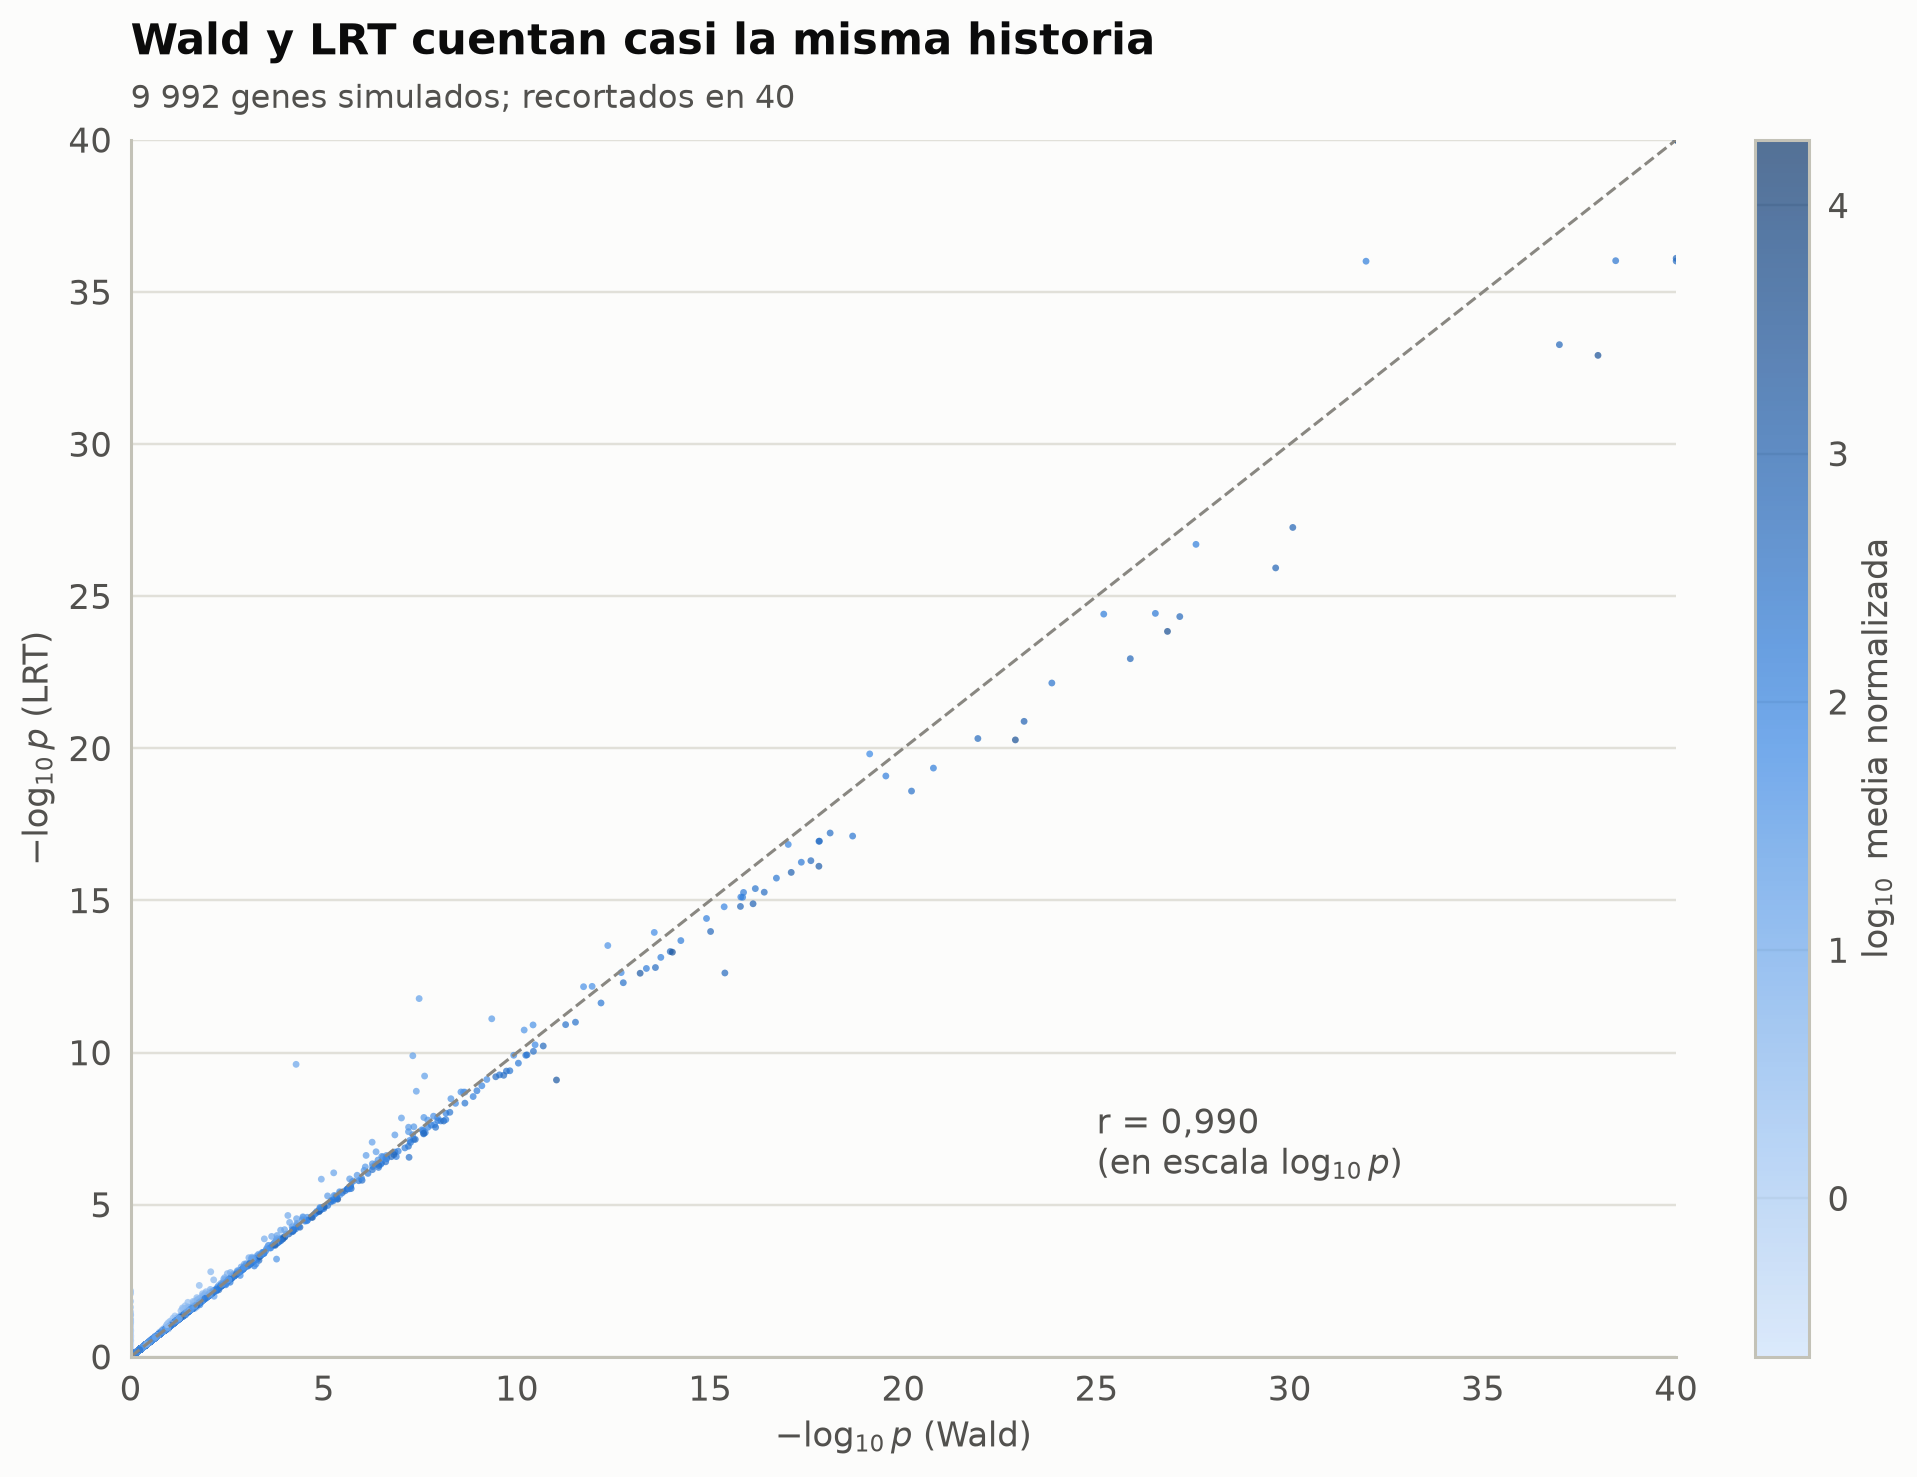

In [4]:
# Prueba de Wald (libro) y LRT (modelo completo frente a reducido)
wald = lfc_hat / se2
pval = 2 * stats.norm.sf(np.abs(wald))
m_red = np.maximum(Yn.mean(1), 1e-8)[:, None] * sf[None, :]          # modelo reducido: sin condición
lrt = 2 * (nb_ll(Y, mfit, a_final[:, None]).sum(1) - nb_ll(Y, m_red, a_final[:, None]).sum(1))
p_lrt = stats.chi2.sf(np.maximum(lrt, 0), 1)
r_wl = np.corrcoef(np.log10(pval + 1e-300), np.log10(p_lrt + 1e-300))[0, 1]
print(f"correlación de log10 p (Wald frente a LRT) = {r_wl:.4f}   (libro: 0,990)")

# Comprobación de la cuenta a mano
print(f"z = 4,20/1,76 = {4.20 / 1.76:.2f}  →  p = 2Φ(−|z|) = {2 * stats.norm.sf(4.20 / 1.76):.3f}")

# Figura: -log10 p de Wald frente a LRT, coloreado por la media normalizada
fig, (ax, cax) = plt.subplots(1, 2, figsize=(8.6, 6.6), gridspec_kw={"width_ratios": [1, 0.035], "wspace": 0.06})
lw, ll_ = -np.log10(pval), -np.log10(p_lrt)
sc = ax.scatter(np.minimum(lw, 40), np.minimum(ll_, 40), c=np.log10(base + 0.1), cmap=ec.CMAP_SEQ, s=5,
                alpha=0.7, edgecolors="none")
ax.plot([0, 40], [0, 40], color=ec.MUTED, ls="--", lw=1)
ax.set_xlim(0, 40); ax.set_ylim(0, 40)
ax.set_xlabel("$-\\log_{10} p$ (Wald)"); ax.set_ylabel("$-\\log_{10} p$ (LRT)")
cb = fig.colorbar(sc, cax=cax); cb.set_label("$\\log_{10}$ media normalizada")
ax.text(25, 6, f"r = {fmt(r_wl, 3)}\n(en escala $\\log_{{10}} p$)", fontsize=11, color=ec.INK_2)
ec.title(ax, "Wald y LRT cuentan casi la misma historia",
         "9 992 genes simulados; recortados en 40")
plt.show()

> 🔎 **Qué observamos.** Los puntos se agolpan sobre la diagonal y la correlación, $0{,}990$, coincide con la del libro.
> Para un solo coeficiente las dos pruebas son **asintóticamente equivalentes**; donde más se separan es en los genes
> claros (pocas lecturas), para los que la aproximación normal del Wald es más pobre. La LRT brilla cuando queremos
> contrastar **varios coeficientes a la vez**: «¿cambia la expresión a lo largo de cualquiera de los cinco tiempos?» o
> «¿hay efecto de la línea celular?» (lo haremos con datos reales en la sección 9). La prueba de Wald, además de un
> valor $p$, entrega directamente el tamaño del efecto con su error estándar.

> ✅ **Compruebe su comprensión.** Un gen tiene $\hat\beta=-1{,}2$ y $\widehat{\mathrm{SE}}=0{,}4$. ¿Cuánto valen $z$ y
> $p$? (Respuesta: $z=-3$, $p=2\Phi(-3)\approx0{,}0027$.)

## 4. Tamaños de efecto: la contracción del LFC

### 4.1 El problema, con números pequeños

El LFC de máxima verosimilitud tiene un defecto grave en los genes con pocas lecturas: **es enormemente variable**.
Considere un gen con conteos $0,1,0$ en el control y $4,2,6$ en el tratamiento (con factores de tamaño iguales a 1). La
media del control es $1/3$ y la del tratamiento $12/3=4$, así que

$$
\widehat{\mathrm{LFC}}=\log_2\frac{4}{1/3}=\log_2 12\approx3{,}58 .
$$

¡Un cambio de doce veces! Pero una sola lectura de más o de menos en el control lo movería a $+\infty$ o a $2{,}58$: el
número no significa casi nada. Si ordenamos los genes por LFC para elegir candidatos a validar por PCR, **la cabeza de
la lista se llenará de genes ruidosos poco expresados**. Es como premiar al mejor bateador de la liga entre jugadores que
sólo han ido al bate dos veces: el que acertó las dos tiene un promedio perfecto que no volverá a repetir.

### 4.2 La solución: una previa que tira hacia cero

Love, Huber y Anders (2014) propusieron **contraer** los LFC hacia cero con una previa normal ajustada a los propios
datos, $\beta_i\sim\mathcal N(0,\sigma_p^2)$. La estimación resultante es, aproximadamente, la media *a posteriori*:

$$
\tilde\beta_i\;\approx\;\hat\beta_i\,\frac{\sigma_p^2}{\sigma_p^2+\widehat{\mathrm{SE}}_i^{\,2}}.
$$

| Símbolo | Significado |
|---|---|
| $\tilde\beta_i$ | LFC contraído del gen $i$ |
| $\sigma_p^2$ | Varianza previa de los LFC verdaderos, estimada de la distribución de los LFC observados |
| $\widehat{\mathrm{SE}}_i$ | Error estándar del LFC de máxima verosimilitud |

El factor $\sigma_p^2/(\sigma_p^2+\widehat{\mathrm{SE}}_i^2)$ está entre 0 y 1 y depende **sólo** de lo bien medido que
esté el gen: si $\widehat{\mathrm{SE}}_i\ll\sigma_p$, el factor es casi 1 y el LFC apenas cambia; si
$\widehat{\mathrm{SE}}_i\gg\sigma_p$, el LFC se acerca mucho a cero. Es el mismo razonamiento que la contracción de
dispersiones de la Lección 11.2: cuando la información propia es escasa, pesa más lo que sabemos del conjunto.

Como en el libro, estimamos $\sigma_p$ a partir de los genes con media normalizada mayor que 5: si los LFC fueran normales
con desviación $\sigma_p$, el 95 % de los $|\hat\beta|$ quedaría por debajo de $1{,}96\,\sigma_p$, así que
$\hat\sigma_p=q_{0,95}(|\hat\beta|)/1{,}96$.

In [5]:
# Contracción con previa normal (al estilo de DESeq2 2014, como en el libro)
use = base > 5
sp = np.quantile(np.abs(lfc_hat[use]), 0.95) / stats.norm.ppf(0.975)
shrink_factor = sp ** 2 / (sp ** 2 + se2 ** 2)
lfc_shr = lfc_hat * shrink_factor
mse_mle = np.mean((lfc_hat - lfc)[base > 1] ** 2)
mse_shr = np.mean((lfc_shr - lfc)[base > 1] ** 2)
print(f"σ_p = {sp:.3f}   (libro: 0,650)")
print(f"ECM del LFC frente a la verdad (genes con media > 1): MV = {mse_mle:.3f}  →  contraído = {mse_shr:.3f}"
      "   (libro: 1,24 → 0,117)")

# «Un gen ruidoso»: el gen SIN cambio real con mayor |LFC| entre los de media 1–5 (criterio de generar.py)
gi = int(np.argmax(np.where((base > 1) & (base < 5) & (se2 < 5), np.abs(lfc_hat) * (~de), 0)))
print(f"\nUn gen ruidoso → media = {base[gi]:.2f}; LFC MV = {lfc_hat[gi]:.2f}; SE = {se2[gi]:.2f}; "
      f"p = {pval[gi]:.3f}; LFC contraído = {lfc_shr[gi]:.2f}; LFC verdadero = {lfc[gi]:.0f}")
print(f"conteos: control {Y[gi, :3]}, tratado {Y[gi, 3:]}; factores s_j = {np.round(sf, 2)}")
print(f"cuenta a mano: 4,20 × 0,650² / (0,650² + 1,76²) = {4.20 * 0.650**2 / (0.650**2 + 1.76**2):.3f}")

σ_p = 0.650   (libro: 0,650)
ECM del LFC frente a la verdad (genes con media > 1): MV = 1.240  →  contraído = 0.117   (libro: 1,24 → 0,117)

Un gen ruidoso → media = 3.15; LFC MV = 4.20; SE = 1.76; p = 0.017; LFC contraído = 0.51; LFC verdadero = 0
conteos: control [0 1 0], tratado [ 4 15  2]; factores s_j = [0.78 1.17 0.98 0.89 1.28 1.09]
cuenta a mano: 4,20 × 0,650² / (0,650² + 1,76²) = 0.504


> 🔎 **Qué observamos: el ejemplo «Un gen ruidoso» del libro.** Un gen **sin** cambio real y con media normalizada de
> $3{,}15$ lecturas obtuvo un LFC de máxima verosimilitud de $4{,}20$ (¡18 veces!), con error estándar $1{,}76$ y
> $p=0{,}017$. Con la previa estimada, $\sigma_p=0{,}650$, su LFC contraído es
>
> $$4{,}20\times\frac{0{,}650^2}{0{,}650^2+1{,}76^2}=4{,}20\times0{,}120\approx0{,}51 .$$
>
> En el conjunto de genes con media mayor que 1, el error cuadrático medio del LFC respecto al valor verdadero baja de
> $1{,}24$ (máxima verosimilitud) a $0{,}117$ (contraído): **diez veces menos error**, a cambio de un pequeño sesgo
> hacia cero en los efectos grandes.

La figura siguiente muestra el factor de contracción como función del error estándar. Cada gen del experimento es un
punto, y el gen ruidoso está marcado.

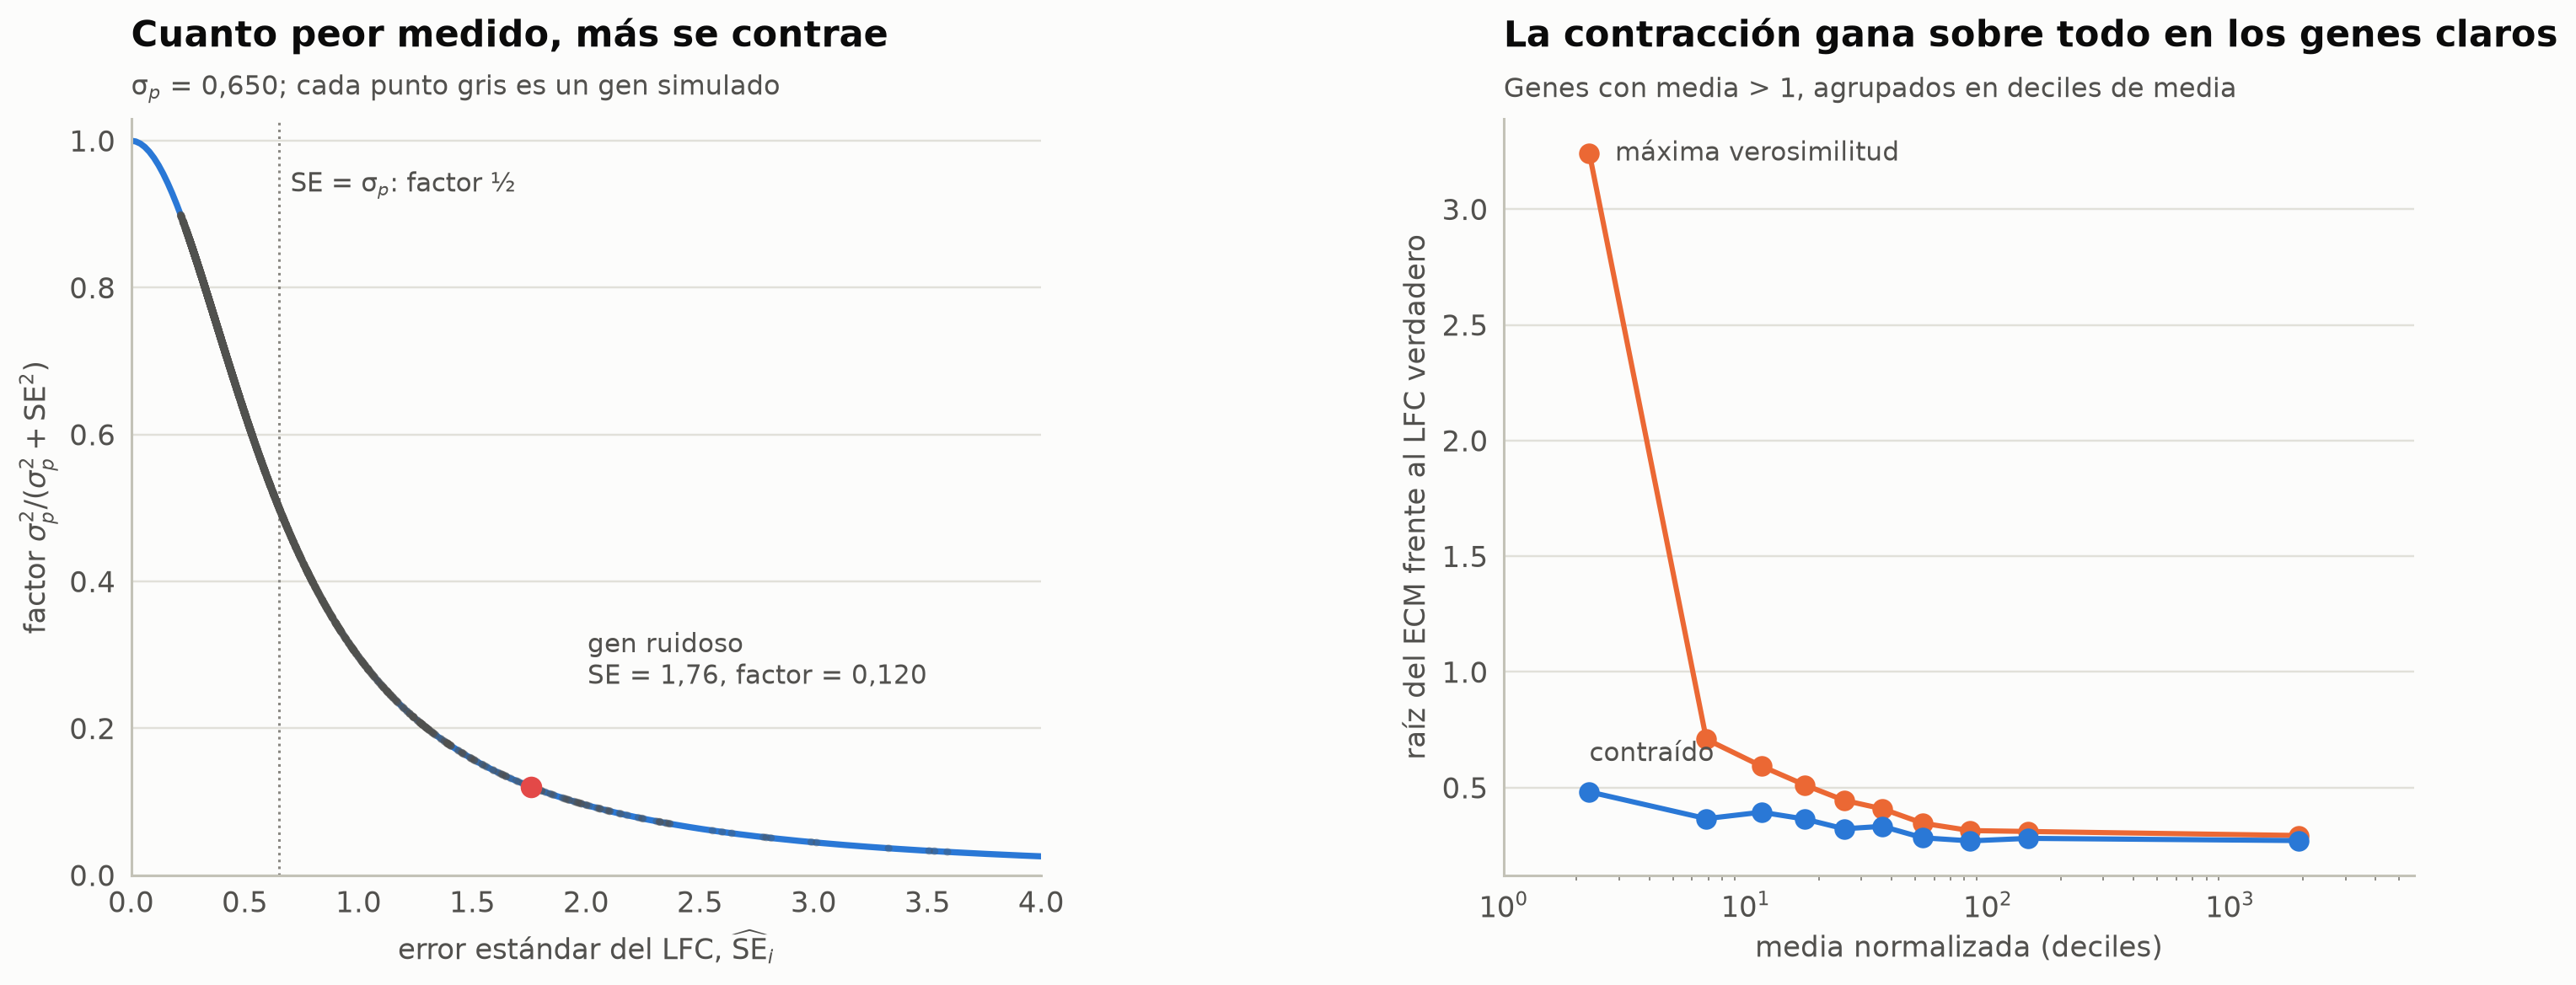

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={"wspace": 0.28})
ax = axes[0]
se_grid = np.linspace(0, 4, 200)
ax.plot(se_grid, sp ** 2 / (sp ** 2 + se_grid ** 2), color=ec.BLUE, lw=2.4)
sub = np.random.default_rng(1).choice(G, 3000, replace=False)
ax.scatter(se2[sub], shrink_factor[sub], s=9, color=ec.INK_2, alpha=0.35, edgecolors="none", zorder=3)
ax.scatter([se2[gi]], [shrink_factor[gi]], s=70, color=ec.RED, zorder=5)
ax.annotate(f"gen ruidoso\nSE = {fmt(se2[gi])}, factor = {fmt(shrink_factor[gi], 3)}", (se2[gi], shrink_factor[gi]),
            xytext=(22, 40), textcoords="offset points", fontsize=10, color=ec.INK_2,
            arrowprops=dict(arrowstyle="-", color=ec.MUTED))
ax.axvline(sp, color=ec.MUTED, ls=":", lw=1)
ax.text(sp + 0.05, 0.93, "SE = σ$_p$: factor ½", fontsize=10, color=ec.INK_2)
ax.set_xlim(0, 4); ax.set_ylim(0, 1.03)
ax.set_xlabel("error estándar del LFC, $\\widehat{\\mathrm{SE}}_i$"); ax.set_ylabel("factor $\\sigma_p^2/(\\sigma_p^2+\\mathrm{SE}^2)$")
ec.title(ax, "Cuanto peor medido, más se contrae", f"σ$_p$ = {fmt(sp, 3)}; cada punto gris es un gen simulado")

ax = axes[1]
ok = base > 1
err_mle = np.abs(lfc_hat - lfc)[ok]; err_shr = np.abs(lfc_shr - lfc)[ok]
bins_b = np.quantile(np.log10(base[ok]), np.linspace(0, 1, 11))
cen = 0.5 * (bins_b[1:] + bins_b[:-1]); idx = np.clip(np.digitize(np.log10(base[ok]), bins_b) - 1, 0, 9)
rm_mle = [np.sqrt(np.mean(err_mle[idx == k] ** 2)) for k in range(10)]
rm_shr = [np.sqrt(np.mean(err_shr[idx == k] ** 2)) for k in range(10)]
ax.plot(10 ** cen, rm_mle, "o-", color=ec.ORANGE, lw=2); ec.label_end(ax, 10 ** cen[0], rm_mle[0], "máxima verosimilitud", dx=10)
ax.plot(10 ** cen, rm_shr, "o-", color=ec.BLUE, lw=2)
ax.annotate("contraído", (10 ** cen[0], rm_shr[0]), xytext=(0, 12), textcoords="offset points", fontsize=10, color=ec.INK_2)
ax.set_xscale("log"); ax.set_xlim(1, 10 ** cen[-1] * 3)
ax.set_xlabel("media normalizada (deciles)"); ax.set_ylabel("raíz del ECM frente al LFC verdadero")
ec.title(ax, "La contracción gana sobre todo en los genes claros", "Genes con media > 1, agrupados en deciles de media")
plt.show()

> 🔎 **Qué observamos.** A la izquierda, la curva es la fórmula; los puntos grises caen exactamente sobre ella porque
> cada gen tiene su propio SE (sólo varía la posición a lo largo de la curva). El gen ruidoso, con $\mathrm{SE}=1{,}76\approx2{,}7\,\sigma_p$, conserva sólo un 12 % de
> su LFC. A la derecha, el error del LFC de máxima verosimilitud es enorme en los genes poco expresados y se reduce al
> subir la media; el contraído es pequeño en todo el rango. En los genes muy expresados ambas curvas se juntan: allí la
> contracción no hace nada, que es justo lo que queremos.

### 4.3 🎬 El embudo se cierra

La animación aplica la contracción poco a poco: empieza con una previa casi plana ($\sigma_p$ muy grande, sin
contracción) y la estrecha hasta el valor estimado, $\sigma_p=0{,}650$. Observe qué puntos se mueven y cuáles no.

![Vista previa: al estrechar la previa normal, los LFC de los genes poco expresados (izquierda) colapsan hacia cero y el embudo del gráfico MA se cierra; los genes significativos (rojo), bien medidos, apenas se mueven.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-11-rnaseq/11.3_embudo_contraccion.gif)

*Vista previa: al estrechar la previa normal, los LFC de los genes poco expresados (izquierda) colapsan hacia cero y el embudo del gráfico MA se cierra; los genes significativos (rojo), bien medidos, apenas se mueven.*

In [7]:
# 🎬 Animación: gráfico MA mientras σ_p baja de 20 a 0,650
padj_sim = bh(pval); sig = padj_sim < 0.1           # significativos con FDR < 0,1 (sección 6)
sig_list = np.linspace(np.log(20), np.log(sp), 36)
sig_frames = np.concatenate([np.full(6, sig_list[0]), sig_list, np.full(10, sig_list[-1])])
sub_ns = np.random.default_rng(3).choice(np.where(~sig & (base > 0.3))[0], 2500, replace=False)
fig, ax = plt.subplots(figsize=(9, 5.6))
ax.set_xscale("log"); ax.set_xlim(0.3, 3e4); ax.set_ylim(-6.3, 6.3)
ax.axhline(0, color=ec.INK_2, lw=0.8)
ax.set_xlabel("media normalizada"); ax.set_ylabel("$\\log_2$ fold change")
p_ns = ax.scatter(base[sub_ns], np.clip(lfc_hat[sub_ns], -6, 6), s=6, color=ec.MUTED, alpha=0.5, edgecolors="none")
p_sg = ax.scatter(base[sig], np.clip(lfc_hat[sig], -6, 6), s=9, color=ec.RED, alpha=0.8, edgecolors="none")
p_gi = ax.scatter([base[gi]], [lfc_hat[gi]], s=80, facecolor="none", edgecolor=ec.INK, lw=1.5)
info = ax.text(0.98, 0.95, "", transform=ax.transAxes, ha="right", va="top", fontsize=12.5, fontweight="bold")
ax.text(0.98, 0.05, "rojo: FDR < 0,1 · círculo: el gen ruidoso", transform=ax.transAxes, ha="right", fontsize=10,
        color=ec.INK_2)
ax.set_title("La previa encoge el ruido, no la señal bien medida", loc="left")
def update(f):
    s = np.exp(sig_frames[f]); k = s ** 2 / (s ** 2 + se2 ** 2)
    v = lfc_hat * k
    p_ns.set_offsets(np.column_stack([base[sub_ns], np.clip(v[sub_ns], -6, 6)]))
    p_sg.set_offsets(np.column_stack([base[sig], np.clip(v[sig], -6, 6)]))
    p_gi.set_offsets([[base[gi], v[gi]]])
    info.set_text(f"σ_p = {fmt(s, 3)}")
    return p_ns, p_sg, p_gi, info
update(0)
ec.animate(fig, update, frames=len(sig_frames), interval=140, name="11.3_embudo_contraccion")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

### 4.4 Normal o de colas pesadas

La previa normal tiene un inconveniente: **también encoge los efectos grandes y bien medidos**, porque su cola
considera muy improbables los cambios de 5 o 6 unidades $\log_2$. Zhu, Ibrahim y Love (2019) la reemplazaron por una
previa de **colas pesadas** (Cauchy) en el método *apeglm*: contrae con fuerza el ruido, pero deja casi intactos los
efectos grandes con evidencia sólida. Es la opción que recomiendan hoy DESeq2 y PyDESeq2.

Podemos verlo con la media *a posteriori* exacta, calculada por integración numérica sobre una rejilla de $\beta$, para
una verosimilitud normal $\hat\beta\sim\mathcal N(\beta,\mathrm{SE}^2)$ y dos previas con la misma escala $\sigma_p$.
Una idea importante antes de seguir: **la contracción cambia la estimación del tamaño de efecto, pero en DESeq2 los
valores $p$ siguen saliendo de la prueba de Wald sobre el LFC sin contraer.**

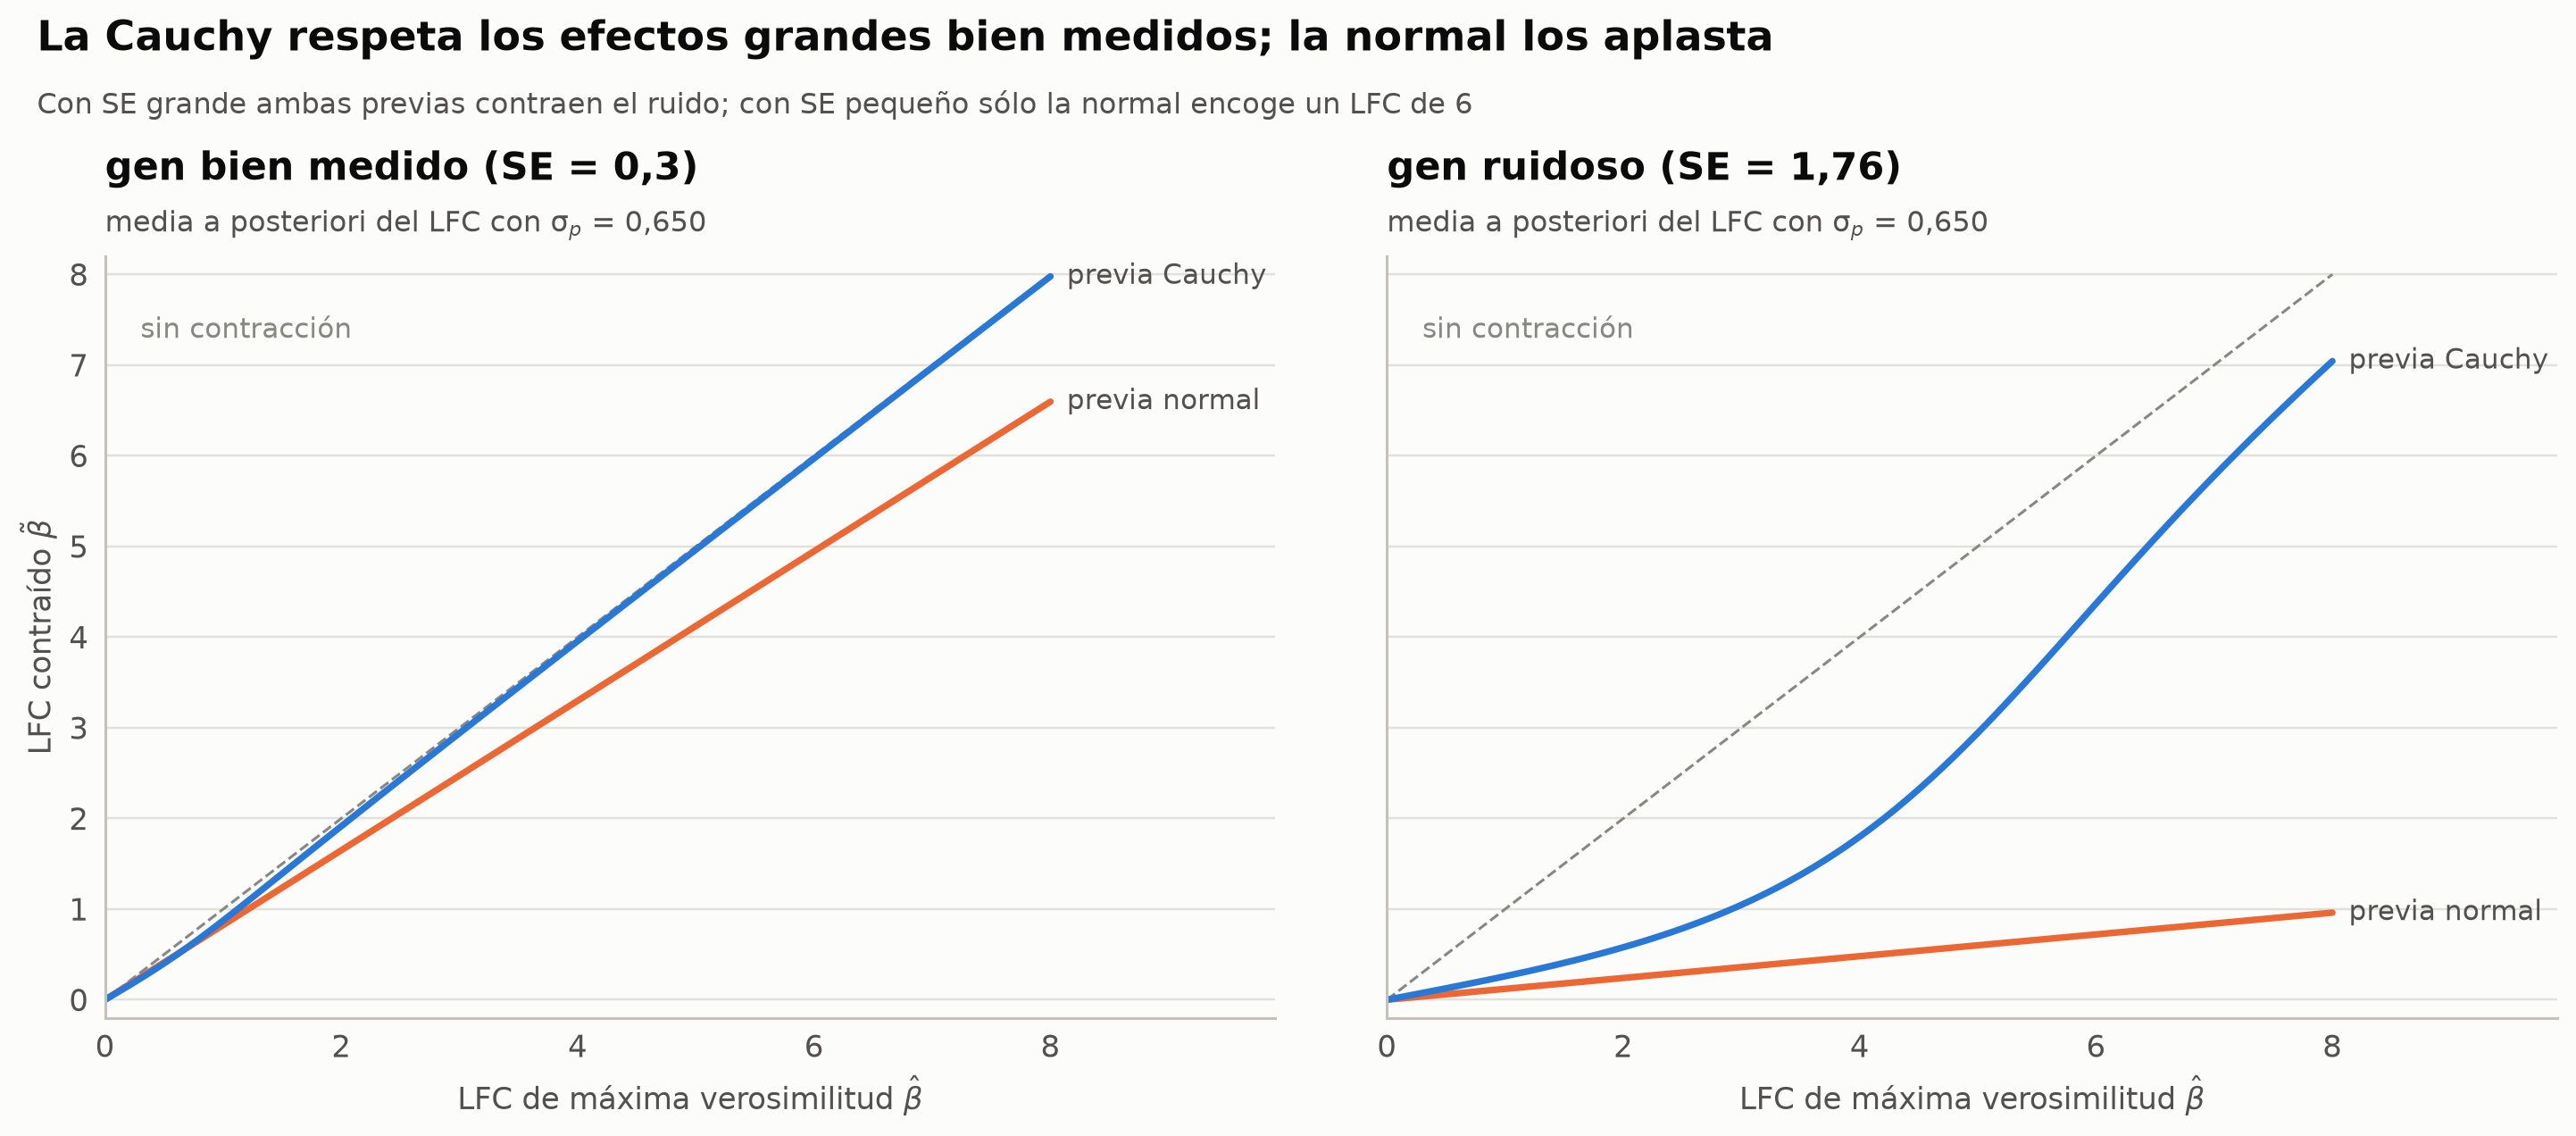

β̂ = 6, SE = 0,3 → normal: 4.95 · Cauchy: 5.97
β̂ = 4,2, SE = 1,76 → normal: 0.50 · Cauchy: 2.00


In [8]:
# Media a posteriori con previa normal y con previa de Cauchy (misma escala σ_p), por integración numérica
beta_grid = np.linspace(-15, 15, 6001)
def post_mean(bhat, se, prior):
    lik = stats.norm.pdf(bhat, loc=beta_grid, scale=se)
    w = lik * prior(beta_grid)
    return np.sum(beta_grid * w) / np.sum(w)
prior_norm = lambda b: stats.norm.pdf(b, scale=sp)
prior_cauchy = lambda b: stats.cauchy.pdf(b, scale=sp)

bh_grid = np.linspace(0, 8, 81)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True, gridspec_kw={"wspace": 0.08})
for ax, se_ex, lab in zip(axes, [0.3, 1.76], ["gen bien medido (SE = 0,3)", "gen ruidoso (SE = 1,76)"]):
    pn = [post_mean(x, se_ex, prior_norm) for x in bh_grid]
    pc = [post_mean(x, se_ex, prior_cauchy) for x in bh_grid]
    ax.plot(bh_grid, bh_grid, color=ec.MUTED, ls="--", lw=1)
    ax.plot(bh_grid, pn, color=ec.ORANGE, lw=2.4); ec.label_end(ax, bh_grid[-1], pn[-1], "previa normal")
    ax.plot(bh_grid, pc, color=ec.BLUE, lw=2.4); ec.label_end(ax, bh_grid[-1], pc[-1], "previa Cauchy")
    ax.text(0.3, 7.3, "sin contracción", fontsize=10, color=ec.MUTED, rotation=0)
    ax.set_xlim(0, 9.9); ax.set_ylim(-0.2, 8.2)
    ax.set_xlabel("LFC de máxima verosimilitud $\\hat\\beta$")
    ec.title(ax, lab, "media a posteriori del LFC con σ$_p$ = 0,650")
axes[0].set_ylabel("LFC contraído $\\tilde\\beta$")
ec.fig_title(fig, "La Cauchy respeta los efectos grandes bien medidos; la normal los aplasta",
             "Con SE grande ambas previas contraen el ruido; con SE pequeño sólo la normal encoge un LFC de 6")
plt.show()
print(f"β̂ = 6, SE = 0,3 → normal: {post_mean(6, 0.3, prior_norm):.2f} · Cauchy: {post_mean(6, 0.3, prior_cauchy):.2f}")
print(f"β̂ = 4,2, SE = 1,76 → normal: {post_mean(4.2, 1.76, prior_norm):.2f} · Cauchy: {post_mean(4.2, 1.76, prior_cauchy):.2f}")

> 🔎 **Qué observamos.** Con un gen bien medido (izquierda), la previa normal convierte un LFC de 6 en algo menor, pese
> a que la evidencia es abrumadora ($z=20$); la Cauchy lo deja casi intacto. Con un gen ruidoso (derecha) las dos
> previas contraen con fuerza. Esa es la esencia de *apeglm*: ser escéptico con el ruido sin castigar los efectos
> grandes que están bien documentados. Veremos este mismo contraste con un gen real (*ZBTB16*) en la sección 9.

> ✅ **Compruebe su comprensión.** Dos genes tienen el mismo $\hat\beta=2$; uno con $\mathrm{SE}=0{,}2$ y otro con
> $\mathrm{SE}=1{,}3$. Con $\sigma_p=0{,}65$ y previa normal, ¿cuál es el LFC contraído de cada uno?
> (Respuesta: $\approx1{,}83$ y $\approx0{,}40$.)

## 5. Gráficos MA y *volcano*

Dos gráficos resumen un análisis de expresión diferencial en una sola imagen, y conviene saber leerlos antes de mirar
datos reales:

* **Gráfico MA**: cada punto es un gen; en el eje horizontal su expresión media (escala logarítmica, la «A» de
  *average*) y en el vertical su LFC (la «M» de *minus*, diferencia de logaritmos). Responde: *¿en qué rango de
  expresión están los cambios, y cuán grandes son?*
* **Gráfico *volcano***: LFC en el eje horizontal y $-\log_{10}p$ en el vertical. Responde: *¿qué genes combinan un
  efecto grande con una evidencia fuerte?* Su nombre viene de la forma: una base ancha de genes sin cambio y dos
  columnas de «lava» que suben hacia las esquinas.

En ambos marcamos en rojo los genes significativos con FDR $<0{,}1$ según Benjamini-Hochberg; la sección 6 explica de
dónde sale ese criterio.

genes significativos con FDR < 0,1: 404   (libro: 404)


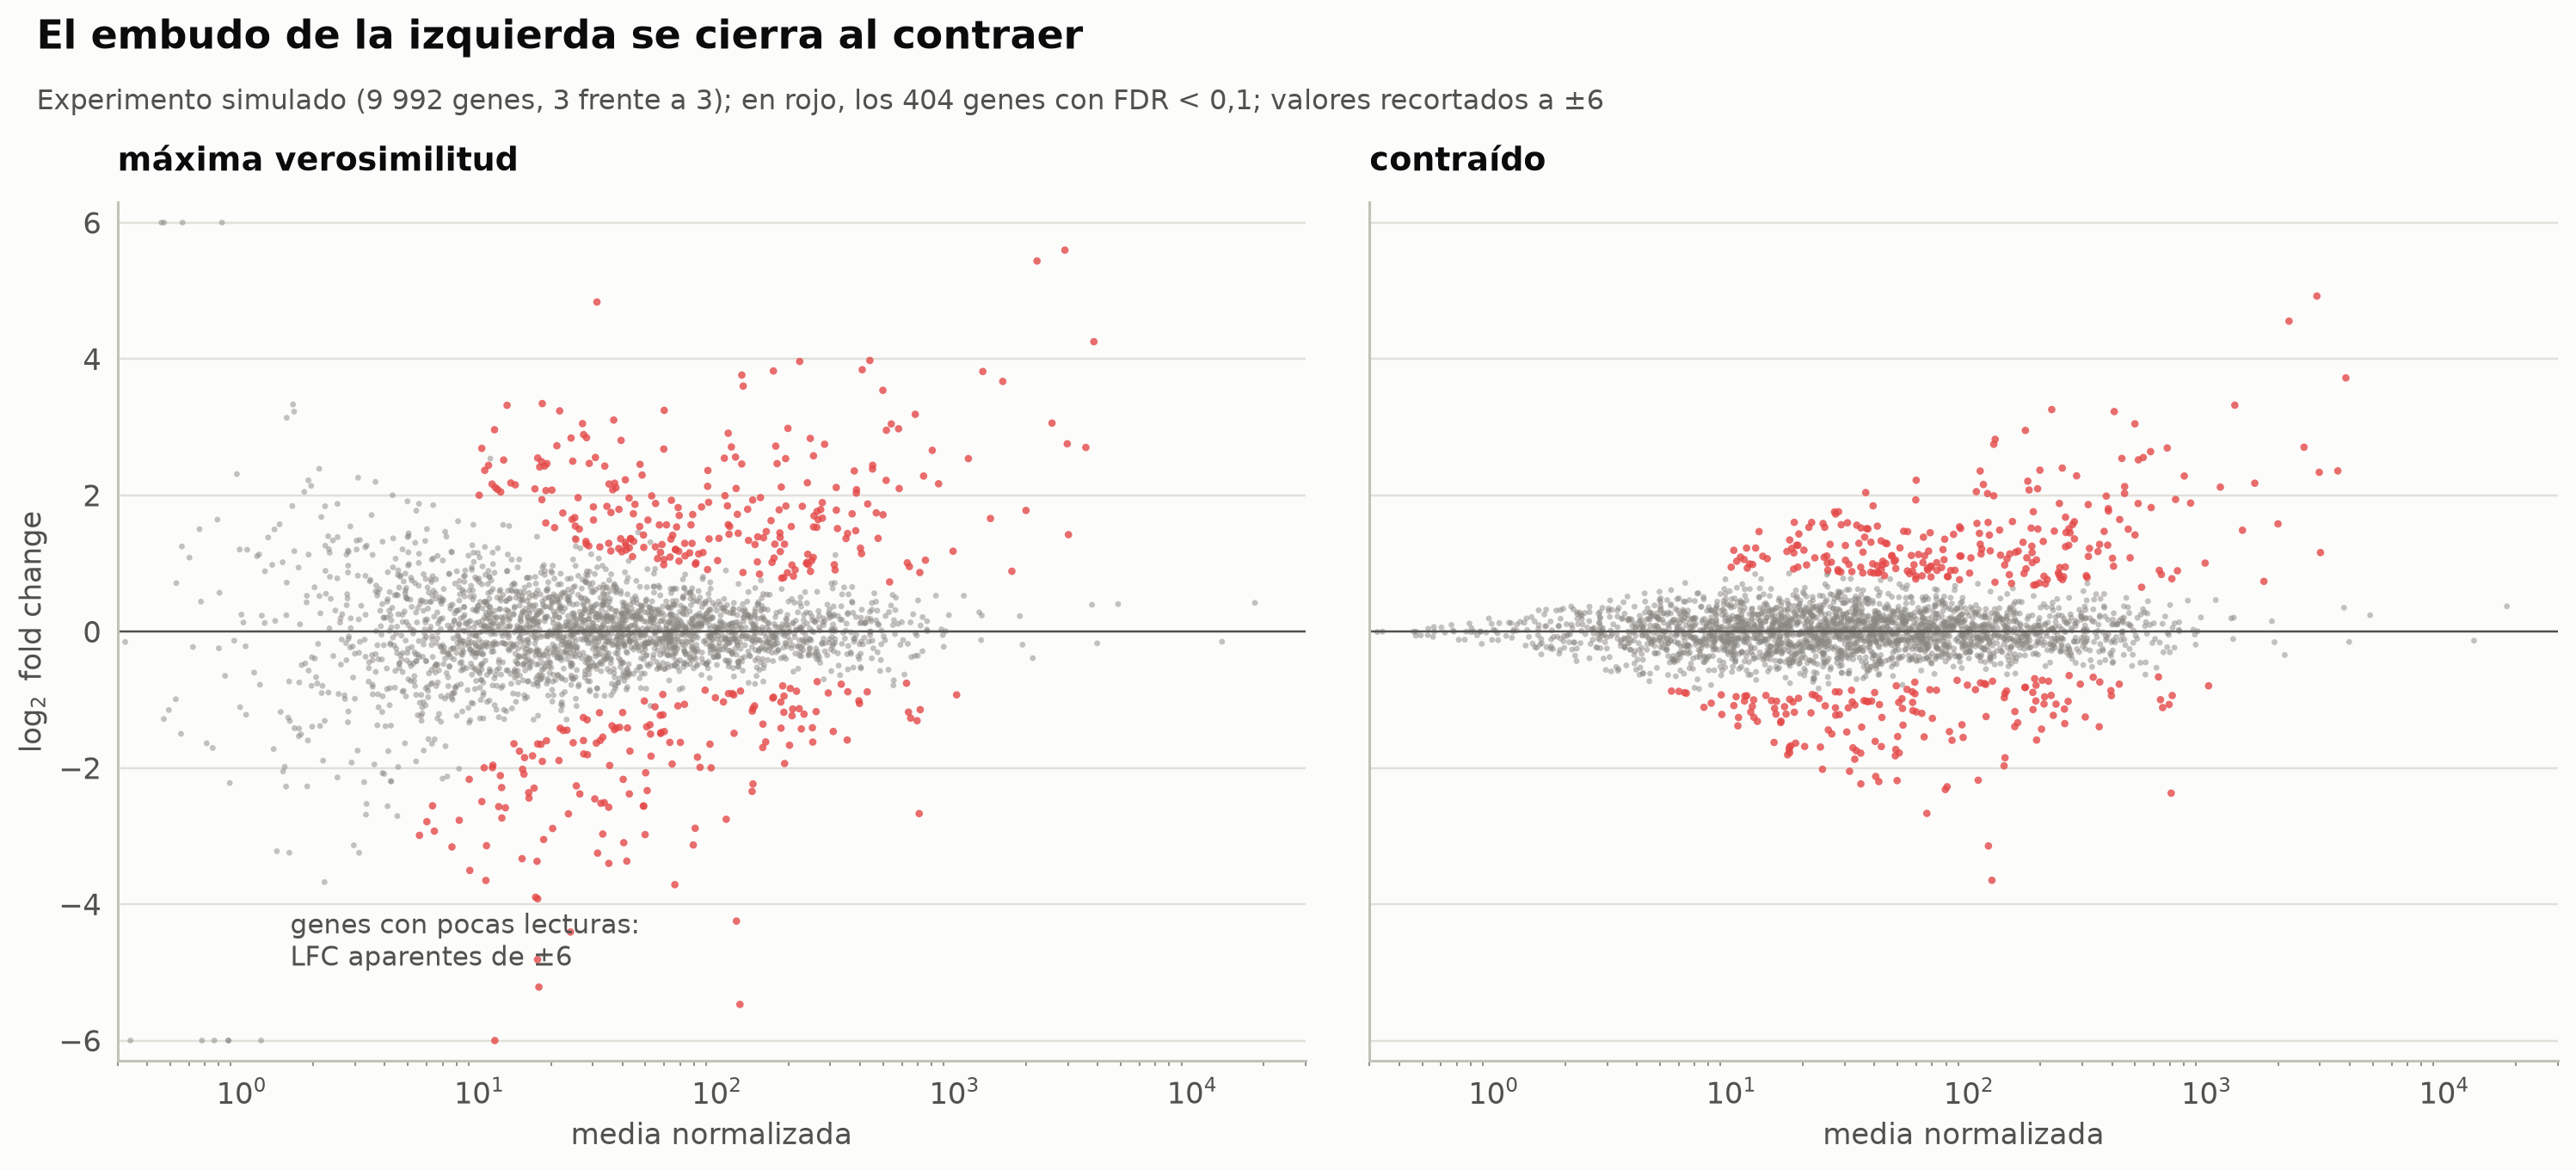

In [9]:
# Gráficos MA del experimento simulado: máxima verosimilitud frente a contraído (figura del libro)
print(f"genes significativos con FDR < 0,1: {sig.sum()}   (libro: 404)")
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), sharey=True, gridspec_kw={"wspace": 0.05})
for ax, v, lab in zip(axes, [lfc_hat, lfc_shr], ["máxima verosimilitud", "contraído"]):
    ax.scatter(base[sub_ns], np.clip(v[sub_ns], -6, 6), s=5, color=ec.MUTED, alpha=0.5, edgecolors="none")
    ax.scatter(base[sig], np.clip(v[sig], -6, 6), s=8, color=ec.RED, alpha=0.8, edgecolors="none")
    ax.axhline(0, color=ec.INK_2, lw=0.8)
    ax.set_xscale("log"); ax.set_xlim(0.3, 3e4); ax.set_ylim(-6.3, 6.3)
    ax.set_xlabel("media normalizada")
    ax.set_title(lab, loc="left", fontsize=12.5)
axes[0].set_ylabel("$\\log_2$ fold change")
axes[0].annotate("genes con pocas lecturas:\nLFC aparentes de ±6", (0.9, -5.9), xytext=(1.6, -4.9), fontsize=10,
                 color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED))
ec.fig_title(fig, "El embudo de la izquierda se cierra al contraer",
             f"Experimento simulado (9 992 genes, 3 frente a 3); en rojo, los {sig.sum()} genes con FDR < 0,1; valores recortados a ±6")
plt.show()

> 🔎 **Qué observamos.** A la izquierda, los LFC de máxima verosimilitud forman un **embudo** abierto hacia las medias
> bajas, donde los genes con pocas lecturas alcanzan cambios aparentes de $\pm6$. A la derecha, tras la contracción, el
> embudo se cierra: los genes poco expresados se acercan a cero, y los significativos, que tienen errores estándar
> pequeños, apenas se mueven. **Ordenar genes por LFC sólo tiene sentido en el panel derecho.**

sobreexpresados (FDR<0,1 y LFC>1) = 224; reprimidos = 141   (libro: 224 y 141)
umbral BH: p = 0.0040  →  −log10 p = 2.39   (libro: 2,39)


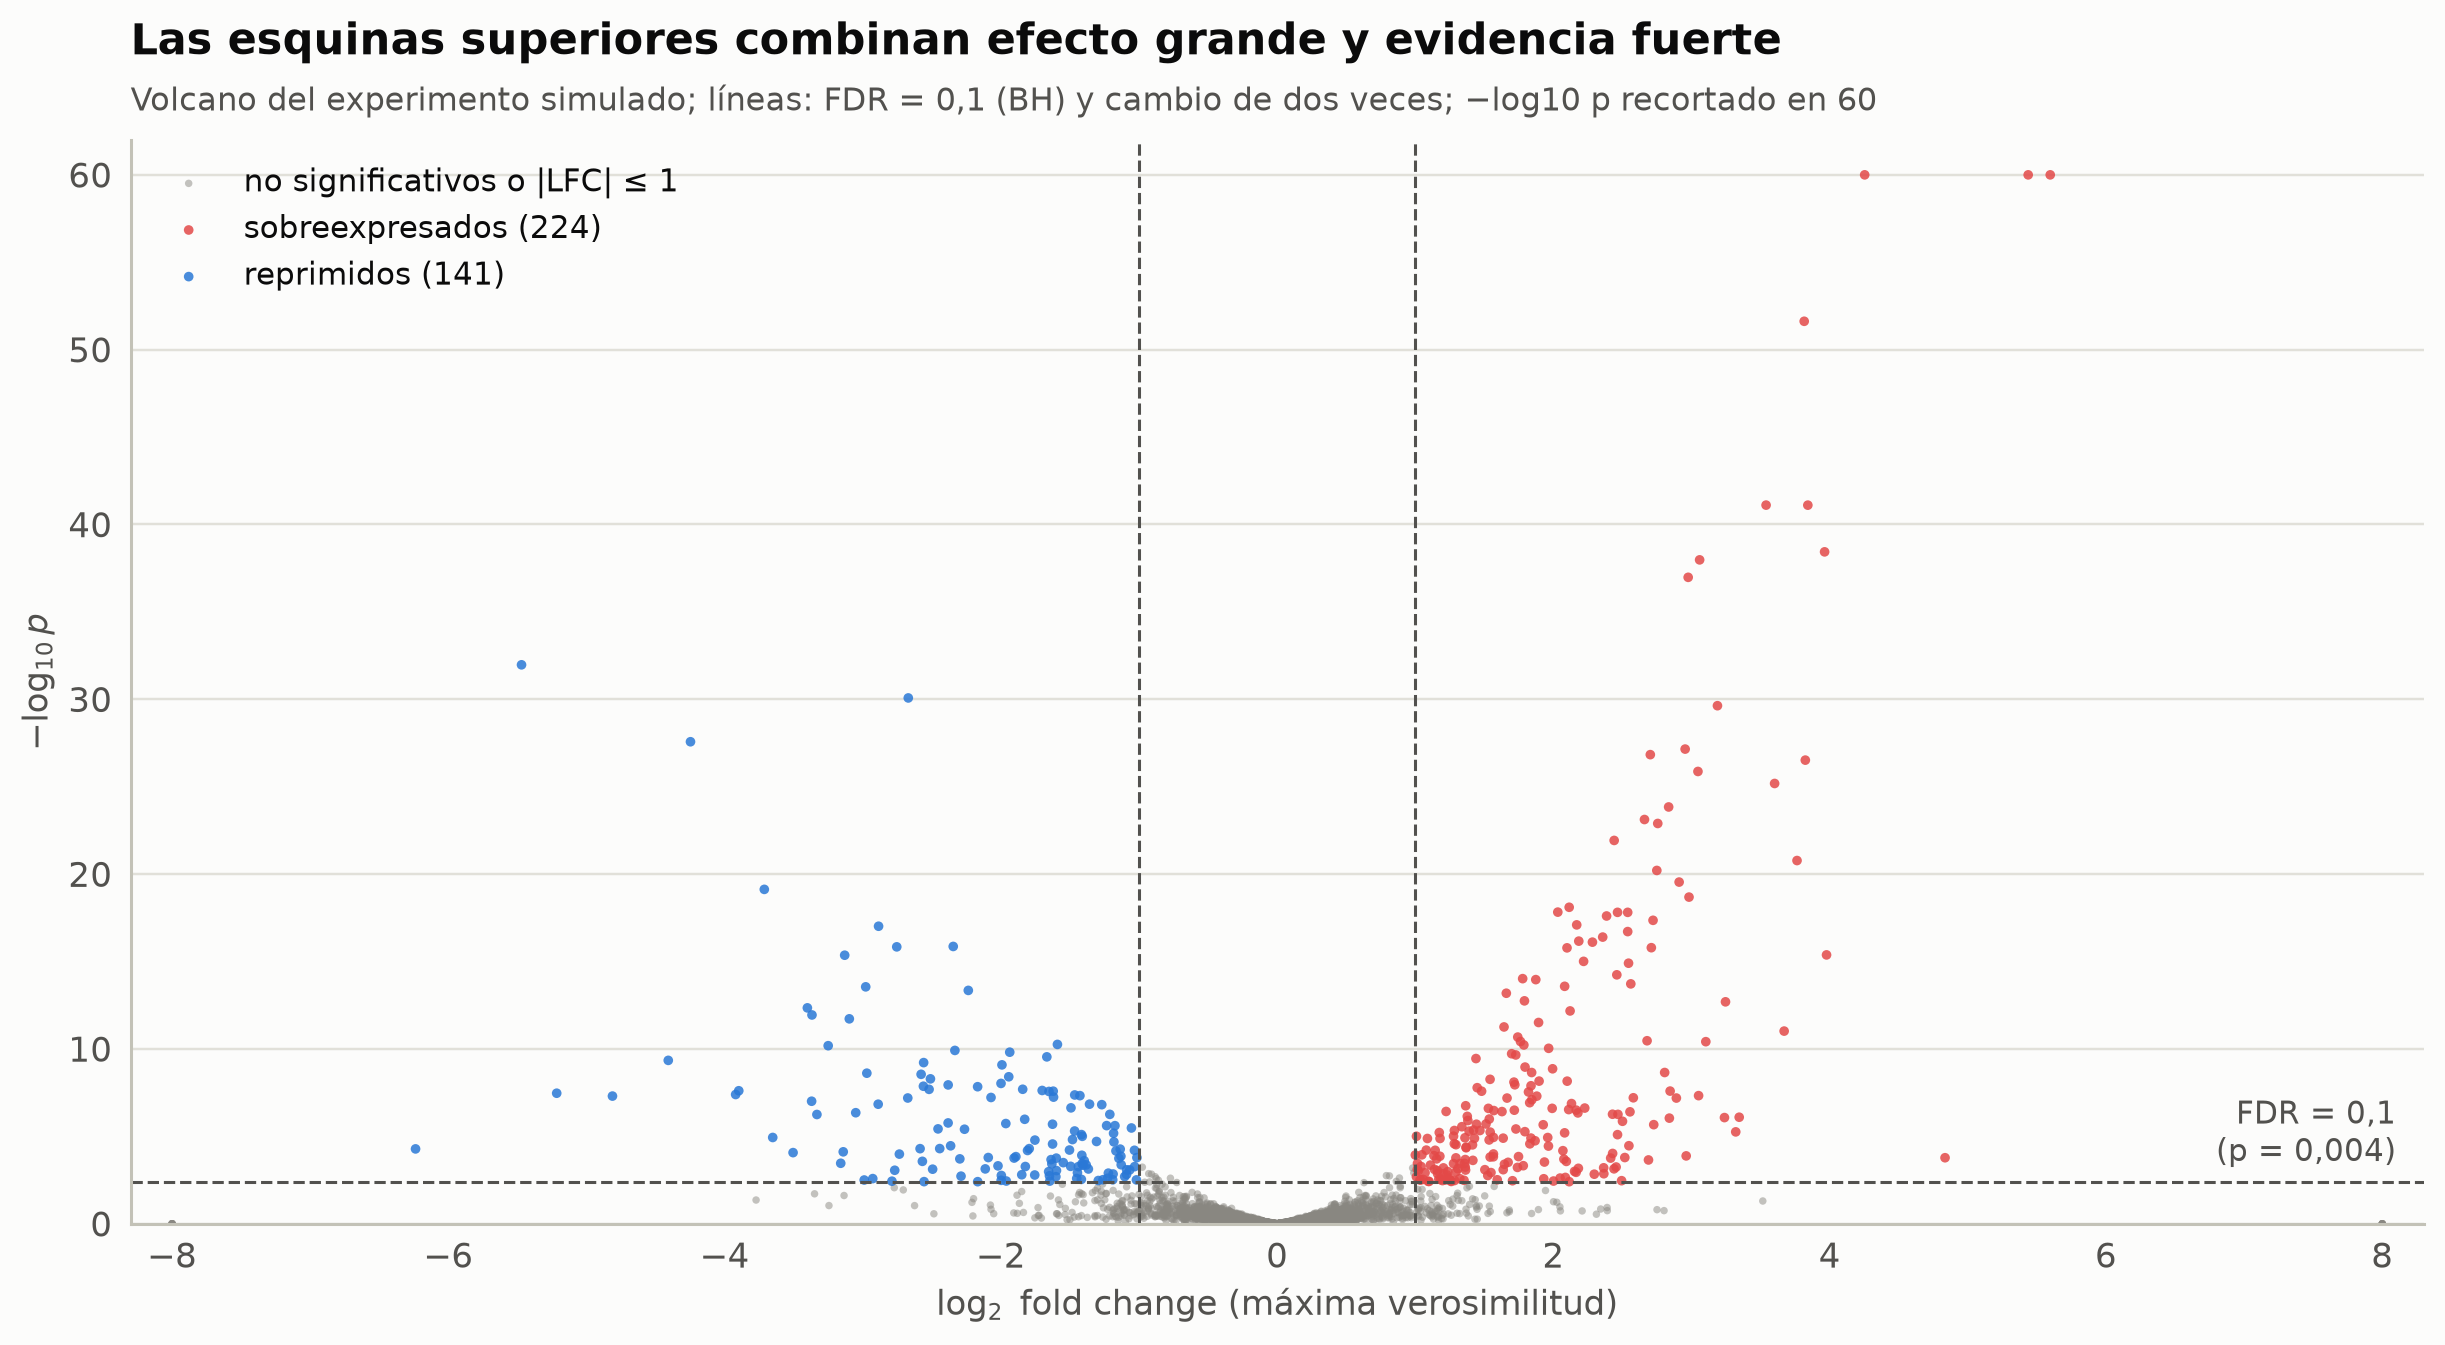

In [10]:
# Gráfico volcano del experimento simulado (figura del libro)
p_star = 0.1 * sig.sum() / G                           # umbral efectivo de BH (sección 6)
cat_up = sig & (lfc_hat > 1); cat_dn = sig & (lfc_hat < -1); cat_ns = ~(cat_up | cat_dn)
lp = -np.log10(np.maximum(pval, 1e-60))
print(f"sobreexpresados (FDR<0,1 y LFC>1) = {cat_up.sum()}; reprimidos = {cat_dn.sum()}   (libro: 224 y 141)")
print(f"umbral BH: p = {p_star:.4f}  →  −log10 p = {-np.log10(p_star):.2f}   (libro: 2,39)")
sub_v = np.random.default_rng(4).choice(np.where(cat_ns)[0], 2500, replace=False)
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(np.clip(lfc_hat[sub_v], -8, 8), np.minimum(lp[sub_v], 60), s=6, color=ec.MUTED, alpha=0.5,
           edgecolors="none", label="no significativos o |LFC| ≤ 1")
ax.scatter(np.clip(lfc_hat[cat_up], -8, 8), np.minimum(lp[cat_up], 60), s=10, color=ec.RED, alpha=0.85,
           edgecolors="none", label=f"sobreexpresados ({cat_up.sum()})")
ax.scatter(np.clip(lfc_hat[cat_dn], -8, 8), np.minimum(lp[cat_dn], 60), s=10, color=ec.BLUE, alpha=0.85,
           edgecolors="none", label=f"reprimidos ({cat_dn.sum()})")
ax.axhline(-np.log10(p_star), color=ec.INK_2, ls="--", lw=1)
for x in (-1, 1): ax.axvline(x, color=ec.INK_2, ls="--", lw=1)
ax.text(8.1, -np.log10(p_star) + 0.6, "FDR = 0,1\n(p = 0,004)", ha="right", va="bottom", fontsize=10, color=ec.INK_2)
ax.set_xlim(-8.3, 8.3); ax.set_ylim(0, 62)
ax.set_xlabel("$\\log_2$ fold change (máxima verosimilitud)"); ax.set_ylabel("$-\\log_{10} p$")
ax.legend(loc="upper left", frameon=False)
ec.title(ax, "Las esquinas superiores combinan efecto grande y evidencia fuerte",
         "Volcano del experimento simulado; líneas: FDR = 0,1 (BH) y cambio de dos veces; −log10 p recortado en 60")
plt.show()

> 🔎 **Qué observamos.** La línea horizontal marca el valor $p$ que corresponde a FDR $=0{,}1$ según Benjamini-Hochberg
> ($p=0{,}004$, es decir $-\log_{10}p=2{,}39$), y las verticales un cambio de dos veces. Hay 224 genes sobreexpresados
> y 141 reprimidos que superan ambos criterios. Fíjese en los puntos grises con $|\mathrm{LFC}|>3$ y $p$ modesto, en la
> base de las alas: son **genes poco expresados**, con efecto aparente grande y evidencia débil, los mismos que el
> gráfico MA mostraba en la boca del embudo.

> ✅ **Compruebe su comprensión.** Un gen aparece en el *volcano* con $\mathrm{LFC}=0{,}4$ y $-\log_{10}p=45$. ¿Es un
> gen poco o muy expresado? ¿Le parece un buen candidato para validar por PCR?

## 6. Diez mil pruebas a la vez

### 6.1 La tabla que lo organiza todo

En un experimento de RNA-seq contrastamos $m\approx10\,000$–$20\,000$ hipótesis. Si usamos el umbral $p<0{,}05$ para
cada una, esperamos que un 5 % de los genes **sin** cambio resulten «significativos»: cientos de falsos positivos, las
excavaciones en balde de la sección 1. Clasifiquemos los resultados:

| | declarados no significativos | declarados significativos | total |
|---|:-:|:-:|:-:|
| $H_0$ verdadera | $U$ | $V$ | $m_0$ |
| $H_0$ falsa | $T$ | $S$ | $m-m_0$ |
| total | $m-R$ | $R$ | $m$ |

En un experimento real **sólo $m$ y $R$ son observables**; en nuestra simulación conocemos todas las casillas.

### 6.2 FWER y Bonferroni

La corrección clásica controla la **tasa de error por familia**, $\mathrm{FWER}=\Pr(V\ge1)$: la probabilidad de cometer
*al menos un* falso positivo. El método de Bonferroni lo consigue declarando significativos los genes con
$p_i\le\alpha/m$. Es una exigencia apropiada cuando un único error es costoso (un ensayo clínico, un diagnóstico), pero en
genómica es excesiva: con $m=10\,000$, un gen necesita $p<10^{-5}$ para ser significativo al nivel 0,1.

### 6.3 La tasa de falsos descubrimientos

$$
\mathrm{FDR}=\mathbb{E}\!\left[\frac{V}{\max(R,1)}\right].
$$

| Símbolo | Significado |
|---|---|
| $V$ | Número de hipótesis nulas verdaderas rechazadas (falsos descubrimientos) |
| $R$ | Número total de rechazos (descubrimientos) |
| $m_0$ | Número de hipótesis nulas verdaderas, desconocido |

Benjamini y Hochberg (1995) propusieron controlar esta cantidad, mucho más adecuada para un **cribado**: lo que importa
no es evitar todo error, sino que la lista de candidatos que pasará a validación sea mayoritariamente correcta. El
$\max(R,1)$ sólo evita dividir por cero cuando no hay descubrimientos. Observe que la FDR es una **esperanza**: en un
experimento concreto la proporción observada, $V/R$ (la FDP), puede quedar algo por encima o por debajo.

### 6.4 El procedimiento de Benjamini-Hochberg

Ordene los valores $p$, $p_{(1)}\le p_{(2)}\le\cdots\le p_{(m)}$, y sea

$$
k^{*}=\max\left\{\,i:\ p_{(i)}\le\frac{i}{m}\,\alpha\,\right\}.
$$

Si se rechazan las hipótesis $H_{(1)},\dots,H_{(k^*)}$ y las pruebas son independientes, entonces
$\mathrm{FDR}\le\frac{m_0}{m}\alpha\le\alpha$.

| Símbolo | Significado |
|---|---|
| $p_{(i)}$ | El $i$-ésimo valor $p$ más pequeño |
| $\alpha$ | Nivel deseado de FDR (en RNA-seq es habitual 0,05 o 0,1) |
| $k^*$ | Número de descubrimientos |

El umbral **crece linealmente con el rango**: el gen más significativo debe superar la exigencia de Bonferroni,
$\alpha/m$, pero el décimo sólo necesita $10\alpha/m$. Si hay muchos genes con señal, el procedimiento se vuelve
permisivo; si no hay ninguno, se comporta casi como Bonferroni. La demostración original supone independencia;
resultados posteriores la extienden a formas de dependencia positiva que cubren razonablemente la correlación entre
genes coexpresados. El **valor $p$ ajustado** de BH (la columna `padj` de DESeq2) es el menor $\alpha$ al que el gen
sería declarado significativo.

**Resuelto a mano.** Diez genes con $p=0{,}0002;\ 0{,}0011;\ 0{,}0030;\ 0{,}0045;\ 0{,}0120;\ 0{,}0150;\ 0{,}0300;\
0{,}2000;\ 0{,}5000;\ 0{,}9000$ y $\alpha=0{,}05$. Los umbrales $i\alpha/m$ son $0{,}005;\ 0{,}010;\ 0{,}015;\ \dots$

| $i$ | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 |
|---|---|---|---|---|---|---|---|---|
| $p_{(i)}$ | 0,0002 | 0,0011 | 0,0030 | 0,0045 | 0,0120 | 0,0150 | 0,0300 | 0,2000 |
| $i\alpha/m$ | 0,005 | 0,010 | 0,015 | 0,020 | 0,025 | 0,030 | 0,035 | 0,040 |
| ¿$p_{(i)}\le i\alpha/m$? | sí | sí | sí | sí | sí | sí | sí | no |

El último «sí» está en $i=7$: $k^*=7$. Bonferroni ($p\le0{,}005$) sólo habría rechazado 4. El `padj` del gen 5 es
$\min\big(0{,}0120\cdot10/5,\ 0{,}0150\cdot10/6,\ \dots\big)=0{,}024$.

In [11]:
# Comprobación del ejemplo a mano con la función bh() del libro
p10 = np.array([0.0002, 0.0011, 0.0030, 0.0045, 0.0120, 0.0150, 0.0300, 0.2000, 0.5000, 0.9000])
print("padj BH:", np.round(bh(p10), 4))
print("rechazos BH (α = 0,05):", np.sum(bh(p10) <= 0.05), "· Bonferroni:", np.sum(p10 <= 0.05 / 10))

# La tabla U, V, T, S del experimento simulado para tres criterios
def confusion(reject):
    V = np.sum(reject & ~de); S = np.sum(reject & de)
    return dict(R=int(reject.sum()), V=int(V), S=int(S), FDP=V / max(reject.sum(), 1), potencia=S / de.sum())
crit = {"p < 0,05 sin corregir": pval < 0.05,
        "Bonferroni, FWER 0,1": pval < 0.1 / G,
        "Benjamini-Hochberg, FDR 0,1": bh(pval) < 0.1}
tab = pd.DataFrame({k: confusion(v) for k, v in crit.items()}).T
tab["FDP"] = tab["FDP"].astype(float).round(3); tab["potencia"] = tab["potencia"].astype(float).round(3)
display(tab)
rej = crit["Benjamini-Hochberg, FDR 0,1"]
m0 = int((~de).sum())
print(f"Tabla completa para BH: U = {m0 - np.sum(rej & ~de)}, V = {np.sum(rej & ~de)}, m0 = {m0}; "
      f"T = {np.sum(~rej & de)}, S = {np.sum(rej & de)}, m − m0 = {de.sum()}; R = {rej.sum()}, m = {G}")

padj BH: [0.002  0.0055 0.01   0.0112 0.024  0.025  0.0429 0.25   0.5556 0.9   ]
rechazos BH (α = 0,05): 7 · Bonferroni: 4


,R,V,S,FDP,potencia
"p < 0,05 sin corregir",915.0,373.0,542.0,0.408,0.573
"Bonferroni, FWER 0,1",185.0,2.0,183.0,0.011,0.193
"Benjamini-Hochberg, FDR 0,1",404.0,33.0,371.0,0.082,0.392


Tabla completa para BH: U = 9013, V = 33, m0 = 9046; T = 575, S = 371, m − m0 = 946; R = 404, m = 9992


> 🔎 **Qué observamos: el ejemplo «Tres criterios sobre el mismo experimento» del libro.** Con 9 992 genes y 946 cambios
> reales:
>
> * $p<0{,}05$ sin corrección: **915** genes, de los que **373 (41 %)** no tienen cambio real.
> * Bonferroni con FWER $0{,}1$ ($p<10^{-5}$): **185** genes, sólo **2** falsos, pero se detecta menos de una quinta
>   parte de los cambios.
> * Benjamini-Hochberg con FDR $0{,}1$: **404** genes, **33** falsos. La proporción observada de falsos descubrimientos,
>   $0{,}082$, está por debajo del nivel nominal, y la potencia es del **39 %**.
>
> El umbral efectivo de BH resulta ser $p\le0{,}0040$, cuatrocientas veces más permisivo que Bonferroni y doce veces
> más exigente que el umbral ingenuo. La potencia modesta no es un fallo del método: con tres réplicas, muchos de los
> cambios reales son pequeños o afectan a genes con pocas lecturas. (¿Acertó su predicción de la sección 2?)

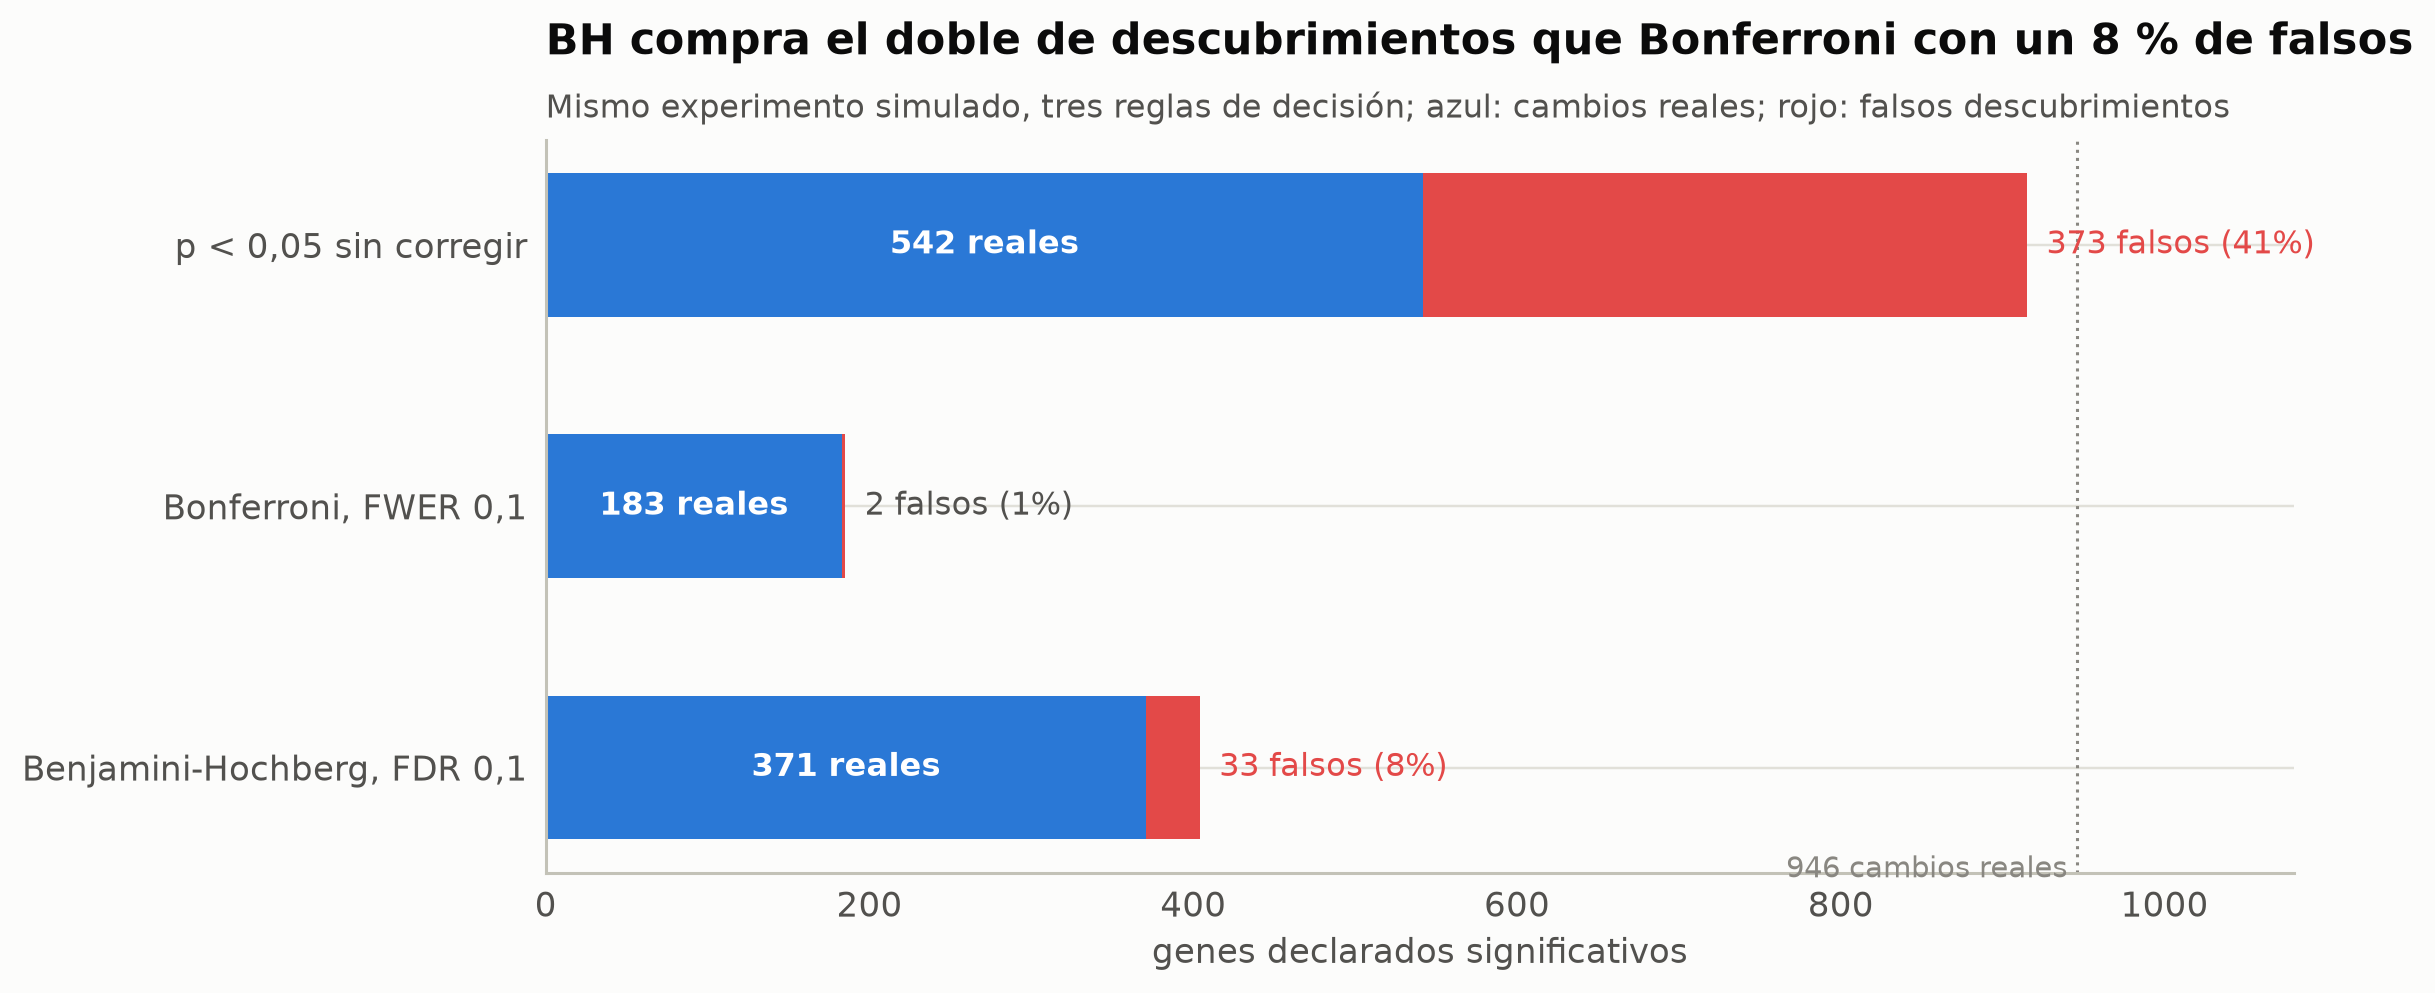

In [12]:
# Figura: los tres criterios, descubrimientos verdaderos y falsos
fig, ax = plt.subplots(figsize=(10.5, 4.4))
names = list(crit.keys())
S_ = tab["S"].astype(int).values; V_ = tab["V"].astype(int).values
y = np.arange(3)[::-1]
ax.barh(y, S_, color=ec.BLUE, height=0.55)
ax.barh(y, V_, left=S_, color=ec.RED, height=0.55)
for yi, s_, v_ in zip(y, S_, V_):
    ax.text(s_ / 2, yi, f"{s_} reales", ha="center", va="center", color="white", fontsize=10.5, fontweight="bold")
    ax.text(s_ + v_ + 12, yi, f"{v_} falsos ({v_ / (s_ + v_):.0%})".replace(".", ","), va="center", fontsize=10.5,
            color=ec.RED if v_ > 20 else ec.INK_2)
ax.set_yticks(y, names); ax.set_xlim(0, 1080)
ax.axvline(de.sum(), color=ec.MUTED, ls=":", lw=1)
ax.text(de.sum() - 6, -0.42, "946 cambios reales", fontsize=9.5, color=ec.MUTED, ha="right")
ax.set_xlabel("genes declarados significativos")
ec.title(ax, "BH compra el doble de descubrimientos que Bonferroni con un 8 % de falsos",
         "Mismo experimento simulado, tres reglas de decisión; azul: cambios reales; rojo: falsos descubrimientos")
plt.show()

### 6.5 El procedimiento, visto como una escalera

La figura interactiva siguiente reproduce la del libro: los 1 200 valores $p$ más pequeños, ordenados, frente a la
recta $i\alpha/m$. **Pase el cursor** por los puntos cercanos al cruce para ver el rango, el valor $p$, el umbral de
ese rango y si el gen tiene cambio real.

> 🤔 **Antes de ejecutar, prediga.** ¿Puede un gen con $p_{(i)}$ **por encima** de la recta ser declarado
> significativo?

k* = 404; p_(k*) = 4.008e-03; umbral k*α/m = 4.043e-03   (libro: 404; 4,008e-03; 4,043e-03)
rangos ≤ k* con p_(i) por encima de la recta (rechazados igualmente): 0


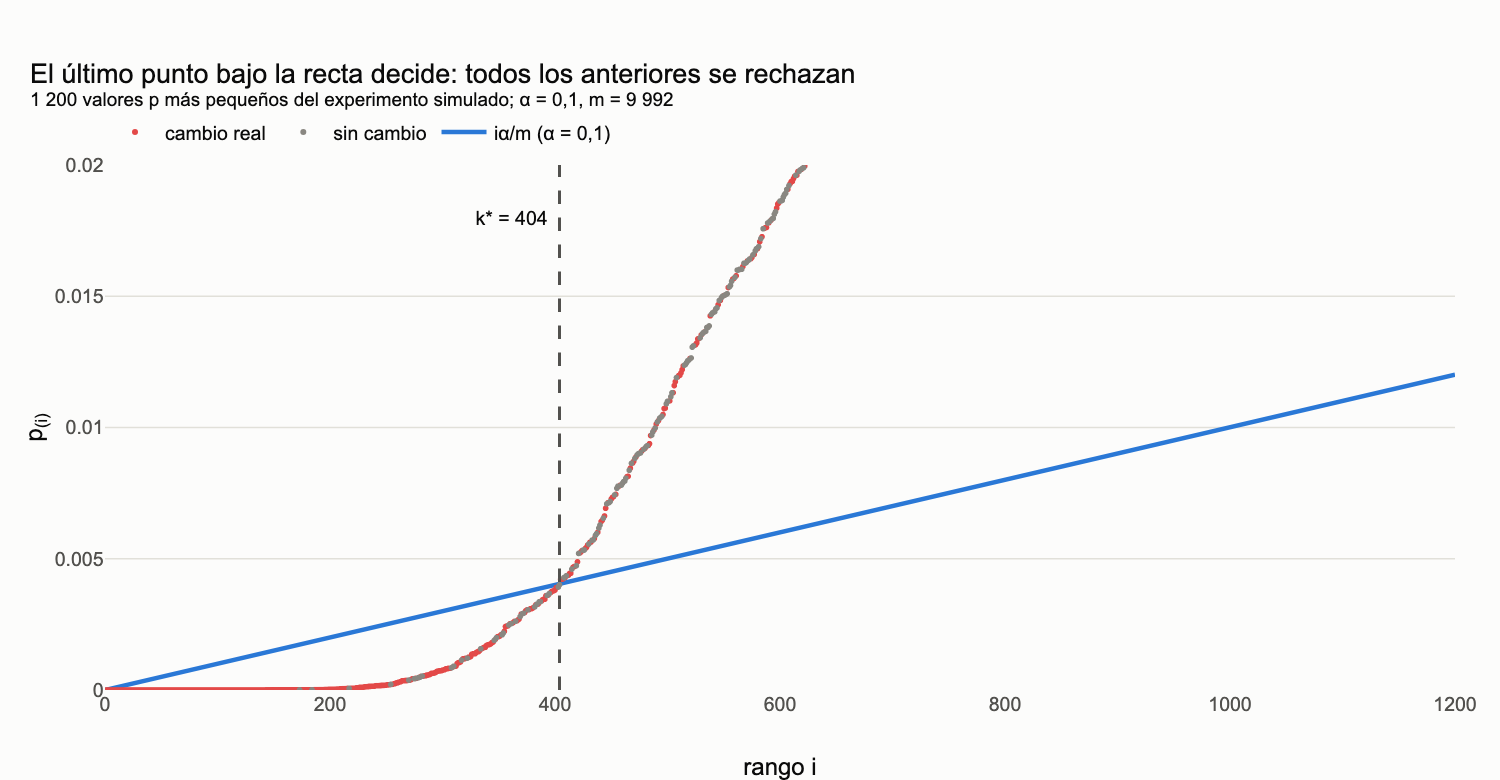

In [13]:
# 🔍 Interactivo: la escalera de BH en el experimento simulado
o = np.argsort(pval); ps = pval[o][:1200]; ii = np.arange(1, 1201); dd = de[o][:1200]
kbh = int(np.max(np.where(pval[o] <= 0.1 * np.arange(1, G + 1) / G)[0]) + 1)
print(f"k* = {kbh}; p_(k*) = {pval[o][kbh - 1]:.3e}; umbral k*α/m = {0.1 * kbh / G:.3e}   (libro: 404; 4,008e-03; 4,043e-03)")
above = np.where(ps[:kbh] > 0.1 * ii[:kbh] / G)[0] + 1
print(f"rangos ≤ k* con p_(i) por encima de la recta (rechazados igualmente): {len(above)}")
fig = go.Figure()
for mask, name, color in [(dd, "cambio real", ec.RED), (~dd, "sin cambio", ec.MUTED)]:
    fig.add_trace(go.Scattergl(
        x=ii[mask], y=ps[mask], mode="markers", name=name, marker=dict(size=4, color=color),
        customdata=np.column_stack([0.1 * ii[mask] / G, np.where(ii[mask] <= kbh, "sí", "no")]),
        hovertemplate="rango i = %{x}<br>p<sub>(i)</sub> = %{y:.2e}<br>iα/m = %{customdata[0]:.2e}"
                      "<br>¿rechazado por BH? %{customdata[1]}<extra>" + name + "</extra>"))
fig.add_trace(go.Scatter(x=[0, 1200], y=[0, 0.1 * 1200 / G], mode="lines", name="iα/m (α = 0,1)",
                         line=dict(color=ec.BLUE, width=3), hoverinfo="skip"))
fig.add_vline(x=kbh, line_dash="dash", line_color=ec.INK_2)
fig.add_annotation(x=kbh, y=0.018, text=f"k* = {kbh}", showarrow=False, xanchor="right", xshift=-6)
fig.update_layout(title="El último punto bajo la recta decide: todos los anteriores se rechazan"
                        "<br><sup>1 200 valores p más pequeños del experimento simulado; α = 0,1, m = 9 992</sup>",
                  xaxis_title="rango i", yaxis_title="p<sub>(i)</sub>", yaxis_range=[0, 0.02], xaxis_range=[0, 1200],
                  height=520, margin=dict(t=110, l=70, r=30, b=60),
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.show()

> 🔎 **Qué observamos.** El último punto bajo la recta está en $i=404$ ($p_{(404)}=0{,}0040$), y **todos** los genes
> hasta ese rango se declaran significativos, **aunque alguno anterior quedara por encima de la recta**: por eso el
> procedimiento se llama «de subida» (*step-up*). En esta simulación no ocurre (la celda lo cuenta: 0 casos), pero puede
> ocurrir en otros datos: lo verá en el Ejercicio 1. Los puntos grises entre los primeros 404 son los 33 falsos
> descubrimientos: están mezclados con los rojos, no concentrados al final, porque un gen nulo puede tener por azar un
> valor $p$ diminuto.

> ✅ **Compruebe su comprensión.** Si duplicamos el número de genes nulos (añadimos 10 000 genes sin cambio, con valores
> $p$ uniformes), ¿qué le pasa a la pendiente de la recta y al número de descubrimientos?

## 7. El histograma de valores $p$ y los $q$-valores

### 7.1 Una mezcla de dos poblaciones

Bajo la hipótesis nula, un valor $p$ continuo es **uniforme** en $[0,1]$: tiene la misma probabilidad de caer en
$[0;\ 0{,}05]$ que en $[0{,}50;\ 0{,}55]$. El histograma de los $m$ valores $p$ de un experimento es por tanto una
mezcla: **una base plana** de altura proporcional a $m_0$, más **un pico cerca de cero** producido por los genes con
señal. Es la primera figura que conviene mirar después de un análisis: antes que la lista de genes.

### 7.2 Estimar la proporción de nulas

Storey y Tibshirani (2003) usaron esa estructura para estimar $\pi_0=m_0/m$: por encima de un umbral $\lambda$ casi
todos los valores $p$ vienen de nulas, que se reparten uniformemente en un intervalo de longitud $1-\lambda$. Así

$$
\hat\pi_0(\lambda)=\frac{\#\{p_i>\lambda\}}{m\,(1-\lambda)}.
$$

| Símbolo | Significado |
|---|---|
| $\pi_0$ | Proporción de genes sin cambio real |
| $\lambda$ | Umbral a partir del cual se supone que sólo hay nulas (p. ej., 0,5) |

**Resuelto a mano.** Si de $m=10\,000$ genes hay $4\,800$ con $p>0{,}5$, entonces
$\hat\pi_0(0{,}5)=4\,800/(10\,000\times0{,}5)=0{,}96$: estimamos que el 96 % de los genes no cambia.

Como la base del histograma contiene también algunos valores $p$ de genes con cambios pequeños, $\hat\pi_0$ tiende a
**sobreestimar** $\pi_0$, un sesgo conservador. Con esa estimación se define el **$q$-valor** de un gen como la menor FDR
a la que puede ser declarado significativo,

$$
q(p_i)=\min_{t\ge p_i}\ \frac{\hat\pi_0\,m\,t}{\#\{p_j\le t\}},
$$

que es el valor $p$ ajustado de BH multiplicado por $\hat\pi_0$. Cuando $\pi_0$ es claramente menor que 1, los
$q$-valores ganan potencia; en RNA-seq, con $\pi_0$ cercano a 1, la diferencia suele ser pequeña.

π̂0(0,5) = 0.989   verdad = 0.905   (libro: 0,989 y 0,905)
tras quitar genes con media < 5: π̂0 = 0.971; verdad = 0.907; m = 8900   (libro: 0,971; 0,907; 8 900)
genes con q < 0,1: 404   (libro: 404)
fracción de p > 0,95 entre los genes con media < 2: 0.223   (libro: 0,223)


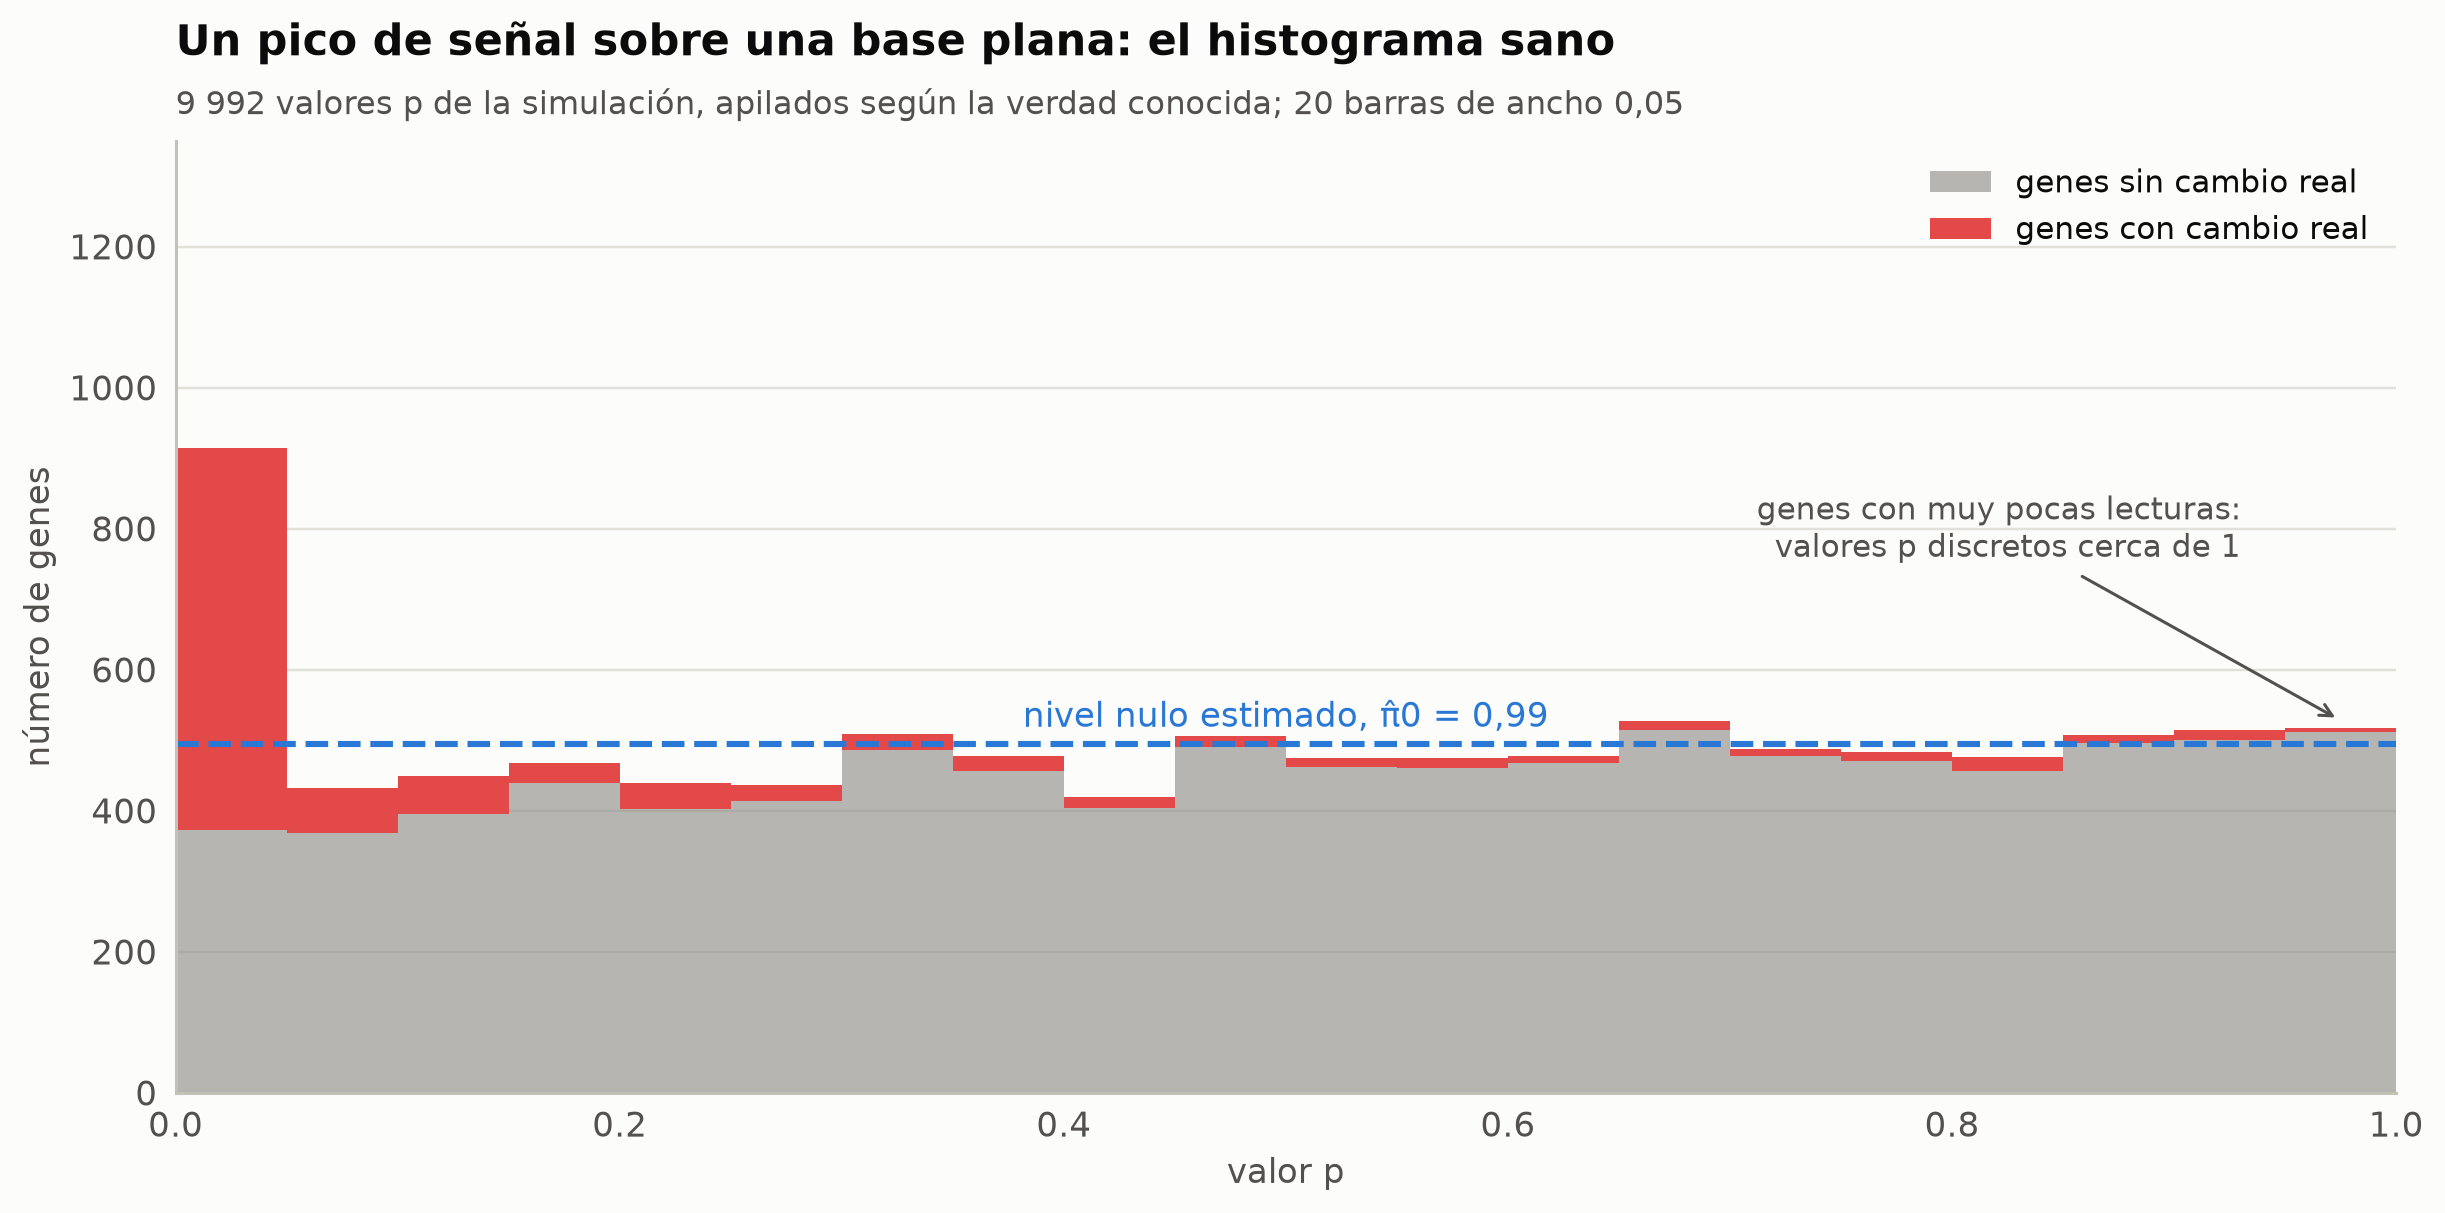

In [14]:
lam_s = 0.5
pi0 = np.mean(pval > lam_s) / (1 - lam_s)
qv = np.minimum(1, pi0 * bh(pval))
ff = base >= 5
pi0f = np.mean(pval[ff] > lam_s) / (1 - lam_s)
print(f"π̂0(0,5) = {pi0:.3f}   verdad = {np.mean(~de):.3f}   (libro: 0,989 y 0,905)")
print(f"tras quitar genes con media < 5: π̂0 = {pi0f:.3f}; verdad = {np.mean(~de[ff]):.3f}; m = {ff.sum()}   (libro: 0,971; 0,907; 8 900)")
print(f"genes con q < 0,1: {np.sum(qv < 0.1)}   (libro: 404)")
print(f"fracción de p > 0,95 entre los genes con media < 2: {np.mean(pval[base < 2] > 0.95):.3f}   (libro: 0,223)")

edges = np.linspace(0, 1, 21)
h0, _ = np.histogram(pval[~de], edges); h1, _ = np.histogram(pval[de], edges)
fig, ax = plt.subplots(figsize=(11, 5.4))
ax.bar(edges[:-1], h0, width=0.05, align="edge", color=ec.MUTED, alpha=0.6, edgecolor="white", label="genes sin cambio real")
ax.bar(edges[:-1], h1, width=0.05, bottom=h0, align="edge", color=ec.RED, edgecolor="white", label="genes con cambio real")
ax.axhline(pi0 * G / 20, color=ec.BLUE, ls="--", lw=2)
ax.text(0.5, pi0 * G / 20 + 25, f"nivel nulo estimado, π̂0 = {fmt(pi0)}", ha="center", color=ec.BLUE, fontsize=11)
ax.annotate("genes con muy pocas lecturas:\nvalores p discretos cerca de 1", (0.975, h0[-1] + h1[-1] + 10),
            xytext=(0.93, 760), ha="right", fontsize=10, color=ec.INK_2,
            arrowprops=dict(arrowstyle="->", color=ec.INK_2, lw=1))
ax.set_xlim(0, 1); ax.set_ylim(0, 1350)
ax.set_xlabel("valor p"); ax.set_ylabel("número de genes")
ax.legend(loc="upper right", frameon=False)
ec.title(ax, "Un pico de señal sobre una base plana: el histograma sano",
         "9 992 valores p de la simulación, apilados según la verdad conocida; 20 barras de ancho 0,05")
plt.show()

> 🔎 **Qué observamos.** El pico de la barra izquierda contiene la mayoría de los cambios reales; el resto del histograma
> es aproximadamente plano, como corresponde a nulas uniformes. La línea discontinua es la altura de la base según
> $\hat\pi_0(0{,}5)=0{,}99$, **mayor que el valor verdadero ($0{,}905$)** porque algunos cambios pequeños tienen valores
> $p$ grandes (hay rojo repartido por toda la base). La barra de la derecha sobresale ligeramente: los genes con muy pocas lecturas
> producen valores $p$ discretos y acumulados cerca de 1 (el 22 % de los genes con media $<2$ tiene $p>0{,}95$).
>
> **Cómo leer otros histogramas.** Una forma de **U**, o una base que **crece hacia la derecha**, delata un modelo mal
> especificado: dispersión sobreestimada o lotes no incluidos en el diseño. Un histograma **sin pico** y plano dice que
> no hay señal detectable (o que no hay potencia). Un pico enorme en todas partes, con la base casi vacía, sugiere
> dispersión subestimada. Lo comprobaremos con datos reales en la sección 10.

> ✅ **Compruebe su comprensión.** ¿Por qué los $q$-valores dan aquí exactamente los mismos 404 genes que BH, si
> $q=\hat\pi_0\cdot p_{\mathrm{adj}}$ y $\hat\pi_0<1$?

## 8. Filtrado independiente

### 8.1 La idea

Los genes con muy pocas lecturas **no tienen ninguna posibilidad** de alcanzar significación (con tres conteos repartidos
en seis muestras no hay nada que contrastar), pero cuentan en $m$ y encarecen la corrección para todos los demás: en la
escalera de BH, cada gen inútil hace más plana la recta $i\alpha/m$. ¿Podemos eliminarlos **antes** de aplicar BH?

Bourgon, Gentleman y Huber (2010) mostraron que sí, con una condición precisa: el estadístico de filtrado debe ser
**independiente del estadístico de prueba bajo la hipótesis nula**. La media de los conteos normalizados de todas las
muestras, **sin mirar a qué grupo pertenecen**, cumple esa condición: para un gen sin cambio, saber que su media global es
alta no dice nada sobre su valor $p$. Filtrar por el valor $p$ mismo, o por el LFC, **no** la cumple y destruye el
control de la FDR. Es como una auditoría: descartar de antemano las cuentas demasiado pequeñas para contener un fraude es
legítimo; descartar las que «parecen limpias» después de mirarlas, no.

DESeq2 elige automáticamente el umbral de media que maximiza el número de descubrimientos.

> 🤔 **Antes de ejecutar, prediga.** Si quitamos el 12,5 % de genes menos expresados, $m$ baja de 9 992 a unos 8 740.
> ¿Cuántos descubrimientos ganaremos, aproximadamente: 1, 10, 100?

In [15]:
# Filtrado independiente: descubrimientos con BH al eliminar una fracción creciente de genes de media baja
qs = np.linspace(0, 0.8, 33)
nrej, nfd, pass_sets = [], [], []
for qq in qs:
    thr = np.quantile(base, qq); f = base >= thr
    pa = bh(pval[f])
    nrej.append(int(np.sum(pa < 0.1))); nfd.append(int(np.sum((pa < 0.1) & ~de[f])))
ib = int(np.argmax(nrej))
print(f"sin filtro: {nrej[0]}; máximo: {nrej[ib]} al cuantil {qs[ib]:.3f} (umbral de media = {np.quantile(base, qs[ib]):.2f}); "
      f"FDP allí = {nfd[ib] / nrej[ib]:.3f}   (libro: 404 → 418 al 0,125; 5,64; 0,089)")

# ¿Y si filtramos por algo que NO es independiente del estadístico de prueba?
def fdp_after(keep):
    pa = bh(pval[keep]); r = pa < 0.1
    return int(r.sum()), np.sum(r & ~de[keep]) / max(r.sum(), 1)
for lab, keep in [("media ≥ 5,64 (independiente)", base >= np.quantile(base, qs[ib])),
                  ("|LFC MV| ≥ 1 (NO independiente)", np.abs(lfc_hat) >= 1),
                  ("p < 0,2 (NO independiente)", pval < 0.2)]:
    n_, f_ = fdp_after(keep)
    print(f"  filtro {lab:34s}: m = {keep.sum():5d}, descubrimientos = {n_:4d}, FDP = {f_:.3f}")

sin filtro: 404; máximo: 418 al cuantil 0.125 (umbral de media = 5.64); FDP allí = 0.089   (libro: 404 → 418 al 0,125; 5,64; 0,089)
  filtro media ≥ 5,64 (independiente)      : m =  8743, descubrimientos =  418, FDP = 0.089
  filtro |LFC MV| ≥ 1 (NO independiente)   : m =  1206, descubrimientos =  569, FDP = 0.246
  filtro p < 0,2 (NO independiente)        : m =  2264, descubrimientos =  753, FDP = 0.320


> 🔎 **Qué observamos.** Quitar el 12,5 % inferior (media normalizada $<5{,}6$) aumenta los descubrimientos **de 404 a
> 418** sin romper el control de la FDR (FDP $0{,}089<0{,}1$). La ganancia es modesta, un puñado de genes a costa de
> ninguno, como dice el libro. En cambio, filtrar por $|\mathrm{LFC}|$ o por el propio valor $p$ **antes** de BH infla
> el número de «descubrimientos» y la proporción de falsos: esos filtros ya eligieron a los genes que parecían
> significativos, y la corrección posterior no lo sabe.

### 8.2 🎬 Cuánto filtrar

La animación recorre el umbral: a la izquierda, el histograma de valores $p$ de los genes que **sobreviven** al filtro
(desaparece primero la barra de la derecha, la de los genes con pocas lecturas); a la derecha, los descubrimientos.

![Vista previa: al subir el umbral de media, se eliminan primero los genes con pocas lecturas (la barra de p ≈ 1) y los descubrimientos suben de 404 a 418; filtrar demasiado acaba desechando genes con señal.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-11-rnaseq/11.3_filtrado_independiente.gif)

*Vista previa: al subir el umbral de media, se eliminan primero los genes con pocas lecturas (la barra de p ≈ 1) y los descubrimientos suben de 404 a 418; filtrar demasiado acaba desechando genes con señal.*

In [16]:
# 🎬 Animación: el filtrado independiente, cuantil a cuantil
frames_q = list(range(len(qs))) + [len(qs) - 1] * 5
fig, (axh, axc) = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={"wspace": 0.28})
bars0 = axh.bar(edges[:-1], h0, width=0.05, align="edge", color=ec.MUTED, alpha=0.6, edgecolor="white")
bars1 = axh.bar(edges[:-1], h1, width=0.05, bottom=h0, align="edge", color=ec.RED, edgecolor="white")
axh.set_xlim(0, 1); axh.set_ylim(0, 1350); axh.set_xlabel("valor p"); axh.set_ylabel("genes que pasan el filtro")
axh.set_title("Valores p que sobreviven", loc="left")
axh.text(0.98, 0.95, "gris: sin cambio · rojo: cambio real", transform=axh.transAxes, ha="right", va="top",
         fontsize=10, color=ec.INK_2)
axc.plot(qs, nrej, color=ec.VIOLET, lw=1.2, alpha=0.25)
line, = axc.plot([], [], color=ec.VIOLET, lw=2.4, marker="o", ms=4)
dot, = axc.plot([], [], "o", color=ec.ORANGE, ms=11)
axc.set_xlim(0, 0.8); axc.set_ylim(300, 440)
axc.set_xlabel("fracción de genes filtrados por media"); axc.set_ylabel("descubrimientos (FDR 0,1)")
axc.set_title("Descubrimientos con BH", loc="left")
info = axc.text(0.03, 0.06, "", transform=axc.transAxes, fontsize=11.5, fontweight="bold")
def update(f):
    k = frames_q[f]; thr = np.quantile(base, qs[k]); keep = base >= thr
    a0_, _ = np.histogram(pval[keep & ~de], edges); a1_, _ = np.histogram(pval[keep & de], edges)
    for r0, r1, v0, v1 in zip(bars0, bars1, a0_, a1_):
        r0.set_height(v0); r1.set_height(v1); r1.set_y(v0)
    line.set_data(qs[:k + 1], nrej[:k + 1]); dot.set_data([qs[k]], [nrej[k]])
    info.set_text(f"filtrado {qs[k]:.0%} (media < {fmt(thr)}) · m = {keep.sum()} · {nrej[k]} genes".replace(".", ","))
    return (*bars0, *bars1, line, dot, info)
update(0)
ec.animate(fig, update, frames=len(frames_q), interval=260, name="11.3_filtrado_independiente")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Los primeros cuantiles eliminan casi sólo genes de la barra de la derecha (valores $p$ cerca de
> 1, sin ninguna oportunidad), así que $m$ baja sin perder señal y la recta de BH se empina: los descubrimientos suben
> hasta el máximo de **418** al filtrar el 12,5 %. Más allá, empezamos a tirar genes con cambio real (rojo en la barra
> izquierda) y la curva baja. En la práctica, DESeq2 hace esta búsqueda por nosotros y registra el umbral elegido.

> ✅ **Compruebe su comprensión.** Un colega propone filtrar los genes cuya **varianza** entre las seis muestras sea
> baja. ¿Es independiente del estadístico de prueba bajo $H_0$? (Pista: la varianza total incluye la diferencia entre
> grupos.)

## 9. 🧪 Caso real: la dexametasona en el músculo liso de la vía aérea

### 9.1 La pregunta clínica

Los **glucocorticoides inhalados** son el tratamiento de base del asma: reducen la inflamación de las vías aéreas y la
frecuencia de las crisis. Pero ¿qué hacen, gen a gen, en las células de la pared bronquial? Himes *et al.* (2014)
trataron **cultivos primarios de músculo liso de vía aérea humana**, obtenidos de cuatro donantes (cuatro «líneas
celulares»), con **dexametasona** 1 µM durante 18 horas, y secuenciaron el ARN de cada cultivo tratado y de su control
sin tratar. Entre los genes más inducidos encontraron ***CRISPLD2***, que dio título al artículo y que modula la
producción de citocinas inflamatorias. Es el conjunto de datos *airway*, el ejemplo clásico de la viñeta de DESeq2.

Usaremos las **8 muestras sin tratar y con dexametasona** (el experimento completo tiene además albuterol; en la
Lección 11.2 vimos que dos de esas etiquetas parecen intercambiadas, así que las dejamos fuera). Los conteos por gen
(GENCODE v26) provienen de **recount3**, que los obtiene a partir de la cobertura por base dividida por las bases por
fragmento y redondeada: se parecen mucho, aunque no son idénticos, a los conteos de lecturas de `featureCounts` o
`HTSeq`.

### 9.2 Un diseño pareado: `~ cell + dex`

Cada donante aporta un control y un tratado. Los donantes difieren mucho entre sí (edad, sexo, genética, historia del
cultivo), y esa variación **no nos interesa**. El diseño `~ cell + dex` incluye un coeficiente por línea celular, de
modo que el efecto de la dexametasona se estima **dentro de cada donante**, igual que un ensayo clínico con mediciones
antes y después en el mismo paciente. La matriz de diseño tiene 5 columnas: intercepto, tres indicadoras de línea
celular (la cuarta es la referencia) y la indicadora de dexametasona, cuyo coeficiente $\beta_{i,\mathrm{dex}}$ es el LFC
que buscamos.

> 🤔 **Antes de ejecutar, prediga.** Con 4 parejas, ¿cuántos grados de libertad residuales tiene el modelo de cada gen?
> (Muestras menos coeficientes.) ¿Espera más o menos genes significativos que en la simulación de 3 frente a 3?

In [17]:
# Carga de los datos reales (copia del curso; si no está en ../data se descarga del repositorio)
cnt_a = pd.read_csv(course_file("airway_SRP033351_counts.tsv.gz"), sep="\t")
smp_all = pd.read_csv(course_file("airway_SRP033351_samples.tsv"), sep="\t")
smp = smp_all[smp_all.treatment.isin(["Untreated", "Dexamethasone"])].reset_index(drop=True)
smp["dex"] = np.where(smp.treatment == "Dexamethasone", "dex", "ctrl")
print(f"{len(cnt_a)} genes × {len(smp_all)} muestras en el archivo; usamos {len(smp)}:")
display(smp[["run", "cell", "dex", "spots"]])

Y_all = cnt_a[smp.run].to_numpy(float)
keep_a = Y_all.sum(1) >= 10                               # prefiltro estándar de la viñeta de DESeq2
Ya = Y_all[keep_a]; ann_a = cnt_a.loc[keep_a, ["gene_id", "symbol", "gene_type"]].reset_index(drop=True)
print(f"genes con alguna lectura: {(Y_all.sum(1) > 0).sum()}; con ≥ 10 lecturas en total (se analizan): {len(Ya)}")

cells = sorted(smp.cell.unique())
dex_ind = (smp.dex == "dex").to_numpy(float)
Xa = np.column_stack([np.ones(len(smp))] + [(smp.cell == c).to_numpy(float) for c in cells[1:]] + [dex_ind])
cols_a = ["intercepto"] + [f"cell {c}" for c in cells[1:]] + ["dex"]
display(pd.DataFrame(Xa.astype(int), index=smp.run, columns=cols_a))

# Factores de tamaño por mediana de razones (Lección 11.2)
okg_a = (Ya > 0).all(1); lg_a = np.log(Ya[okg_a])
sf_a = np.exp(np.median(lg_a - lg_a.mean(1)[:, None], axis=0))
print("factores de tamaño s_j:", {r_: round(float(v_), 3) for r_, v_ in zip(smp.run, sf_a)})

39123 genes × 16 muestras en el archivo; usamos 8:


,run,cell,dex,spots
0,SRR1039508,N61311,ctrl,22935521
1,SRR1039509,N61311,dex,21155707
2,SRR1039512,N052611,ctrl,28136282
3,SRR1039513,N052611,dex,43356464
4,SRR1039516,N080611,ctrl,30043024
5,SRR1039517,N080611,dex,34298260
6,SRR1039520,N061011,ctrl,34575286
7,SRR1039521,N061011,dex,41152075


genes con alguna lectura: 36938; con ≥ 10 lecturas en total (se analizan): 26564


,intercepto,cell N061011,cell N080611,cell N61311,dex
run,,,,,
SRR1039508,1,0,0,1,0
SRR1039509,1,0,0,1,1
SRR1039512,1,0,0,0,0
SRR1039513,1,0,0,0,1
SRR1039516,1,0,1,0,0
SRR1039517,1,0,1,0,1
SRR1039520,1,1,0,0,0
SRR1039521,1,1,0,0,1


factores de tamaño s_j: {'SRR1039508': 0.768, 'SRR1039509': 0.679, 'SRR1039512': 0.897, 'SRR1039513': 1.369, 'SRR1039516': 0.999, 'SRR1039517': 1.059, 'SRR1039520': 1.168, 'SRR1039521': 1.298}


### 9.3 Resuelto a mano: el efecto dentro de cada donante

Antes del modelo, una cuenta que cualquiera puede hacer con una calculadora. Para *FKBP5*, un gen que la dexametasona
induce a través del receptor de glucocorticoides, dividimos los conteos por los factores de tamaño y calculamos el
$\log_2$ del cociente tratado/control **en cada donante**. El promedio de esos cuatro números es una muy buena
aproximación al $\hat\beta_{i,\mathrm{dex}}$ del GLM (el GLM, además, pondera cada donante según su información).

In [18]:
g = np.where(ann_a.symbol == "FKBP5")[0][0]
norm_g = Ya[g] / sf_a
tab_fk = pd.DataFrame({"cell": smp.cell, "dex": smp.dex, "conteo": Ya[g].astype(int), "normalizado": norm_g.round(1)})
wide = tab_fk.pivot(index="cell", columns="dex", values="normalizado")
wide["log2(dex/ctrl)"] = np.log2(wide["dex"] / wide["ctrl"]).round(3)
display(wide)
print(f"promedio de los cuatro log2-cocientes = {wide['log2(dex/ctrl)'].mean():.3f}")

dex,ctrl,dex,log2(dex/ctrl)
cell,,,
N052611,397.1,7076.2,4.155
N061011,208.0,5260.7,4.661
N080611,630.4,4819.2,2.934
N61311,315.1,6355.4,4.334


promedio de los cuatro log2-cocientes = 4.021


> 🔎 **Qué observamos.** Los niveles basales de *FKBP5* varían entre donantes, pero en **todos** la dexametasona los
> multiplica por un factor parecido (un LFC cercano a 4, unas 16 veces). Si hubiéramos comparado los cuatro controles con
> los cuatro tratados sin emparejar, la variación entre donantes se habría sumado al ruido.

### 9.4 El GLM completo, desde cero

Escribimos ahora versiones **generales** (para cualquier matriz de diseño) de lo que la simulación hacía con fórmulas de
$2\times2$:

1. `irls_nb`: IRLS vectorizado para todos los genes a la vez; en cada iteración resuelve
   $(X^\top WX)\,\beta=X^\top Wz$ para cada gen y se detiene gen a gen al converger. Los genes con un grupo entero en
   cero tienen un LFC de máxima verosimilitud infinito; lo acotamos (como hace DESeq2) y contamos cuántos no convergen.
2. `dispersions`: dispersión gen a gen por perfil de verosimilitud con el ajuste de Cox-Reid,
   $\ell(\alpha)-\tfrac12\log\det(X^\top WX)$, sobre una rejilla de $\alpha$; tendencia $\alpha(\mu)=a_0+a_1/\mu$ ajustada
   por devianza gamma con eliminación iterativa de genes atípicos; varianza previa (MAD$^2$ de los residuos menos la
   varianza de muestreo, con mínimo $0{,}25$) y estimación MAP, conservando la estimación gen a gen de los genes
   atípicamente dispersos.

In [19]:
def irls_nb(Y, X, sf, a, iters=100, tol=1e-6, bmax=30 * np.log(2)):
    """GLM binomial negativo por IRLS, gen a gen y vectorizado. Coeficientes en log natural.
    Devuelve (beta, SE, mu ajustada, máscara de genes que no convergieron)."""
    G_, p = Y.shape[0], X.shape[1]
    off = np.log(sf)
    b = np.linalg.lstsq(X, np.log(Y / sf + 0.5).T, rcond=None)[0].T   # inicio: MCO sobre log(conteo+0,5)
    active = np.ones(G_, bool); ridge = 1e-6 * np.eye(p)
    for _ in range(iters):
        idx = np.where(active)[0]
        if idx.size == 0:
            break
        eta = np.clip(b[idx] @ X.T + off, -30, 30); m = np.exp(eta)
        W = m / (1 + a[idx, None] * m)                       # pesos W_jj
        z = eta - off + (Y[idx] - m) / m                      # respuesta de trabajo
        A = np.einsum("jr,gj,js->grs", X, W, X) + ridge       # XᵀWX de cada gen
        rhs = np.einsum("jr,gj,gj->gr", X, W, z)
        bn = np.clip(np.linalg.solve(A, rhs[..., None])[..., 0], -bmax, bmax)
        done = np.abs(bn - b[idx]).max(1) < tol
        b[idx] = bn; active[idx[done]] = False
    m = np.exp(np.clip(b @ X.T + off, -30, 30)); W = m / (1 + a[:, None] * m)
    cov = np.linalg.inv(np.einsum("jr,gj,js->grs", X, W, X) + ridge)
    return b, np.sqrt(np.diagonal(cov, axis1=1, axis2=2)), m, active

def dispersions(Y, X, sf, grid=np.exp(np.linspace(np.log(1e-8), np.log(10), 200)), s2_fix=None):
    """Dispersión gen a gen (Cox-Reid), tendencia a0 + a1/μ, previa log-normal y MAP.
    `s2_fix` permite fijar a mano la varianza previa σ_d² (para experimentar con ella)."""
    n_, p = X.shape
    Yn_ = Y / sf; base_ = Yn_.mean(1)
    a_mom = np.clip((Yn_.var(1, ddof=1) - base_ * np.mean(1 / sf)) / np.maximum(base_, 1e-8) ** 2, 1e-8, 10)
    _, _, mu0, _ = irls_nb(Y, X, sf, a_mom)                   # medias iniciales con dispersión de momentos
    LL = np.empty((Y.shape[0], len(grid)))
    for k, a in enumerate(grid):
        W = mu0 / (1 + a * mu0)
        LL[:, k] = nb_ll(Y, mu0, a).sum(1) - 0.5 * np.linalg.slogdet(np.einsum("jr,gj,js->grs", X, W, X))[1]
    a_gw_ = grid[LL.argmax(1)]
    fit = a_gw_ >= 1e-6
    for _ in range(10):                                       # tendencia con eliminación de atípicos
        def gdev_(pp):
            f = np.abs(pp[0]) + np.abs(pp[1]) / base_[fit]; r = a_gw_[fit] / f
            return 2 * np.sum(r - np.log(r) - 1)
        pp = optimize.minimize(gdev_, [0.1, 1.0], method="Nelder-Mead").x
        a0, a1 = abs(pp[0]), abs(pp[1]); a_fit_ = a0 + a1 / base_
        ratio = a_gw_ / a_fit_
        new = (a_gw_ >= 1e-6) & (ratio > 1e-4) & (ratio < 15)
        if (new == fit).all():
            break
        fit = new
    # MAD sólo sobre los genes del ajuste de la tendencia; DESeq2 usa todos los que superan la dispersión
    # mínima (incluidos los atípicos): aquí eso daría MAD 1,307 en vez de 1,296 y σ_d² 0,774 en vez de 0,745
    res_ = np.log(a_gw_[fit]) - np.log(a_fit_[fit])
    mad = stats.median_abs_deviation(res_, scale="normal")
    samp = special.polygamma(1, (n_ - p) / 2)                 # varianza de muestreo del log de la dispersión
    s2 = max(mad ** 2 - samp, 0.25) if s2_fix is None else s2_fix
    lpri = -0.5 * (np.log(grid)[None, :] - np.log(a_fit_)[:, None]) ** 2 / s2
    a_map_ = grid[(LL + lpri).argmax(1)]
    out = np.log(a_gw_) > np.log(a_fit_) + 2 * np.sqrt(s2)
    return dict(base=base_, a_gw=a_gw_, a_fit=a_fit_, a_map=a_map_, a_fin=np.where(out, a_gw_, a_map_),
                outl=out, a0=a0, a1=a1, mad=mad, samp=samp, s2p=s2)

def de_analysis(Y, X, sf, coef=-1):
    """Análisis completo: dispersiones → GLM → Wald para el coeficiente `coef` (LFC en log2)."""
    d = dispersions(Y, X, sf)
    b_, se_, m_, nc = irls_nb(Y, X, sf, d["a_fin"])
    lfc_ = b_[:, coef] / np.log(2); se_l2 = se_[:, coef] / np.log(2)
    stat_ = lfc_ / se_l2
    return dict(d, beta=b_, lfc=lfc_, lfcSE=se_l2, stat=stat_, pvalue=2 * stats.norm.sf(np.abs(stat_)),
                mu=m_, noconv=nc)

t = time.time()
fit_a = de_analysis(Ya, Xa, sf_a)
base_a = fit_a["base"]
print(f"GLM ~ cell + dex ajustado para {len(Ya)} genes en {time.time() - t:.1f} s; "
      f"sin converger: {fit_a['noconv'].sum()} (genes con un grupo entero en cero)")
print(f"tendencia α(μ) = {fit_a['a0']:.4f} + {fit_a['a1']:.3f}/μ · MAD = {fit_a['mad']:.3f} · "
      f"var. de muestreo ψ₁((8−5)/2) = {fit_a['samp']:.3f} · var. previa = {fit_a['s2p']:.3f}")
print(f"mediana de la dispersión final (genes con media > 10) = {np.median(fit_a['a_fin'][base_a > 10]):.4f} "
      f"→ CV biológico ≈ {np.sqrt(np.median(fit_a['a_fin'][base_a > 10])):.0%}")

GLM ~ cell + dex ajustado para 26564 genes en 3.2 s; sin converger: 8 (genes con un grupo entero en cero)
tendencia α(μ) = 0.0093 + 1.783/μ · MAD = 1.296 · var. de muestreo ψ₁((8−5)/2) = 0.935 · var. previa = 0.745
mediana de la dispersión final (genes con media > 10) = 0.0141 → CV biológico ≈ 12%


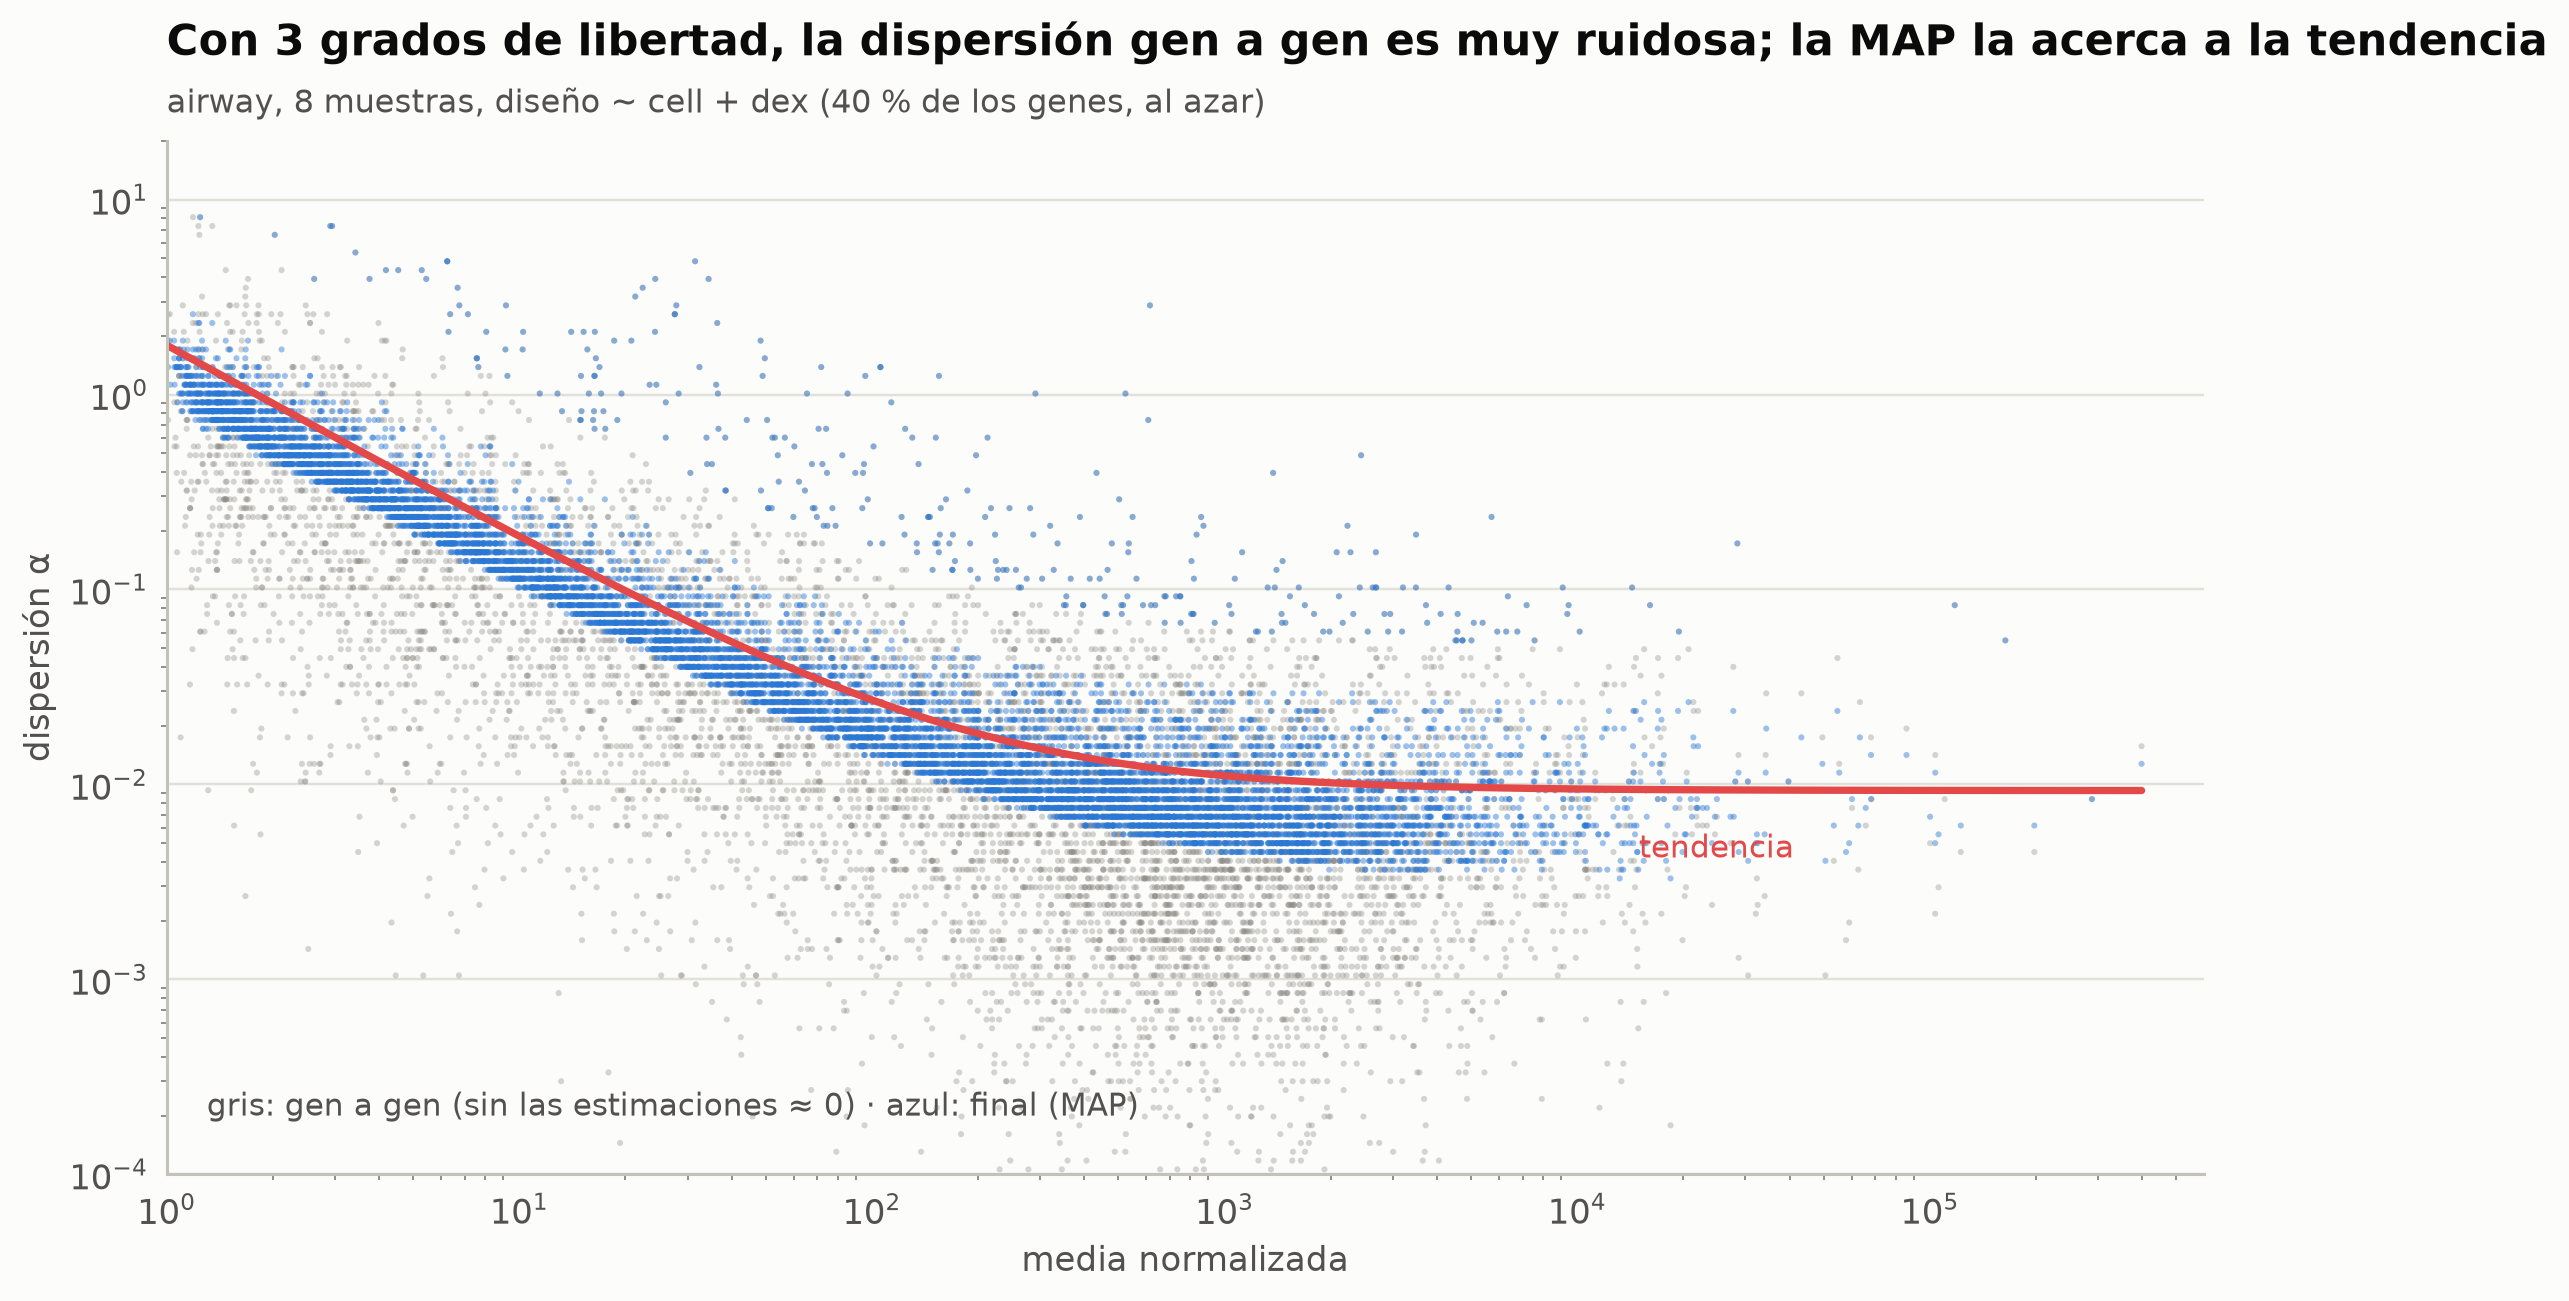

In [20]:
# Figura: dispersiones de los datos reales
fig, ax = plt.subplots(figsize=(10, 5.8))
ok_ = fit_a["a_gw"] >= 1e-6
rs = np.random.default_rng(5).random(len(Ya)) < 0.4
ax.scatter(base_a[ok_ & rs], fit_a["a_gw"][ok_ & rs], s=4, color=ec.MUTED, alpha=0.35, edgecolors="none")
ax.scatter(base_a[rs], fit_a["a_fin"][rs], s=4, color=ec.BLUE, alpha=0.45, edgecolors="none")
xs_ = np.exp(np.linspace(np.log(1), np.log(base_a.max()), 100))
ax.plot(xs_, fit_a["a0"] + fit_a["a1"] / xs_, color=ec.RED, lw=2.4)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_ylim(1e-4, 20); ax.set_xlim(1, base_a.max() * 1.5)
ax.set_xlabel("media normalizada"); ax.set_ylabel("dispersión α")
ec.label_end(ax, xs_[-1] / 30, (fit_a["a0"] + fit_a["a1"] / xs_[-1]) * 0.5, "tendencia", color=ec.RED)
ax.text(1.3, 2e-4, "gris: gen a gen (sin las estimaciones ≈ 0) · azul: final (MAP)", fontsize=10, color=ec.INK_2)
ec.title(ax, "Con 3 grados de libertad, la dispersión gen a gen es muy ruidosa; la MAP la acerca a la tendencia",
         "airway, 8 muestras, diseño ~ cell + dex (40 % de los genes, al azar)")
plt.show()

> 🔎 **Qué observamos.** Con sólo $8-5=3$ grados de libertad residuales, las estimaciones gen a gen (gris) se dispersan
> varios órdenes de magnitud alrededor de la tendencia (rojo), y más de un cuarto de ellas queda en cero (máximo de la
> verosimilitud en el borde: el gen no muestra variación por encima de la de Poisson). Las estimaciones finales (azul)
> se agrupan cerca de la tendencia: es el mismo procedimiento de contracción de la Lección 11.2. La dispersión
> asintótica, $a_0$, corresponde a un coeficiente de variación biológica de alrededor del 10 %: cultivos celulares bien
> controlados.
>
> Las cifras no son idénticas a las de la Lección 11.2 con los mismos datos ($a_0\approx0{,}013$, $a_1\approx2{,}4$,
> varianza previa $\approx0{,}49$, CV biológico ~11 %) porque la **configuración** cambia: allí la rejilla de la dispersión
> empieza en $10^{-4}$, como en el libro, y aquí en $10^{-8}$, el mínimo de DESeq2; allí las medias iniciales salen de
> una dispersión provisional fija y aquí de una estimación por momentos. Eso cambia qué genes quedan «en cero», cuáles
> entran en el ajuste de la tendencia y, por tanto, $a_0$, $a_1$ y la varianza previa. Con sólo 3 grados de libertad
> estas decisiones de detalle pesan; volveremos sobre ello al comparar con `pydeseq2` (sección 9.8).

In [21]:
# Wald para la dexametasona, comprobación a mano con un gen, y LRT (dex: 1 gl; línea celular: 3 gl)
res_a = ann_a.copy()
res_a["baseMean"] = base_a; res_a["log2FC"] = fit_a["lfc"]; res_a["lfcSE"] = fit_a["lfcSE"]
res_a["stat"] = fit_a["stat"]; res_a["pvalue"] = fit_a["pvalue"]

g = np.where(ann_a.symbol == "DUSP1")[0][0]
print(f"DUSP1: β̂ = {fit_a['lfc'][g]:.3f}, SE = {fit_a['lfcSE'][g]:.3f}, "
      f"z = {fit_a['lfc'][g]:.3f}/{fit_a['lfcSE'][g]:.3f} = {fit_a['stat'][g]:.2f}, p = 2Φ(−|z|) = {fit_a['pvalue'][g]:.2e}")

a_fin_a = fit_a["a_fin"][:, None]
ll_full = nb_ll(Ya, fit_a["mu"], a_fin_a).sum(1)
_, _, mu_nodex, _ = irls_nb(Ya, Xa[:, :-1], sf_a, fit_a["a_fin"])          # reducido: ~ cell
_, _, mu_nocell, _ = irls_nb(Ya, Xa[:, [0, -1]], sf_a, fit_a["a_fin"])     # reducido: ~ dex
D_dex = 2 * (ll_full - nb_ll(Ya, mu_nodex, a_fin_a).sum(1))
D_cell = 2 * (ll_full - nb_ll(Ya, mu_nocell, a_fin_a).sum(1))
p_lrt_dex = stats.chi2.sf(np.maximum(D_dex, 0), 1)
p_lrt_cell = stats.chi2.sf(np.maximum(D_cell, 0), 3)
print(f"correlación log10 p (Wald frente a LRT, dex) = "
      f"{np.corrcoef(np.log10(res_a.pvalue + 1e-300), np.log10(p_lrt_dex + 1e-300))[0, 1]:.4f}")
print(f"LRT de la línea celular (χ²₃): {np.sum(bh(p_lrt_cell) < 0.1)} genes cambian entre donantes con FDR < 0,1")

DUSP1: β̂ = 2.948, SE = 0.124, z = 2.948/0.124 = 23.76, p = 2Φ(−|z|) = 9.15e-125
correlación log10 p (Wald frente a LRT, dex) = 0.9937
LRT de la línea celular (χ²₃): 6141 genes cambian entre donantes con FDR < 0,1


> 🔎 **Qué observamos.** La cuenta de Wald de *DUSP1*, una fosfatasa antiinflamatoria clásica inducida por
> glucocorticoides, da un $z$ enorme: el efecto es de muchos errores estándar. Wald y LRT vuelven a coincidir casi
> perfectamente para el coeficiente de la dexametasona. La LRT de 3 grados de libertad responde otra pregunta, que Wald
> no puede responder con un solo coeficiente: **¿difieren los donantes?** Miles de genes lo hacen, y ése es exactamente
> el motivo para incluir `cell` en el diseño (sección 10).

### 9.5 Filtrado independiente y Benjamini-Hochberg

Aplicamos la misma búsqueda que DESeq2: probamos umbrales de media normalizada (cuantiles 0 a 0,95) y nos quedamos con el
que da más genes con `padj < 0,1`. A los genes filtrados se les asigna `padj = NaN`, la convención de DESeq2: no se
contrastaron.

sin filtro: 6537 genes con padj < 0,1; con filtro óptimo (cuantil 0.175, media ≥ 4.76): 6791  →  3527 inducidos y 3264 reprimidos
con padj < 0,05: 5684; con padj < 0,1 y |LFC| > 1: 1410
π̂0(0,5) entre los genes contrastados = 0.569


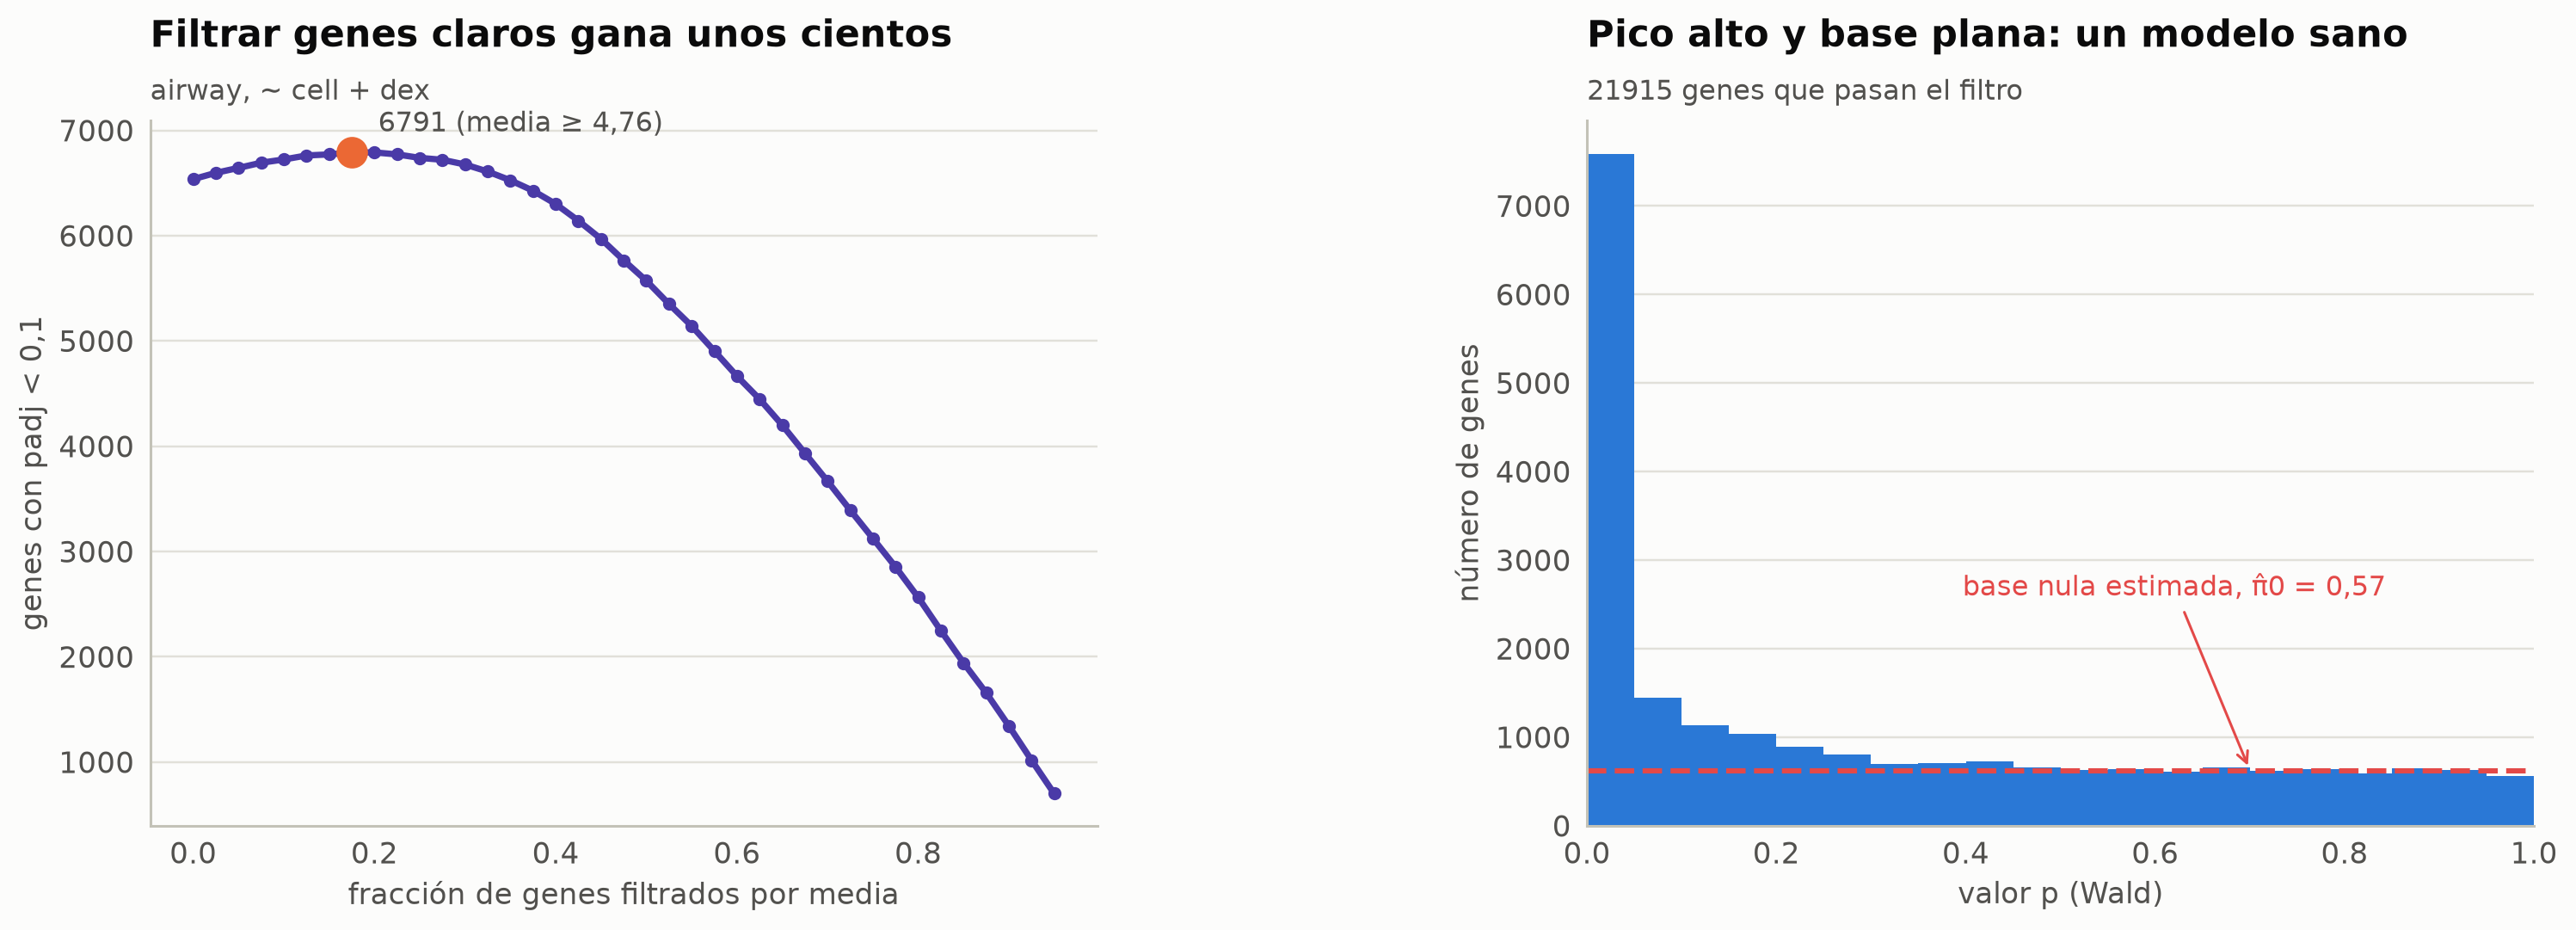

In [22]:
qs_a = np.linspace(0, 0.95, 39)
nrej_a = [int(np.sum(bh(res_a.pvalue[base_a >= np.quantile(base_a, q)]) < 0.1)) for q in qs_a]
ib_a = int(np.argmax(nrej_a)); thr_a = np.quantile(base_a, qs_a[ib_a])
passed = base_a >= thr_a
res_a["padj"] = np.nan
res_a.loc[passed, "padj"] = bh(res_a.pvalue[passed])
sig_a = (res_a.padj < 0.1).to_numpy()
up_a = sig_a & (res_a.log2FC > 0).to_numpy(); dn_a = sig_a & (res_a.log2FC < 0).to_numpy()
print(f"sin filtro: {nrej_a[0]} genes con padj < 0,1; con filtro óptimo (cuantil {qs_a[ib_a]:.3f}, media ≥ {thr_a:.2f}): "
      f"{sig_a.sum()}  →  {up_a.sum()} inducidos y {dn_a.sum()} reprimidos")
print(f"con padj < 0,05: {np.sum(res_a.padj < 0.05)}; con padj < 0,1 y |LFC| > 1: {np.sum(sig_a & (np.abs(res_a.log2FC) > 1))}")
pi0_a = np.mean(res_a.pvalue[passed] > 0.5) / 0.5
print(f"π̂0(0,5) entre los genes contrastados = {pi0_a:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), gridspec_kw={"wspace": 0.28})
ax = axes[0]
ax.plot(qs_a, nrej_a, color=ec.VIOLET, lw=2.4, marker="o", ms=4)
ax.plot([qs_a[ib_a]], [nrej_a[ib_a]], "o", color=ec.ORANGE, ms=11)
ax.annotate(f"{nrej_a[ib_a]} (media ≥ {fmt(thr_a)})", (qs_a[ib_a], nrej_a[ib_a]), xytext=(10, 8),
            textcoords="offset points", fontsize=10.5, color=ec.INK_2)
ax.set_xlabel("fracción de genes filtrados por media"); ax.set_ylabel("genes con padj < 0,1")
ec.title(ax, "Filtrar genes claros gana unos cientos", "airway, ~ cell + dex")
ax = axes[1]
ax.hist(res_a.pvalue[passed], bins=np.linspace(0, 1, 21), color=ec.BLUE, edgecolor="white")
ax.axhline(pi0_a * passed.sum() / 20, color=ec.RED, ls="--", lw=2)
ax.annotate(f"base nula estimada, π̂0 = {fmt(pi0_a)}", (0.7, pi0_a * passed.sum() / 20), xytext=(0.62, 2600),
            ha="center", color=ec.RED, fontsize=10.5, arrowprops=dict(arrowstyle="->", color=ec.RED, lw=1))
ax.set_xlabel("valor p (Wald)"); ax.set_ylabel("número de genes"); ax.set_xlim(0, 1)
ec.title(ax, "Pico alto y base plana: un modelo sano", f"{passed.sum()} genes que pasan el filtro")
plt.show()

> 🔎 **Qué observamos.** La dexametasona es un estímulo potente: miles de genes cambian con FDR $<0{,}1$, repartidos casi
> por igual entre inducidos y reprimidos, y $\hat\pi_0$ indica que cerca de la mitad de los genes contrastados
> responde en alguna medida (18 horas de un glucocorticoide potente reorganizan buena parte del transcriptoma). El histograma tiene la forma de manual: un pico enorme junto a cero y una base plana, sin
> forma de U. El filtrado independiente vuelve a ganar descubrimientos, aquí algunos cientos.

### 9.6 Contracción del LFC y los gráficos interactivos

Contraemos con la misma previa normal que en la simulación. Luego construimos el gráfico MA y el *volcano* con Plotly:
**pase el cursor** sobre los puntos para ver el símbolo del gen, su media, su LFC (de máxima verosimilitud y contraído) y
su `padj`. Busque *ZBTB16*, *FKBP5* o *PER1*.

In [23]:
sp_a = np.quantile(np.abs(res_a.log2FC[base_a > 5]), 0.95) / stats.norm.ppf(0.975)
res_a["lfc_shr"] = res_a.log2FC * sp_a ** 2 / (sp_a ** 2 + res_a.lfcSE ** 2)
print(f"σ_p (airway) = {sp_a:.3f}")
display(res_a[sig_a].sort_values("pvalue").head(12)[["symbol", "baseMean", "log2FC", "lfcSE", "lfc_shr", "stat",
                                                    "pvalue", "padj"]].round(4))

# Submuestra de los genes no significativos (todos los significativos se muestran) para aligerar las figuras
rng_p = np.random.default_rng(7)
show = sig_a | (rng_p.random(len(res_a)) < 0.25)
def hover_data(mask):
    d = res_a[mask]
    return np.column_stack([d.symbol.fillna(d.gene_id), d.baseMean.round(1), d.log2FC.round(2),
                            d.lfc_shr.round(2), d.padj.map(lambda v: "filtrado" if np.isnan(v) else f"{v:.2e}")])
HOVER = ("<b>%{customdata[0]}</b><br>media normalizada = %{customdata[1]}<br>LFC (MV) = %{customdata[2]}"
         "<br>LFC contraído = %{customdata[3]}<br>padj = %{customdata[4]}")

σ_p (airway) = 0.617


,symbol,baseMean,log2FC,lfcSE,lfc_shr,stat,pvalue,padj
2746,CACNB2,652.5458,3.3482,0.1155,3.2350,28.9960,0.0,0.0
22912,STEAP2,3671.7296,1.9692,0.0790,1.9375,24.9201,0.0,0.0
25789,MAOA,2851.4460,3.3339,0.1390,3.1730,23.9860,0.0,0.0
20765,DUSP1,4164.0475,2.9479,0.1241,2.8334,23.7577,0.0,0.0
1061,NEXN,6750.3164,2.0115,0.0858,1.9734,23.4437,0.0,0.0
21711,PRSS35,384.5314,-2.8189,0.1229,-2.7114,-22.9393,0.0,0.0
15991,SAMHD1,17210.3464,3.7580,0.1667,3.5027,22.5465,0.0,0.0
7682,RP11-986E7.7,3280.8548,3.2243,0.1455,3.0547,22.1662,0.0,0.0
5460,FGD4,1495.3815,2.2178,0.1003,2.1608,22.1116,0.0,0.0
1227,VCAM1,624.4811,-3.6879,0.1691,-3.4305,-21.8105,0.0,0.0


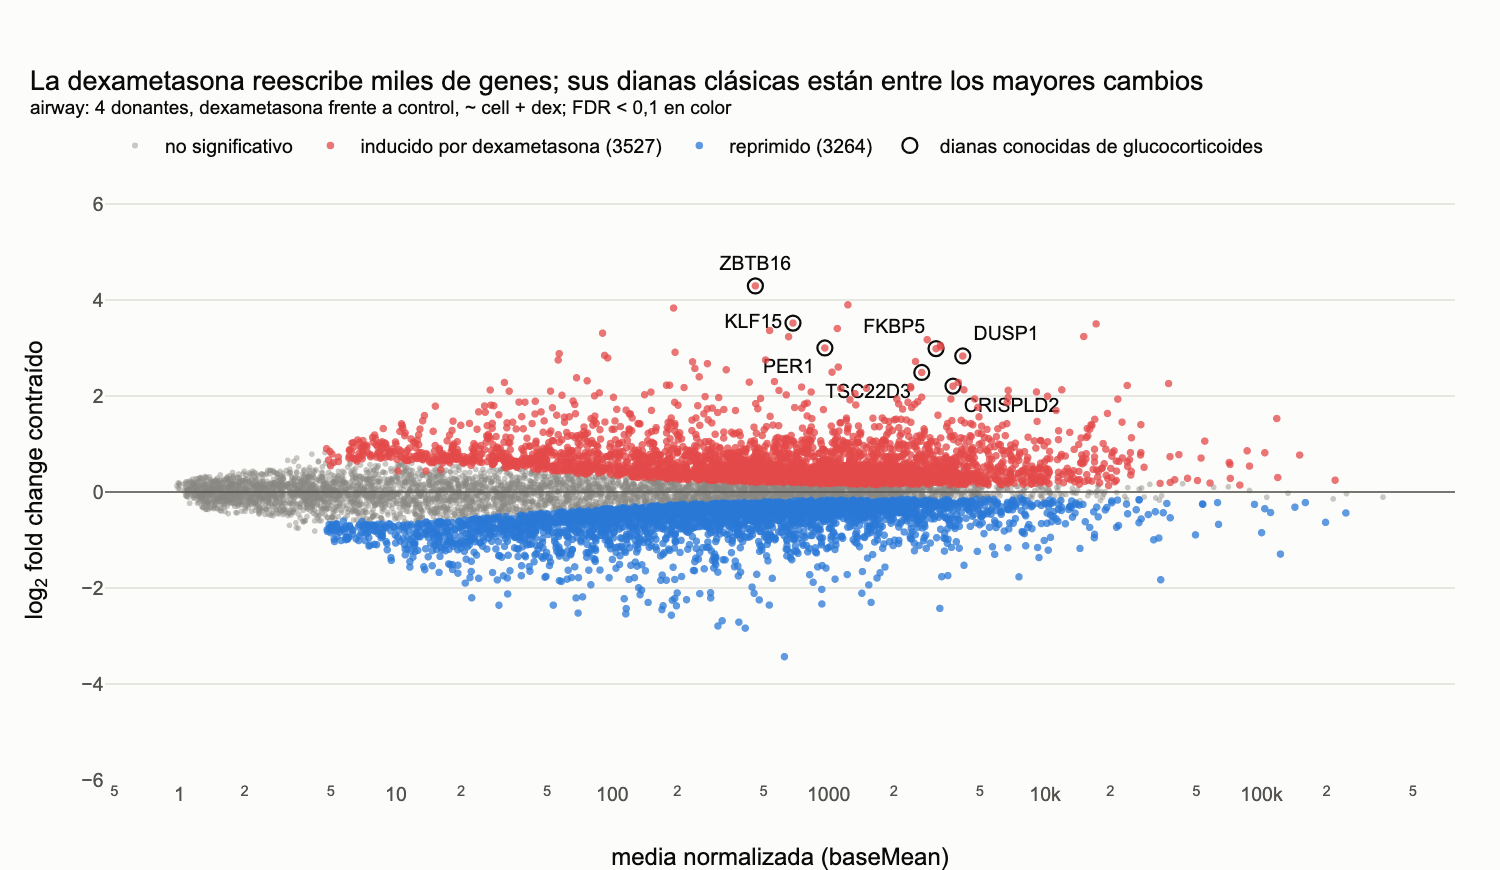

In [24]:
# 🔍 Interactivo 2: gráfico MA de los datos reales (LFC contraído; el hover muestra también el de máxima verosimilitud)
fig = go.Figure()
groups = [(show & ~sig_a, "no significativo", ec.MUTED, 4, 0.45),
          (up_a, f"inducido por dexametasona ({up_a.sum()})", ec.RED, 5, 0.75),
          (dn_a, f"reprimido ({dn_a.sum()})", ec.BLUE, 5, 0.75)]
for mask, name, color, size, op in groups:
    d = res_a[mask]
    fig.add_trace(go.Scattergl(x=d.baseMean, y=np.clip(d.lfc_shr, -8, 8), mode="markers", name=name,
                               marker=dict(size=size, color=color, opacity=op), customdata=hover_data(mask),
                               hovertemplate=HOVER + f"<extra>{name}</extra>"))
targets = ["FKBP5", "TSC22D3", "PER1", "ZBTB16", "DUSP1", "KLF15", "CRISPLD2"]
tg = res_a[res_a.symbol.isin(targets)]
POS = {"ZBTB16": "top center", "KLF15": "middle left", "PER1": "bottom left", "FKBP5": "top left",
       "DUSP1": "top right", "TSC22D3": "bottom left", "CRISPLD2": "bottom right"}
fig.add_trace(go.Scatter(x=tg.baseMean, y=tg.lfc_shr, mode="markers+text", text=tg.symbol,
                         textposition=[POS[s_] for s_ in tg.symbol],
                         marker=dict(size=10, color="rgba(0,0,0,0)", line=dict(color=ec.INK, width=1.5)),
                         name="dianas conocidas de glucocorticoides", customdata=hover_data(res_a.symbol.isin(targets)),
                         hovertemplate=HOVER + "<extra>diana conocida</extra>"))
fig.add_hline(y=0, line_color=ec.INK_2, line_width=1)
fig.update_xaxes(type="log", title="media normalizada (baseMean)")
fig.update_yaxes(title="log<sub>2</sub> fold change contraído", range=[-6, 6.5])
fig.update_layout(title="La dexametasona reescribe miles de genes; sus dianas clásicas están entre los mayores cambios"
                        "<br><sup>airway: 4 donantes, dexametasona frente a control, ~ cell + dex; FDR < 0,1 en color</sup>",
                  height=580, margin=dict(t=120, l=70, r=30, b=60),
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.show()

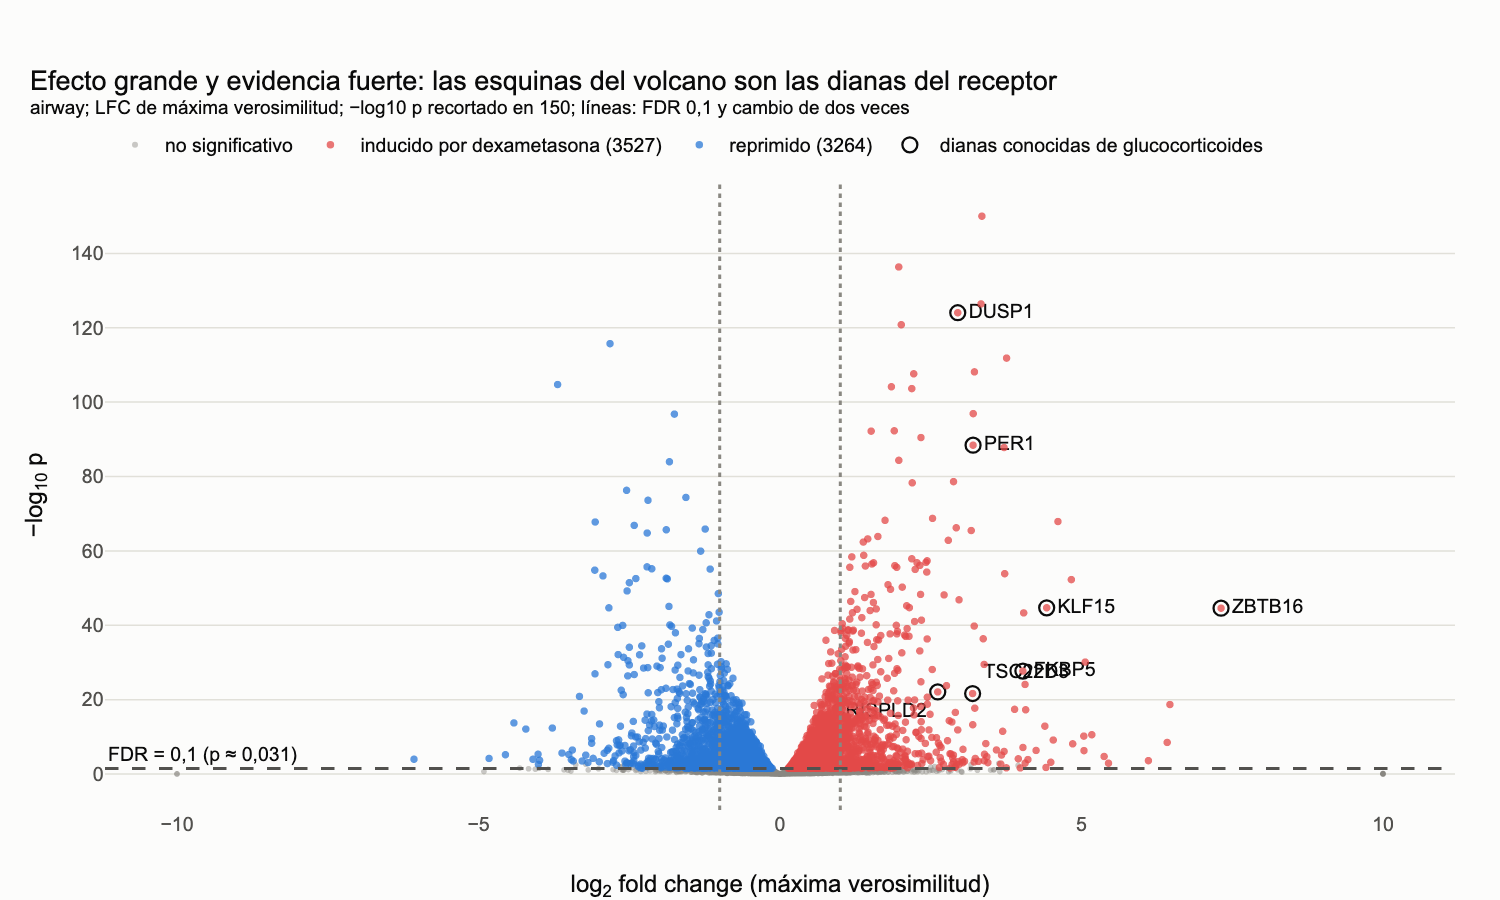

In [25]:
# 🔍 Interactivo 3: volcano de los datos reales
lp_a = -np.log10(np.maximum(res_a.pvalue, 1e-300))
p_thr_a = res_a.pvalue[sig_a].max()                         # valor p del último gen declarado significativo
fig = go.Figure()
for mask, name, color, size, op in groups:
    d = res_a[mask]
    fig.add_trace(go.Scattergl(x=np.clip(d.log2FC, -10, 10), y=np.minimum(lp_a[mask], 150), mode="markers", name=name,
                               marker=dict(size=size, color=color, opacity=op), customdata=hover_data(mask),
                               hovertemplate=HOVER + f"<extra>{name}</extra>"))
POSV = {"CRISPLD2": "bottom left", "TSC22D3": "top right"}
fig.add_trace(go.Scatter(x=tg.log2FC, y=np.minimum(lp_a[tg.index], 150), mode="markers+text", text=tg.symbol,
                         textposition=[POSV.get(s_, "middle right") for s_ in tg.symbol], marker=dict(size=10, color="rgba(0,0,0,0)",
                         line=dict(color=ec.INK, width=1.5)), name="dianas conocidas de glucocorticoides",
                         customdata=hover_data(res_a.symbol.isin(targets)),
                         hovertemplate=HOVER + "<extra>diana conocida</extra>"))
fig.add_hline(y=-np.log10(p_thr_a), line_dash="dash", line_color=ec.INK_2,
              annotation_text=f"FDR = 0,1 (p ≈ {p_thr_a:.3f})".replace(".", ","), annotation_position="top left")
for x in (-1, 1):
    fig.add_vline(x=x, line_dash="dot", line_color=ec.MUTED)
fig.update_layout(title="Efecto grande y evidencia fuerte: las esquinas del volcano son las dianas del receptor"
                        "<br><sup>airway; LFC de máxima verosimilitud; −log10 p recortado en 150; líneas: FDR 0,1 y cambio de dos veces</sup>",
                  xaxis_title="log<sub>2</sub> fold change (máxima verosimilitud)", yaxis_title="−log<sub>10</sub> p",
                  height=600, margin=dict(t=120, l=70, r=30, b=60),
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.show()

> 🔎 **Qué observamos.** En el MA, la nube de genes no significativos está centrada en cero en todo el rango de
> expresión (la normalización funcionó) y, tras la contracción, no hay embudo. Las dianas conocidas de los
> glucocorticoides aparecen entre los cambios más grandes, todas inducidas. En el *volcano*, fíjese en *ZBTB16*: tiene el
> mayor LFC del grupo pero una evidencia menor que *DUSP1* o *PER1*, porque en los controles casi no se expresa y su SE
> es mayor. Pase el cursor por los puntos con LFC grande y $-\log_{10}p$ pequeño de las alas inferiores: son genes
> claros, el mismo fenómeno que en la simulación.

> ✅ **Compruebe su comprensión.** En el MA interactivo, localice un gen con LFC de máxima verosimilitud mayor que 3 y
> LFC contraído menor que 1. ¿Cuál es su media normalizada? ¿Por qué la contracción fue tan fuerte?

### 9.7 Control de cordura: las dianas conocidas de los glucocorticoides

Un análisis de expresión diferencial debe **pasar una prueba de sentido común** antes de creer sus miles de genes: los
genes que la biología ya conoce deben aparecer. El receptor de glucocorticoides activado se une a elementos de respuesta
en el ADN e induce, en casi todos los tejidos, un conjunto bien estudiado de genes: *FKBP5* (una cochaperona del propio
receptor, que cierra un circuito de retroalimentación negativa), *TSC22D3* (GILZ, antiinflamatorio), *PER1* (reloj
circadiano), *ZBTB16*, *DUSP1* (MKP-1, apaga la señalización de MAP quinasas), *KLF15* y *CRISPLD2* (el gen destacado
por Himes *et al.*, 2014). Si alguno no apareciera, sospecharíamos de un intercambio de muestras o de un error de diseño.

,baseMean,log2FC,lfcSE,lfc_shr,stat,padj,veces,rango
symbol,,,,,,,,
FKBP5,3132.769,4.028,0.364,2.987,11.054,0.0,16.3,209
TSC22D3,2692.588,3.194,0.328,2.490,9.728,0.0,9.2,313
PER1,960.242,3.202,0.160,3.000,20.019,0.0,9.2,18
ZBTB16,458.370,7.314,0.518,4.294,14.127,0.0,159.1,86
DUSP1,4164.047,2.948,0.124,2.833,23.758,0.0,7.7,4
KLF15,683.774,4.423,0.313,3.520,14.144,0.0,21.5,84
CRISPLD2,3753.858,2.616,0.266,2.206,9.828,0.0,6.1,304


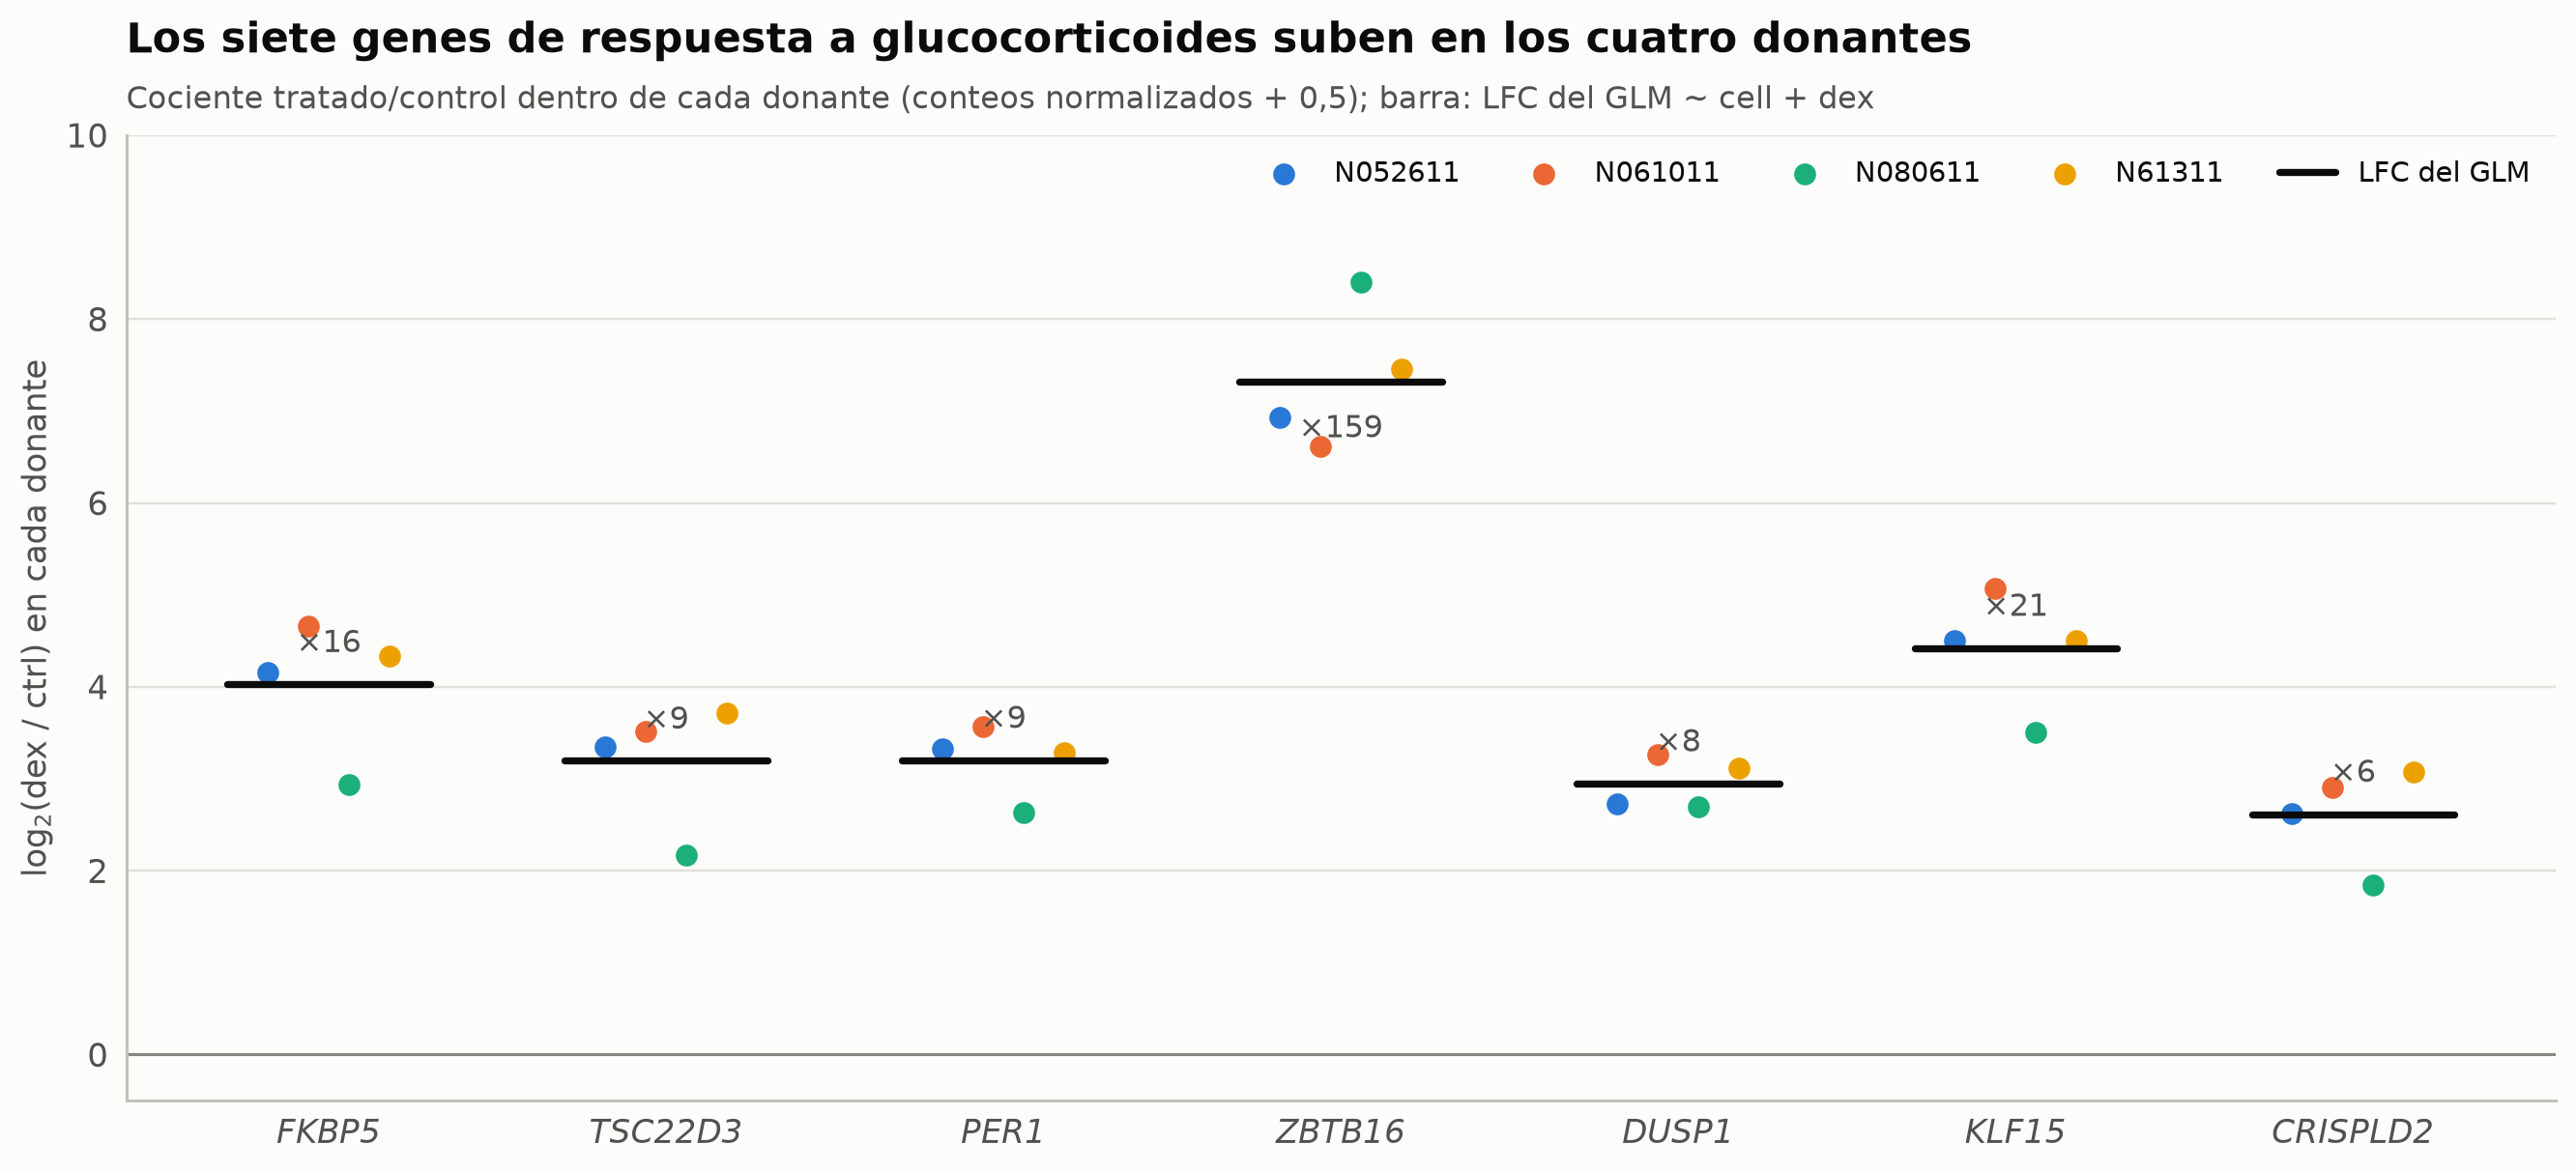

In [26]:
tab_t = res_a[res_a.symbol.isin(targets)].set_index("symbol").loc[targets]
display(tab_t[["baseMean", "log2FC", "lfcSE", "lfc_shr", "stat", "padj"]].round(3)
        .assign(veces=lambda d: (2 ** d.log2FC).round(1),
                rango=lambda d: [int((res_a.pvalue < p).sum()) + 1 for p in tab_t.pvalue]))

# Figura: log2(dex/ctrl) de cada donante frente al LFC del GLM, gen a gen
fig, ax = plt.subplots(figsize=(12, 5.4))
cell_col = dict(zip(cells, ec.CATEGORICAL[:4]))
offs = dict(zip(cells, [-0.18, -0.06, 0.06, 0.18]))
for k, gname in enumerate(targets):
    gi_ = np.where(res_a.symbol == gname)[0][0]
    nn = Ya[gi_] / sf_a + 0.5
    for c in cells:
        j0 = np.where((smp.cell == c) & (smp.dex == "ctrl"))[0][0]; j1 = np.where((smp.cell == c) & (smp.dex == "dex"))[0][0]
        ax.scatter(k + offs[c], np.log2(nn[j1] / nn[j0]), s=55, color=cell_col[c], zorder=3,
                   label=c if k == 0 else None)
    lf = res_a.log2FC[gi_]
    ax.plot([k - 0.3, k + 0.3], [lf, lf], color=ec.INK, lw=2.4, zorder=4, label="LFC del GLM" if k == 0 else None)
    ax.text(k, lf + 0.35 if gname != "ZBTB16" else lf - 0.6, f"×{2 ** lf:.0f}", ha="center", fontsize=10.5, color=ec.INK_2)
ax.axhline(0, color=ec.MUTED, lw=1)
ax.set_xticks(range(len(targets)), targets, fontstyle="italic"); ax.set_xlim(-0.6, len(targets) - 0.4)
ax.set_ylabel("log$_2$(dex / ctrl) en cada donante"); ax.set_ylim(-0.5, 10)
ax.legend(loc="upper right", frameon=False, ncol=5, fontsize=9.5, bbox_to_anchor=(1, 1.0))
ec.title(ax, "Los siete genes de respuesta a glucocorticoides suben en los cuatro donantes",
         "Cociente tratado/control dentro de cada donante (conteos normalizados + 0,5); barra: LFC del GLM ~ cell + dex")
plt.show()

> 🔎 **Qué observamos.** Las siete dianas están entre los genes más significativos y suben en **los cuatro donantes**,
> con cambios de 6 a más de 100 veces. Los cuatro puntos de cada gen quedan cerca de la barra del GLM: el efecto multiplicativo
> es parecido en cada donante aunque los niveles basales difieran, exactamente lo que supone el modelo `~ cell + dex`.
> *ZBTB16* muestra el cambio más espectacular porque parte de casi cero, y por eso su dispersión entre donantes es mayor.

### 9.8 Comparación con `pydeseq2`

`pydeseq2` es la reimplementación en Python de DESeq2 (Muzellec *et al.*, 2023). Lo usamos con el mismo diseño, el mismo
prefiltro y $\alpha=0{,}1$ (el código es el del recuadro «deseq2_python.py» del libro) y comparamos. Conviene dejar
claros los papeles: **`pydeseq2` es la referencia**, una implementación mantenida y probada de un método publicado;
la nuestra es **didáctica**, escrita para entender cada paso. Si discrepan, la cifra que se informa en un trabajo es la de
la herramienta de referencia, y lo interesante es averiguar *de dónde* sale la diferencia. En Colab se instala
con `pip` (unos 30 s); si la instalación fallara, la sección se salta sin romper el resto del notebook.

In [27]:
# Instalación protegida de pydeseq2 (sólo en Colab; localmente se usa si ya está instalado)
try:
    import pydeseq2
except ImportError:
    if IN_COLAB:
        %pip install -q pydeseq2
try:
    import pydeseq2
    from pydeseq2.dds import DeseqDataSet
    from pydeseq2.ds import DeseqStats
    HAVE_PYD = True
    print("pydeseq2", pydeseq2.__version__)
except ImportError:
    HAVE_PYD = False
    print("pydeseq2 no está disponible: se omite la comparación")

pydeseq2 0.5.4


In [28]:
if HAVE_PYD:
    t = time.time()
    cuentas = pd.DataFrame(Ya.T.astype(int), index=smp.run, columns=ann_a.gene_id)      # muestras x genes
    meta = pd.DataFrame({"cell": smp.cell.values, "dex": smp.dex.values}, index=smp.run)
    with warnings.catch_warnings(record=True) as avisos:        # guardamos los avisos para mostrarlos después
        warnings.simplefilter("always")
        try:
            from pydeseq2.default_inference import DefaultInference
            inf = dict(inference=DefaultInference(n_cpus=2))
        except ImportError:
            inf = {}
        try:
            dds = DeseqDataSet(counts=cuentas, metadata=meta, design="~cell + dex", refit_cooks=True, quiet=True, **inf)
        except TypeError:                                   # versiones antiguas (< 0.5)
            dds = DeseqDataSet(counts=cuentas, metadata=meta, design_factors=["cell", "dex"], refit_cooks=True,
                               quiet=True, **inf)
        dds.deseq2()
        ds = DeseqStats(dds, contrast=["dex", "dex", "ctrl"], alpha=0.1, quiet=True, **inf)
        ds.summary()
        py = ds.results_df.copy()
        coef_dex = [c for c in dds.varm["LFC"].columns if "dex" in c][-1]
        ds.lfc_shrink(coeff=coef_dex)                       # previa de colas pesadas (apeglm)
        py["lfc_apeglm"] = ds.results_df["log2FoldChange"]
    print(f"pydeseq2 terminado en {time.time() - t:.0f} s")
    # Avisos de pydeseq2 (sin los RuntimeWarning numéricos de numpy): con pocos grados de libertad residuales
    # avisa de que la estimación de la varianza previa no es fiable
    for msg in dict.fromkeys(str(w_.message).strip() for w_ in avisos if issubclass(w_.category, UserWarning)):
        print("⚠️ aviso de pydeseq2:", msg)
    tc = dds.uns.get("trend_coeffs")
    print("factores de tamaño idénticos:", np.allclose(dds.obs["size_factors"].values if "size_factors" in dds.obs
                                                        else dds.obsm["size_factors"], sf_a, rtol=1e-3))
    if tc is not None:
        print(f"tendencia pydeseq2: α = {float(tc.iloc[0]):.4f} + {float(tc.iloc[1]):.3f}/μ  ·  "
              f"nuestra: {fit_a['a0']:.4f} + {fit_a['a1']:.3f}/μ")
    print(f"varianza previa pydeseq2 = {float(dds.uns['prior_disp_var']):.3f}  ·  nuestra = {fit_a['s2p']:.3f}")
    gw_py = dds.var["genewise_dispersions"].values
    print(f"dispersiones gen a gen en el mínimo (≈0): pydeseq2 {np.mean(gw_py < 1e-6):.0%} · nuestra rejilla "
          f"{np.mean(fit_a['a_gw'] < 1e-6):.0%}")

    j = res_a.set_index("gene_id").join(py.add_suffix("_py"))
    big = j.baseMean >= 10
    sig_me = j.padj < 0.1; sig_py = j.padj_py < 0.1
    both = int((sig_me & sig_py).sum())
    print(f"\nLFC: correlación de Pearson (genes con media ≥ 10) = {np.corrcoef(j.log2FC[big], j.log2FoldChange_py[big])[0, 1]:.4f}")
    print(f"valores p: correlación de Spearman = {stats.spearmanr(j.pvalue, j.pvalue_py, nan_policy='omit')[0]:.4f}")
    print(f"padj < 0,1 → propio: {int(sig_me.sum())} · pydeseq2: {int(sig_py.sum())} · ambos: {both} "
          f"({both / sig_py.sum():.1%} de los de pydeseq2) · sólo propio: {int((sig_me & ~sig_py).sum())} · "
          f"sólo pydeseq2: {int((~sig_me & sig_py).sum())}")
    display(j.loc[j.symbol.isin(targets)].set_index("symbol").loc[targets,
            ["log2FC", "log2FoldChange_py", "lfc_shr", "lfc_apeglm_py", "padj", "padj_py"]].round(3))

pydeseq2 terminado en 18 s
⚠️ aviso de pydeseq2: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
factores de tamaño idénticos: True
tendencia pydeseq2: α = 0.0102 + 3.434/μ  ·  nuestra: 0.0093 + 1.783/μ
varianza previa pydeseq2 = 0.250  ·  nuestra = 0.745
dispersiones gen a gen en el mínimo (≈0): pydeseq2 56% · nuestra rejilla 28%

LFC: correlación de Pearson (genes con media ≥ 10) = 0.9838
valores p: correlación de Spearman = 0.9889
padj < 0,1 → propio: 6791 · pydeseq2: 5173 · ambos: 5097 (98.5% de los de pydeseq2) · sólo propio: 1694 · sólo pydeseq2: 76


,log2FC,log2FoldChange_py,lfc_shr,lfc_apeglm_py,padj,padj_py
symbol,,,,,,
FKBP5,4.028,4.028,2.987,3.961,0.0,0.0
TSC22D3,3.194,3.194,2.490,3.121,0.0,0.0
PER1,3.202,3.201,3.000,3.187,0.0,0.0
ZBTB16,7.314,7.312,4.294,7.239,0.0,0.0
DUSP1,2.948,2.948,2.833,2.939,0.0,0.0
KLF15,4.423,4.448,3.520,4.430,0.0,0.0
CRISPLD2,2.616,2.616,2.206,2.598,0.0,0.0


In [29]:
# ¿De dónde sale la diferencia? Cambiamos una pieza cada vez y contamos genes con padj < 0,1
# (mismo filtrado independiente que en la sección 9.5: el mejor cuantil de media normalizada)
def n_de(afin):
    b_, se_, _, _ = irls_nb(Ya, Xa, sf_a, afin)
    p_ = 2 * stats.norm.sf(np.abs(b_[:, -1] / se_[:, -1]))
    return max(int(np.sum(bh(p_[base_a >= np.quantile(base_a, q)]) < 0.1)) for q in qs_a)

if HAVE_PYD:
    t = time.time()
    d_025 = dispersions(Ya, Xa, sf_a, s2_fix=0.25)                     # nuestra MAP con la varianza previa en el suelo
    disp_py = dds.var["dispersions"].reindex(ann_a.gene_id).to_numpy(float)
    disp_py = np.where(np.isfinite(disp_py), disp_py, fit_a["a_fin"])  # por si algún gen quedó sin dispersión
    tabla = pd.DataFrame({
        "dispersiones": [f"nuestras (σ_d² estimada = {fit_a['s2p']:.3f})".replace(".", ","), "nuestras con σ_d² = 0,25 (suelo)",
                         "finales de pydeseq2", "finales de pydeseq2"],
        "GLM y Wald": ["nuestro", "nuestro", "nuestro", "pydeseq2"],
        "genes con padj < 0,1": [int(sig_a.sum()), n_de(d_025["a_fin"]), n_de(disp_py), int(sig_py.sum())]})
    display(tabla)
    print(f"({time.time() - t:.0f} s)")

,dispersiones,GLM y Wald,"genes con padj < 0,1"
0,"nuestras (σ_d² estimada = 0,745)",nuestro,6791
1,"nuestras con σ_d² = 0,25 (suelo)",nuestro,6011
2,finales de pydeseq2,nuestro,5192
3,finales de pydeseq2,pydeseq2,5173


(3 s)


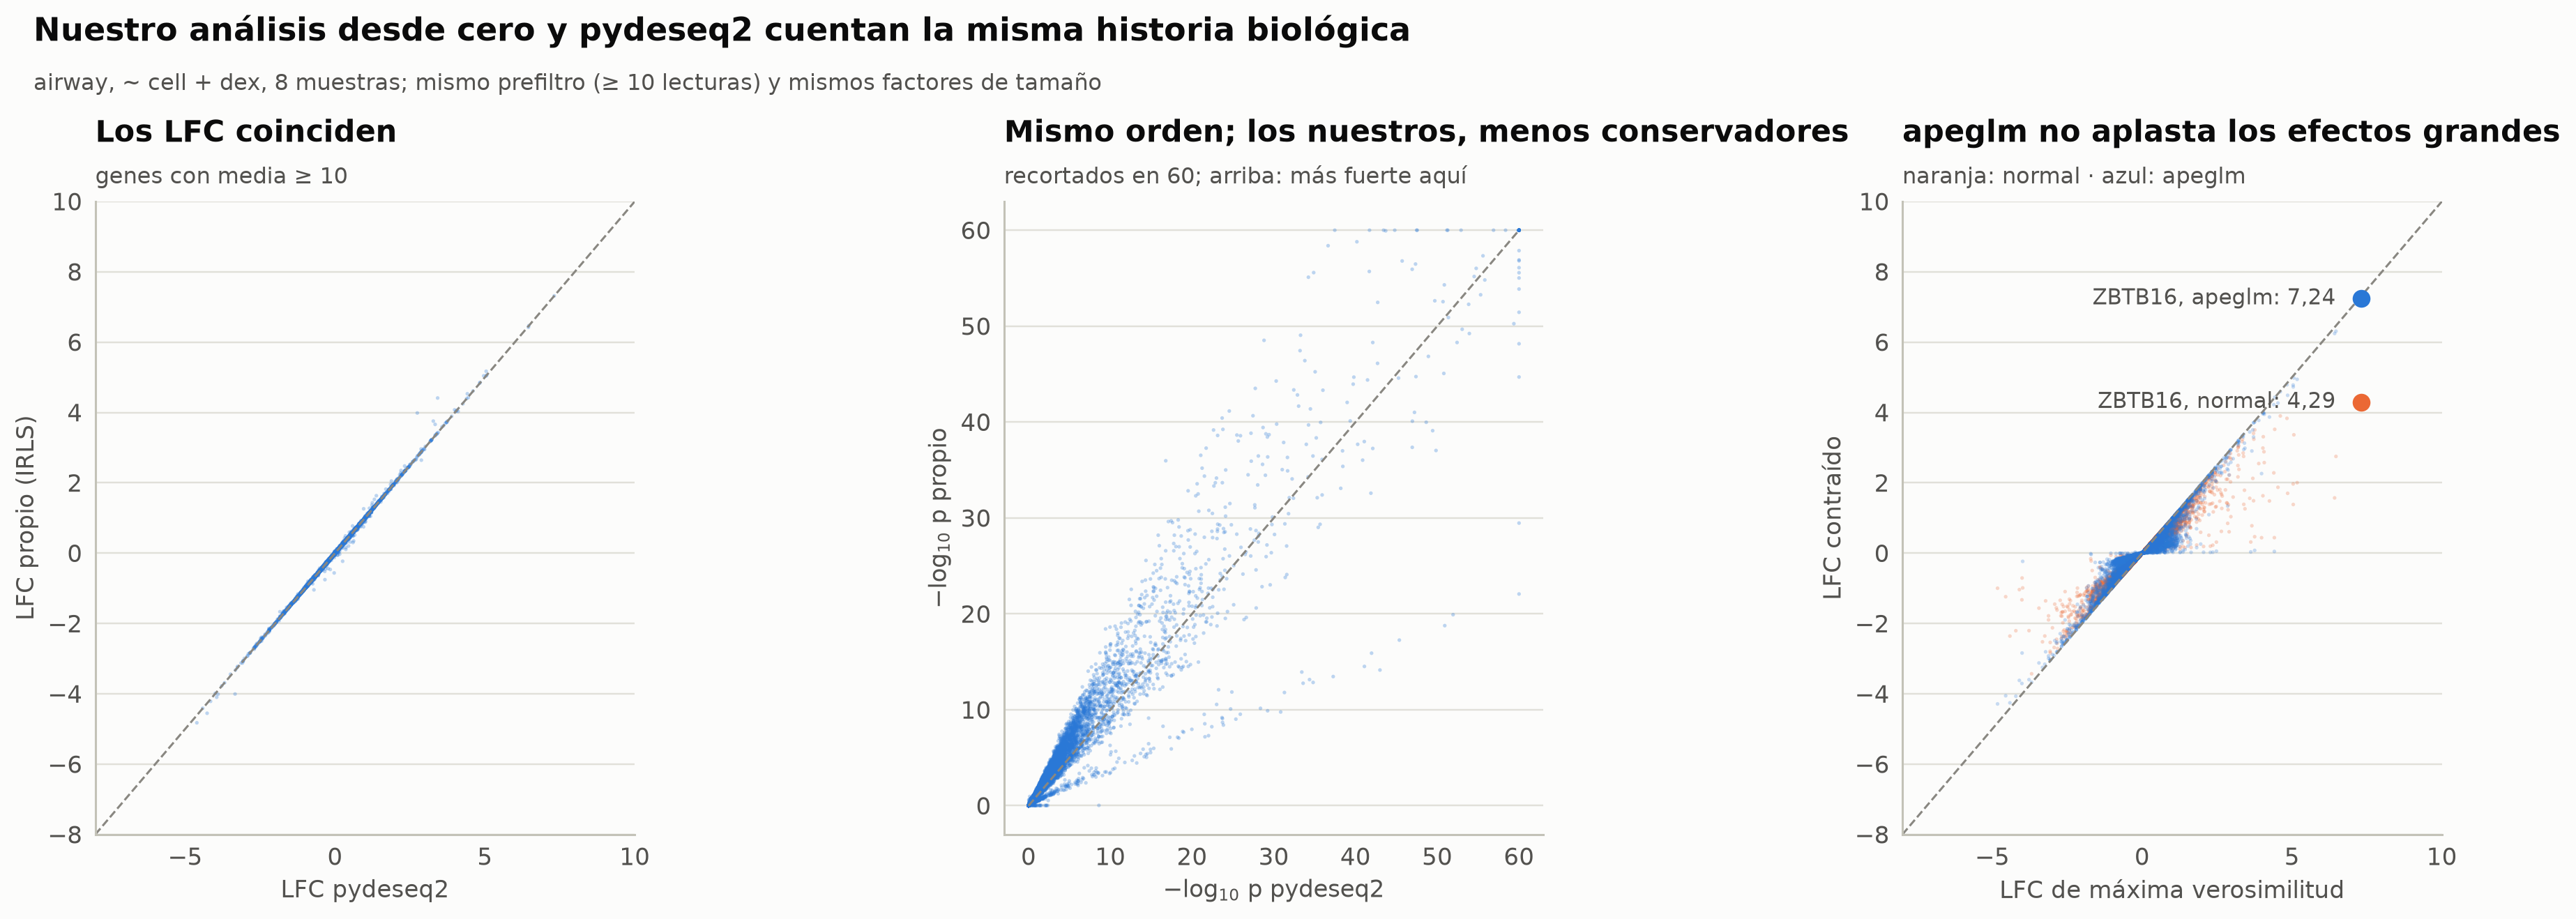

In [30]:
if HAVE_PYD:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), gridspec_kw={"wspace": 0.34})
    ax = axes[0]
    ax.scatter(j.log2FoldChange_py[big], j.log2FC[big], s=3, color=ec.BLUE, alpha=0.3, edgecolors="none")
    ax.plot([-8, 10], [-8, 10], color=ec.MUTED, ls="--", lw=1)
    ax.set_xlim(-8, 10); ax.set_ylim(-8, 10)
    ax.set_xlabel("LFC pydeseq2"); ax.set_ylabel("LFC propio (IRLS)")
    ec.title(ax, "Los LFC coinciden", "genes con media ≥ 10")
    ax = axes[1]
    lp_me = -np.log10(np.maximum(j.pvalue, 1e-300)); lp_py = -np.log10(np.maximum(j.pvalue_py, 1e-300))
    ax.scatter(np.minimum(lp_py, 60), np.minimum(lp_me, 60), s=3, color=ec.BLUE, alpha=0.3, edgecolors="none")
    ax.plot([0, 60], [0, 60], color=ec.MUTED, ls="--", lw=1)
    ax.set_xlabel("−log$_{10}$ p pydeseq2"); ax.set_ylabel("−log$_{10}$ p propio")
    ec.title(ax, "Mismo orden; los nuestros, menos conservadores", "recortados en 60; arriba: más fuerte aquí")
    ax = axes[2]
    shr_idx = j.symbol.isin(targets)
    xx = j.log2FC[big]; ax.scatter(xx, j.lfc_shr[big], s=3, color=ec.ORANGE, alpha=0.25, edgecolors="none")
    ax.scatter(xx, j.lfc_apeglm_py[big], s=3, color=ec.BLUE, alpha=0.25, edgecolors="none")
    zb = j[j.symbol == "ZBTB16"].iloc[0]
    for v_, c_, lab in [(zb.lfc_shr, ec.ORANGE, "normal"), (zb.lfc_apeglm_py, ec.BLUE, "apeglm")]:
        ax.scatter([zb.log2FC], [v_], s=70, color=c_, edgecolor=ec.INK, zorder=5)
        ax.annotate(f"ZBTB16, {lab}: {fmt(v_)}", (zb.log2FC, v_), xytext=(-12, 0), ha="right", va="center",
                    textcoords="offset points", fontsize=10, color=ec.INK_2)
    ax.plot([-8, 10], [-8, 10], color=ec.MUTED, ls="--", lw=1)
    ax.set_xlim(-8, 10); ax.set_ylim(-8, 10)
    ax.set_xlabel("LFC de máxima verosimilitud"); ax.set_ylabel("LFC contraído")
    ec.title(ax, "apeglm no aplasta los efectos grandes", "naranja: normal · azul: apeglm")
    ec.fig_title(fig, "Nuestro análisis desde cero y pydeseq2 cuentan la misma historia biológica",
                 "airway, ~ cell + dex, 8 muestras; mismo prefiltro (≥ 10 lecturas) y mismos factores de tamaño")
    plt.show()

> 🔎 **Qué observamos.** Los factores de tamaño son idénticos y los LFC prácticamente iguales. Los valores $p$ ordenan los
> genes casi igual (Spearman muy cercano a 1), y casi todos los genes que `pydeseq2` declara significativos también lo son
> en nuestro análisis; el nuestro, sin embargo, declara **más**: unos 1 700 genes sólo aparecen en nuestra lista y apenas
> unas decenas sólo en la de `pydeseq2` (las cifras exactas, en la salida de arriba). La cifra que informaríamos es la de
> la referencia, `pydeseq2`. La tabla localiza el origen de la diferencia:
>
> * **Todo está en las dispersiones.** Nuestro GLM y nuestra prueba de Wald, alimentados con las dispersiones finales de
>   `pydeseq2`, dan prácticamente su mismo número de genes: el ajuste de los coeficientes no tiene nada que ver.
> * **Cerca de la mitad la explica la varianza previa.** La nuestra sale $\approx0{,}75$; la de `pydeseq2` queda en su
>   suelo, $0{,}25$. Con una previa más ancha, la MAP se aleja menos de las estimaciones gen a gen, que en muchos genes
>   son pequeñas, y las pruebas se vuelven menos conservadoras. Fijando nosotros $\sigma_d^2=0{,}25$ se recupera
>   aproximadamente la mitad del camino.
> * **El resto viene de las estimaciones gen a gen y de la tendencia.** El optimizador de `pydeseq2` (versión 0.5.4)
>   deja más de la mitad de los genes en el mínimo permitido, $10^{-8}$; nuestra rejilla, muchos menos. Para esos genes la
>   verosimilitud de perfil es **casi plana**: nuestro máximo apenas mejora el valor en $10^{-8}$, así que ninguna de las
>   dos respuestas es «la correcta». Pero cambia qué genes entran en la tendencia ($a_1\approx1{,}8$ aquí, $\approx3{,}4$
>   en `pydeseq2`) y cuánto se dispersan los residuos alrededor de ella.
>
> Hay además una advertencia que no conviene ocultar: con $8-5=3$ grados de libertad residuales, `pydeseq2` **avisa**
> (arriba lo mostramos) de que la distribución del logaritmo de las dispersiones es muy asimétrica y el MAD la estima mal.
> Estamos, pues, en un régimen que el propio DESeq2 señala como frágil, y ahí dos implementaciones razonables del «mismo»
> método pueden discrepar en muchos genes del borde de la significación. Lo que no cambia es la biología: las mismas
> dianas, los mismos LFC. Los genes robustos son los que aparecen en ambas listas.
>
> El tercer panel repite con datos reales la figura de la sección 4.4: la previa normal encoge *ZBTB16* de un LFC
> cercano a 7 a menos de 5, pese a su evidencia abrumadora; *apeglm* lo respeta.

### 9.9 Guardar la tabla de resultados

La Lección 11.4 (enriquecimiento funcional) propone, como ejercicio, repetir su análisis con esta tabla. Guardamos todos
los genes contrastados (los que pasaron el prefiltro), con `padj = NaN` en los que eliminó el filtrado independiente.
Las columnas `log2FC`, `pvalue`, `padj` y `lfc_shr` son las de **nuestra** implementación didáctica; si `pydeseq2` estaba
disponible, la columna `padj_pydeseq2` añade el `padj` de la **referencia**, que es el que conviene usar para informar.

In [31]:
out_cols = ["gene_id", "symbol", "gene_type", "baseMean", "log2FC", "lfcSE", "stat", "pvalue", "padj", "lfc_shr"]
if HAVE_PYD:                     # padj de la referencia (pydeseq2) junto al nuestro, para que quede claro cuál es cuál
    res_a["padj_pydeseq2"] = res_a.gene_id.map(py["padj"])
    out_cols.append("padj_pydeseq2")
out_dir = os.path.join("..", "data") if os.path.isdir(os.path.join("..", "data")) else "."
out_path = os.path.join(out_dir, "113_airway_dex_results.tsv.gz")
res_a[out_cols].to_csv(out_path, sep="\t", index=False, float_format="%.6g")
print(f"guardado {out_path}: {len(res_a)} genes, {int(sig_a.sum())} con padj < 0,1 (nuestro)"
      + (f", {int((res_a.padj_pydeseq2 < 0.1).sum())} con padj_pydeseq2 < 0,1" if HAVE_PYD else ""))
display(res_a[out_cols].head())

guardado ../data/113_airway_dex_results.tsv.gz: 26564 genes, 6791 con padj < 0,1 (nuestro), 5173 con padj_pydeseq2 < 0,1


,gene_id,symbol,gene_type,baseMean,log2FC,lfcSE,stat,pvalue,padj,lfc_shr,padj_pydeseq2
0,ENSG00000223972.5,DDX11L1,transcribed_unprocessed_pseudogene,5.093863,-0.064867,0.693581,-0.093524,0.925487,0.964709,-0.028673,NaN
1,ENSG00000278267.1,MIR6859-1,miRNA,3.406410,0.189756,0.785563,0.241554,0.809126,NaN,0.072445,NaN
2,ENSG00000227232.5,WASH7P,unprocessed_pseudogene,207.714410,-0.275024,0.152595,-1.802314,0.071496,0.189506,-0.259188,0.31772
3,ENSG00000243485.5,MIR1302-2HG,lincRNA,5.076273,-1.731440,0.937055,-1.847746,0.064639,0.175752,-0.524029,NaN
4,ENSG00000237613.2,FAM138A,lincRNA,4.610458,-1.312853,0.731981,-1.793561,0.072883,NaN,-0.545670,NaN


## 10. Tres errores clásicos, demostrados con los datos reales

### Error 3 · Ignorar el diseño

Si hubo lotes, parejas o sexos, **deben estar en la fórmula**. ¿Qué pasa si analizamos *airway* con `~ dex`, olvidando
que las muestras vienen en parejas de un mismo donante? Las diferencias entre donantes no desaparecen: se van al
«ruido», **inflan la dispersión** y se ven en el histograma de valores $p$.

> 🤔 **Antes de ejecutar, prediga.** ¿Cuántos genes significativos perderemos al quitar `cell` del diseño: un 5 %, un
> 30 %, un 80 %?

~ dex: 4352 genes con padj < 0,1  frente a  ~ cell + dex: 6791  (36% menos) · 2.1 s
mediana de la dispersión (media > 10): ~ dex 0.0293 · ~ cell + dex 0.0141
π̂0(0,5): ~ dex 0.668 · ~ cell + dex 0.569


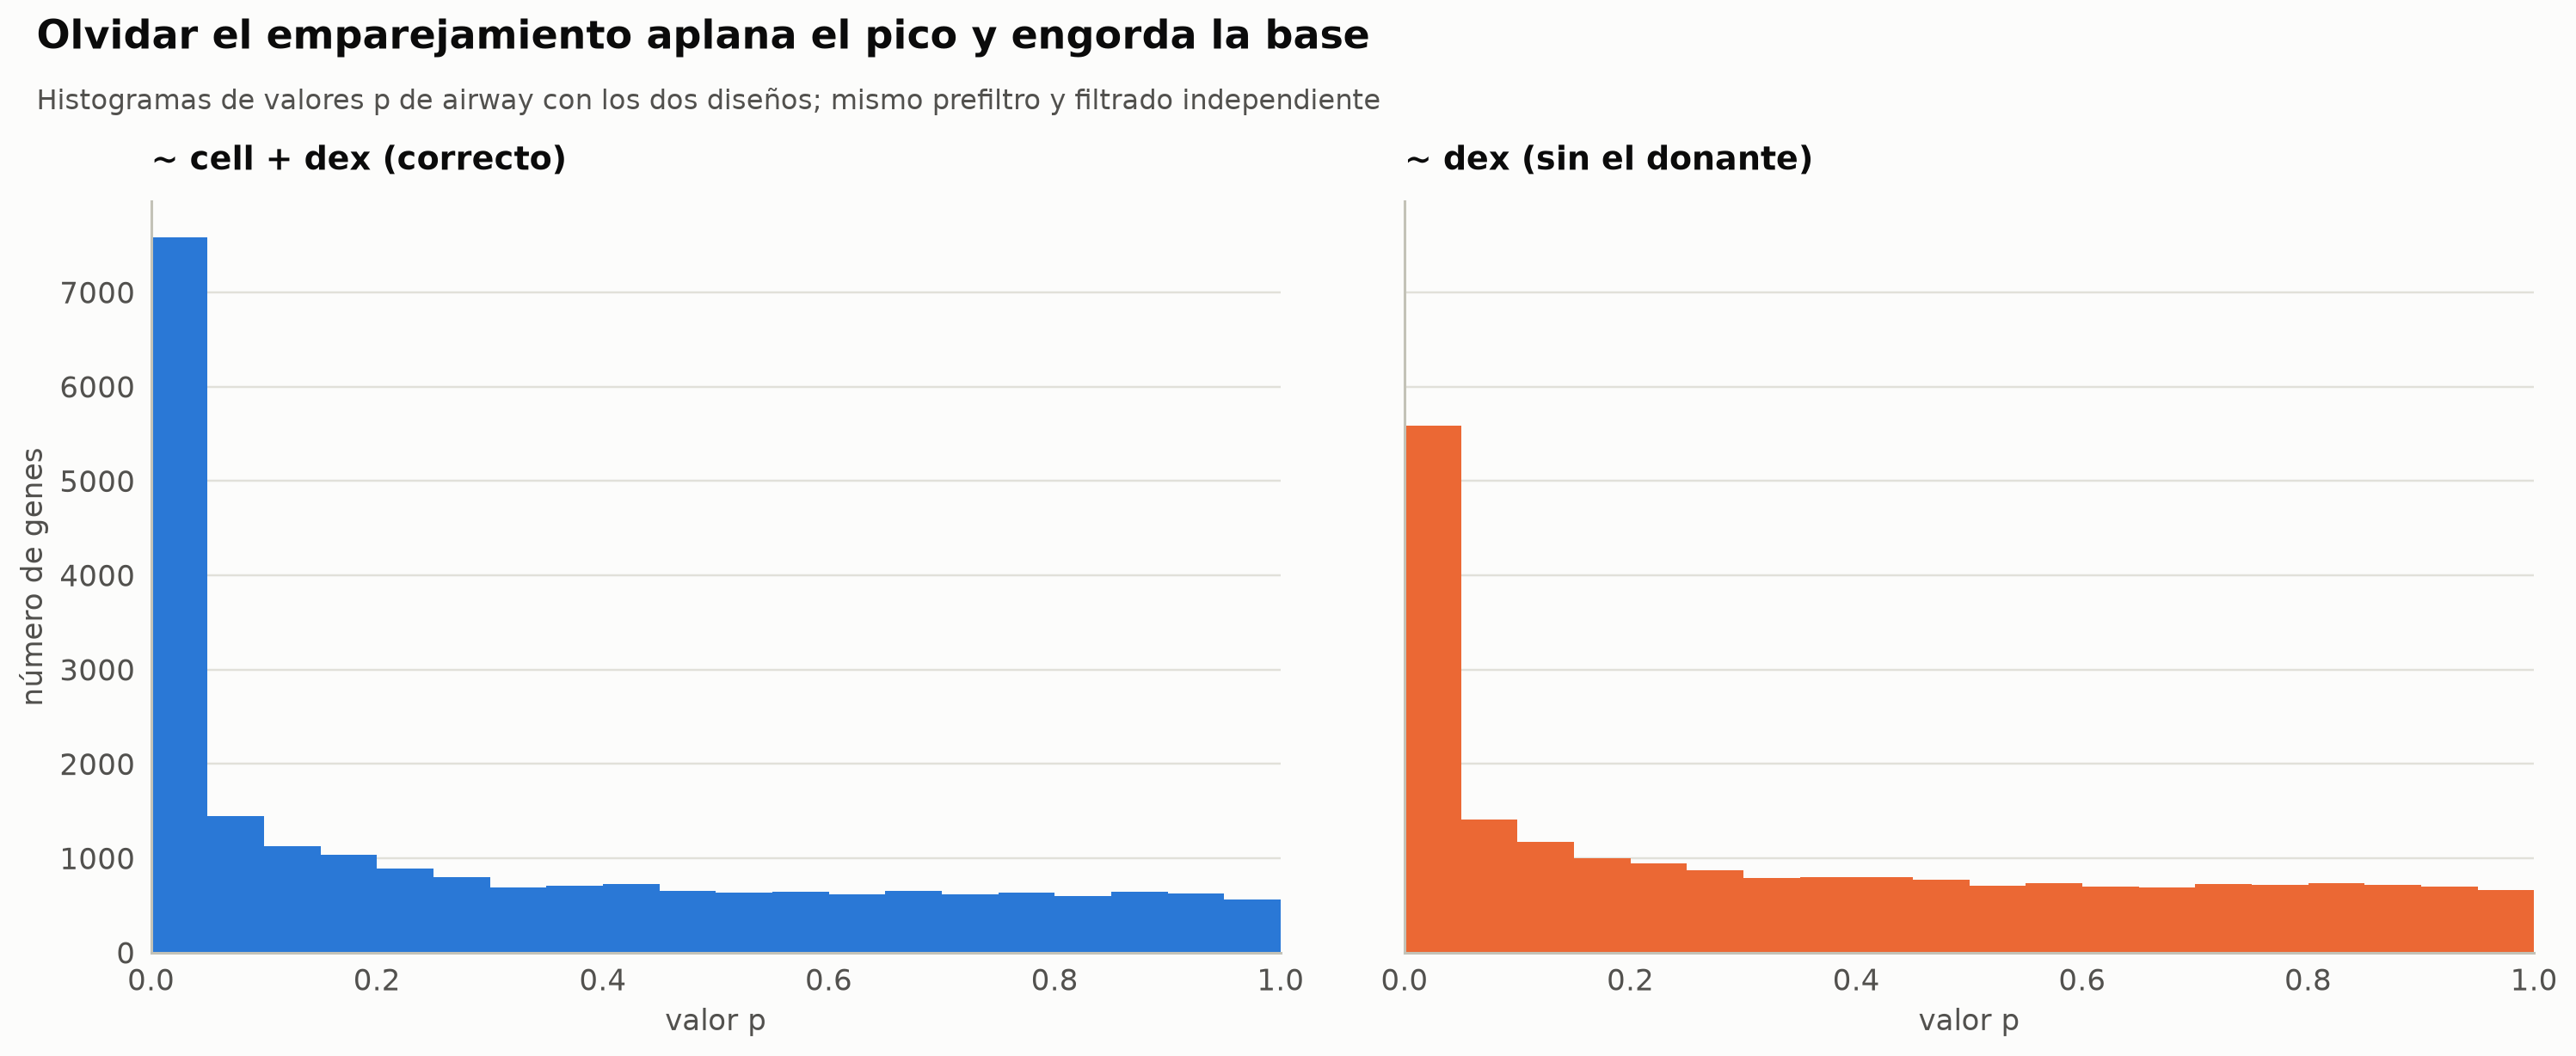

In [32]:
t = time.time()
fit_d = de_analysis(Ya, Xa[:, [0, -1]], sf_a)                  # diseño ~ dex: se re-estiman las dispersiones
pad_d = np.full(len(Ya), np.nan)
nrej_d = [int(np.sum(bh(fit_d["pvalue"][base_a >= np.quantile(base_a, q)]) < 0.1)) for q in qs_a]
thr_d = np.quantile(base_a, qs_a[int(np.argmax(nrej_d))]); pas_d = base_a >= thr_d
pad_d[pas_d] = bh(fit_d["pvalue"][pas_d])
n_d = int(np.sum(pad_d < 0.1))
print(f"~ dex: {n_d} genes con padj < 0,1  frente a  ~ cell + dex: {int(sig_a.sum())}  "
      f"({1 - n_d / sig_a.sum():.0%} menos) · {time.time() - t:.1f} s")
print(f"mediana de la dispersión (media > 10): ~ dex {np.median(fit_d['a_fin'][base_a > 10]):.4f} · "
      f"~ cell + dex {np.median(fit_a['a_fin'][base_a > 10]):.4f}")
print(f"π̂0(0,5): ~ dex {np.mean(fit_d['pvalue'][pas_d] > 0.5) / 0.5:.3f} · ~ cell + dex {pi0_a:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=True, gridspec_kw={"wspace": 0.06})
for ax, pv, lab, col in [(axes[0], res_a.pvalue[passed], "~ cell + dex (correcto)", ec.BLUE),
                         (axes[1], fit_d["pvalue"][pas_d], "~ dex (sin el donante)", ec.ORANGE)]:
    ax.hist(pv, bins=np.linspace(0, 1, 21), color=col, edgecolor="white")
    ax.set_xlim(0, 1); ax.set_xlabel("valor p")
    ax.set_title(lab, loc="left", fontsize=12.5)
axes[0].set_ylabel("número de genes")
ec.fig_title(fig, "Olvidar el emparejamiento aplana el pico y engorda la base",
             "Histogramas de valores p de airway con los dos diseños; mismo prefiltro y filtrado independiente")
plt.show()

> 🔎 **Qué observamos.** Sin el término `cell`, las dispersiones se duplican (las diferencias entre donantes se tratan
> como variabilidad biológica), el pico junto a cero se reduce y la base crece: perdemos una parte grande de los
> descubrimientos. No hemos «corregido» nada al incluir el donante; simplemente dejamos de confundir la diferencia entre
> personas con el ruido de la medición. En otros diseños (lotes de secuenciación, fecha de extracción) el error puede ir
> en la dirección contraria y crear señales espurias si el lote está correlacionado con la condición.

### Error 2 · Confundir significación con relevancia

Con muchas réplicas, un cambio del 5 % puede ser muy significativo. Si sólo interesan cambios grandes, lo correcto es
**contrastar** $H_0:|\beta|\le\log_2 1{,}5$ en lugar de filtrar los resultados por LFC *a posteriori*, lo cual no
controla la FDR. Con la aproximación normal de Wald, el valor $p$ de esta hipótesis compuesta (la opción
`lfcThreshold` de DESeq2 con la alternativa «greaterAbs») es

$$
p_i^{\,\tau}=\min\!\left\{1,\ 2\,\Phi\!\left(-\frac{|\hat\beta_i|-\tau}{\widehat{\mathrm{SE}}_i}\right)\right\},\qquad \tau=\log_2 1{,}5 .
$$

| Símbolo | Significado |
|---|---|
| $\tau$ | Umbral de relevancia biológica, en $\log_2$ ($\log_2 1{,}5\approx0{,}585$) |
| $p_i^{\,\tau}$ | Valor $p$ de la hipótesis «el cambio no supera 1,5 veces» |

In [33]:
tau = np.log2(1.5)
p_tau = np.minimum(1, 2 * stats.norm.sf((np.abs(res_a.log2FC) - tau) / res_a.lfcSE))
padj_tau = np.full(len(res_a), np.nan); padj_tau[passed] = bh(p_tau[passed])
n_tau = int(np.sum(padj_tau < 0.1))
n_post = int(np.sum(sig_a & (np.abs(res_a.log2FC) > tau)))
print(f"filtro a posteriori (padj < 0,1 y |LFC| > log2 1,5): {n_post} genes — la FDR de esta lista NO está controlada")
print(f"contraste H0: |β| ≤ log2 1,5 con BH: {n_tau} genes — la FDR sí está controlada")

filtro a posteriori (padj < 0,1 y |LFC| > log2 1,5): 2960 genes — la FDR de esta lista NO está controlada
contraste H0: |β| ≤ log2 1,5 con BH: 877 genes — la FDR sí está controlada


> 🔎 **Qué observamos.** El contraste con umbral es más exigente que el filtro *a posteriori*: un gen con
> $\hat\beta=0{,}7$ y SE grande supera el filtro (su LFC observado es mayor que 0,585) pero no demuestra que su cambio
> **verdadero** lo sea. La lista más corta es la honesta.

### Error 1 · Comparar listas

Que un gen sea significativo con el tratamiento A y no con el B **no demuestra** que respondan distinto: la ausencia de
evidencia no es evidencia de ausencia. Hay que contrastar la diferencia de LFC directamente, con un término de
interacción en el modelo (por ejemplo, `~ cell + tratamiento` con varios niveles y un contraste A − B, o
`~ genotipo + tratamiento + genotipo:tratamiento`). El Ejercicio 5 lo hace con la simulación.

## 11. ✍️ Ejercicios

**Ejercicio 1 (BH a mano, con un escalón hacia atrás).** Diez genes dan
$p=0{,}001;\ 0{,}012;\ 0{,}013;\ 0{,}040;\ 0{,}20;\ 0{,}30;\ 0{,}50;\ 0{,}60;\ 0{,}80;\ 0{,}90$. Con $\alpha=0{,}05$:
(a) construya la tabla $p_{(i)}$ frente a $i\alpha/m$; (b) halle $k^*$; (c) ¿hay algún gen rechazado cuyo $p_{(i)}$
quede **por encima** de su umbral? (d) Calcule sus `padj`.

In [34]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
pe = np.array([0.001, 0.012, 0.013, 0.040, 0.20, 0.30, 0.50, 0.60, 0.80, 0.90]); me = len(pe)
te = pd.DataFrame({"i": np.arange(1, me + 1), "p_(i)": pe, "iα/m": 0.05 * np.arange(1, me + 1) / me})
te["¿p ≤ iα/m?"] = np.where(te["p_(i)"] <= te["iα/m"], "sí", "no")
te["padj"] = bh(pe).round(4)
display(te.set_index("i").T)
k_e = int(np.max(np.where(pe <= 0.05 * np.arange(1, me + 1) / me)[0]) + 1)
print(f"k* = {k_e}: se rechazan los genes 1–{k_e}. El gen 2 (p = 0,012 > 0,010) queda por encima de su umbral, "
      "pero se rechaza igual porque el gen 3 está por debajo del suyo: eso es el 'step-up'.")

i,1,2,3,4,5,6,7,8,9,10
p_(i),0.001,0.012,0.013,0.04,0.2,0.3,0.5,0.6,0.8,0.9
iα/m,0.005,0.01,0.015,0.02,0.025,0.03,0.035,0.04,0.045,0.05
¿p ≤ iα/m?,sí,no,sí,no,no,no,no,no,no,no
padj,0.01,0.0433,0.0433,0.1,0.4,0.5,0.7143,0.75,0.8889,0.9


k* = 3: se rechazan los genes 1–3. El gen 2 (p = 0,012 > 0,010) queda por encima de su umbral, pero se rechaza igual porque el gen 3 está por debajo del suyo: eso es el 'step-up'.


**Ejercicio 2 (Bonferroni en datos reales).** Con los valores $p$ de *airway* (genes que pasaron el filtro), ¿cuántos
genes declara significativos Bonferroni con FWER $0{,}05$? ¿Y BH con FDR $0{,}05$? ¿Están las siete dianas conocidas en
la lista de Bonferroni?

In [35]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
pv_f = res_a.pvalue[passed].to_numpy(); m_f = len(pv_f)
bonf_set = set(res_a.symbol[passed][pv_f < 0.05 / m_f])
print(f"m = {m_f}; umbral de Bonferroni = {0.05 / m_f:.2e}")
print(f"Bonferroni (FWER 0,05): {len(bonf_set)} genes · BH (FDR 0,05): {np.sum(bh(pv_f) < 0.05)} genes")
print("dianas en la lista de Bonferroni:", {g_: (g_ in bonf_set) for g_ in targets})

m = 21915; umbral de Bonferroni = 2.28e-06
Bonferroni (FWER 0,05): 2007 genes · BH (FDR 0,05): 5684 genes
dianas en la lista de Bonferroni: {'FKBP5': True, 'TSC22D3': True, 'PER1': True, 'ZBTB16': True, 'DUSP1': True, 'KLF15': True, 'CRISPLD2': True}


**Ejercicio 3 ($q$-valores de Storey en datos reales).** Calcule $\hat\pi_0(\lambda)$ para
$\lambda=0{,}3;\ 0{,}5;\ 0{,}7$ con los genes de *airway* que pasaron el filtro, y el número de genes con $q<0{,}1$ usando
$\hat\pi_0(0{,}5)$. ¿Por qué aquí los $q$-valores sí ganan potencia frente a BH, a diferencia de la simulación?

In [36]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
for lam_ in (0.3, 0.5, 0.7):
    print(f"λ = {lam_}: π̂0 = {np.mean(pv_f > lam_) / (1 - lam_):.3f}")
pi0_e = np.mean(pv_f > 0.5) / 0.5
q_e = np.minimum(1, pi0_e * bh(pv_f))
print(f"q < 0,1: {np.sum(q_e < 0.1)} genes  frente a BH: {np.sum(bh(pv_f) < 0.1)}")
print(f"Con π̂0 ≈ {pi0_e:.2f}, BH (que supone π0 = 1) multiplica los p por un factor {1 / pi0_e:.2f} veces mayor de lo necesario;")
print("en la simulación π̂0 ≈ 0,99 y ambos métodos coinciden.")

λ = 0.3: π̂0 = 0.588
λ = 0.5: π̂0 = 0.569
λ = 0.7: π̂0 = 0.562
q < 0,1: 8057 genes  frente a BH: 6791
Con π̂0 ≈ 0.57, BH (que supone π0 = 1) multiplica los p por un factor 1.76 veces mayor de lo necesario;
en la simulación π̂0 ≈ 0,99 y ambos métodos coinciden.


**Ejercicio 4 (ordenar por LFC).** En el experimento simulado, tome los 50 genes con mayor $|\mathrm{LFC}|$ de máxima
verosimilitud y los 50 con mayor $|\mathrm{LFC}|$ contraído. ¿Cuántos de cada lista tienen un cambio real? ¿Cuál es su
media normalizada mediana?

In [37]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
for lab, v in [("máxima verosimilitud", lfc_hat), ("contraído", lfc_shr)]:
    top = np.argsort(-np.abs(v))[:50]
    print(f"top 50 por |LFC| {lab:22s}: cambios reales = {de[top].sum():2d}/50 · media normalizada mediana = "
          f"{np.median(base[top]):.1f}")

top 50 por |LFC| máxima verosimilitud  : cambios reales =  2/50 · media normalizada mediana = 0.4
top 50 por |LFC| contraído             : cambios reales = 50/50 · media normalizada mediana = 196.6


**Ejercicio 5 (comparar listas frente a contrastar la interacción).** Simule 1 000 genes con el **mismo** LFC verdadero,
$\beta=1$, en dos tratamientos A y B, cada uno estimado con $\mathrm{SE}=0{,}4$ independiente. (a) ¿Cuántos genes son
significativos ($p<0{,}05$) en A pero no en B? (b) Contraste directamente $H_0:\beta_A=\beta_B$ con
$z=(\hat\beta_A-\hat\beta_B)/\sqrt{2}\,\mathrm{SE}$. ¿Cuántos genes «responden distinto»?

In [38]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
r5 = np.random.default_rng(55)
bA = 1 + 0.4 * r5.standard_normal(1000); bB = 1 + 0.4 * r5.standard_normal(1000)
sA = 2 * stats.norm.sf(np.abs(bA / 0.4)) < 0.05; sB = 2 * stats.norm.sf(np.abs(bB / 0.4)) < 0.05
p_int = 2 * stats.norm.sf(np.abs((bA - bB) / (np.sqrt(2) * 0.4)))
print(f"(a) significativos en A y no en B: {np.sum(sA & ~sB)} (¡y en B y no en A: {np.sum(sB & ~sA)}!)")
print(f"(b) interacción significativa (p < 0,05): {np.sum(p_int < 0.05)} ≈ 5 % esperado por azar; con BH: {np.sum(bh(p_int) < 0.1)}")

(a) significativos en A y no en B: 221 (¡y en B y no en A: 196!)
(b) interacción significativa (p < 0,05): 56 ≈ 5 % esperado por azar; con BH: 0


## 📌 Resumen

* La pregunta «¿cambia este gen?» es $H_0:\beta_{i,\mathrm{cond}}=0$ en el GLM binomial negativo. La **prueba de Wald**
  divide $\hat\beta$ por su error estándar, que sale de $(X^\top WX)^{-1}$; la **LRT** compara modelos completo y
  reducido y es la herramienta para contrastar varios coeficientes a la vez (tiempos, lotes, donantes). Para un solo
  coeficiente coinciden (correlación $0{,}990$ en la simulación del libro).
* El LFC de máxima verosimilitud es muy ruidoso en genes claros. La **contracción** con una previa normal,
  $\tilde\beta_i\approx\hat\beta_i\,\sigma_p^2/(\sigma_p^2+\widehat{\mathrm{SE}}_i^2)$, cierra el embudo del gráfico MA
  («Un gen ruidoso»: $4{,}20\to0{,}51$; ECM $1{,}24\to0{,}117$). Una previa de **colas pesadas** (*apeglm*) conserva
  además los efectos grandes bien medidos (*ZBTB16* en *airway*). Los valores $p$ siguen saliendo del LFC sin contraer.
* Con miles de pruebas, $p<0{,}05$ produce cientos de falsos positivos; Bonferroni controla la FWER y pierde potencia;
  **Benjamini-Hochberg** controla la FDR, $\mathbb E[V/\max(R,1)]$, con un umbral que crece con el rango («Tres
  criterios»: 915/373, 185/2 y 404/33).
* El **histograma de valores $p$** es el primer diagnóstico: pico + base plana es sano; forma de U o base creciente
  delatan un modelo mal especificado. $\hat\pi_0$ de Storey tiende a sobreestimar $\pi_0$, y los $q$-valores son
  $\hat\pi_0\cdot p_{\mathrm{adj}}$.
* El **filtrado independiente** por media normalizada gana descubrimientos sin romper la FDR (404 → 418); filtrar por
  $p$ o por LFC antes de BH sí la rompe.
* En *airway*, un GLM `~ cell + dex` programado desde cero encuentra miles de genes regulados por la dexametasona, con las
  dianas clásicas (*FKBP5*, *TSC22D3*, *PER1*, *ZBTB16*, *DUSP1*, *KLF15*, *CRISPLD2*) entre los más significativos;
  coincide con `pydeseq2` (la referencia) en LFC y en el orden de los genes, y difiere en el borde de la significación
  sólo por la estimación de dispersiones, en un régimen de 3 grados de libertad que el propio DESeq2 señala como frágil. Olvidar el emparejamiento por donante duplica la dispersión y cuesta muchos genes.
* Tres errores clásicos: comparar listas en vez de contrastar la interacción; filtrar por LFC en vez de contrastar
  $|\beta|\le\tau$; y omitir del diseño los lotes, parejas o sexos.

## 📚 Lecturas y referencias

* Anders, S. y Huber, W. (2010). Differential expression analysis for sequence count data. *Genome Biology*, 11(10),
  R106. https://doi.org/10.1186/gb-2010-11-10-r106
* Benjamini, Y. y Hochberg, Y. (1995). Controlling the false discovery rate: a practical and powerful approach to
  multiple testing. *Journal of the Royal Statistical Society B*, 57(1), 289–300.
  https://doi.org/10.1111/j.2517-6161.1995.tb02031.x
* Bourgon, R., Gentleman, R. y Huber, W. (2010). Independent filtering increases detection power for high-throughput
  experiments. *PNAS*, 107(21), 9546–9551. https://doi.org/10.1073/pnas.0914005107
* Conesa, A. *et al.* (2016). A survey of best practices for RNA-seq data analysis. *Genome Biology*, 17, 13.
  https://doi.org/10.1186/s13059-016-0881-8
* Himes, B. E. *et al.* (2014). RNA-Seq transcriptome profiling identifies CRISPLD2 as a glucocorticoid responsive gene
  that modulates cytokine function in airway smooth muscle cells. *PLoS ONE*, 9(6), e99625.
  https://doi.org/10.1371/journal.pone.0099625
* Holmes, S. y Huber, W. (2019). *Modern Statistics for Modern Biology*. Cambridge University Press.
* Love, M. I., Huber, W. y Anders, S. (2014). Moderated estimation of fold change and dispersion for RNA-seq data with
  DESeq2. *Genome Biology*, 15(12), 550. https://doi.org/10.1186/s13059-014-0550-8
* Muzellec, B., Teleńczuk, M., Cabeli, V. y Andreux, M. (2023). PyDESeq2: a Python package for bulk RNA-seq
  differential expression analysis. *Bioinformatics*, 39(9), btad547. https://doi.org/10.1093/bioinformatics/btad547
* Storey, J. D. y Tibshirani, R. (2003). Statistical significance for genomewide studies. *PNAS*, 100(16), 9440–9445.
  https://doi.org/10.1073/pnas.1530509100
* Wilks, C. *et al.* (2021). recount3: summaries and queries for large-scale RNA-seq expression and splicing. *Genome
  Biology*, 22, 323. https://doi.org/10.1186/s13059-021-02533-6
* Zhu, A., Ibrahim, J. G. y Love, M. I. (2019). Heavy-tailed prior distributions for sequence count data: removing the
  noise and preserving large differences. *Bioinformatics*, 35(12), 2084–2092. https://doi.org/10.1093/bioinformatics/bty895

**Datos:** experimento *airway* (GEO GSE52778, SRA SRP033351), conteos por gen de recount3 (GENCODE v26) en
`data/airway_SRP033351_counts.tsv.gz`; estado del generador del libro en `data/113_rng_libro.json`; resultados en
`data/113_airway_dex_results.tsv.gz`.

In [39]:
print(f"⏱️ Tiempo total de ejecución del notebook: {time.time() - T0:.0f} s")

⏱️ Tiempo total de ejecución del notebook: 57 s


---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)